
## 0. Import & Load dữ liệu

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import pandas as pd
import unicodedata
from collections import Counter
import matplotlib.cm as cm
import warnings
from itertools import combinations
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
          '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac','#8cd17d']
SOURCE_COLORS = {'Tuổi Trẻ': '#4e79a7', 'Thanh Niên': '#f28e2b', 'VietnamNet': '#e15759'}

In [15]:
RAW_DIR = "/kaggle/input/datasets/vlus06/data-ds108/rawdata"

df_tt  = pd.read_csv(f"{RAW_DIR}/merged_data_tuoitre.csv")
df_tn  = pd.read_csv(f"{RAW_DIR}/merged_data_thanhnien.csv")
df_vnn = pd.read_csv(f"{RAW_DIR}/merged_data_vietnamnet.csv")

df_tt['source']  = 'Tuổi Trẻ'
df_tn['source']  = 'Thanh Niên'
df_vnn['source'] = 'VietnamNet'

In [16]:
df_tt["public_date"].head()

0    2025-12-30T19:31:59+07:00
1    2025-12-30T18:43:19+07:00
2    2025-12-26T19:23:09+07:00
3    2025-12-26T19:13:49+07:00
4    2025-12-26T19:09:21+07:00
Name: public_date, dtype: object

In [17]:
df_tn["public_date"].head()

0    2025-06-06T10:05:00+07:00
1    2025-05-10T11:36:00+07:00
2    2025-09-27T08:43:00+07:00
3    2023-08-07T15:02:00+07:00
4    2024-11-13T15:17:00+07:00
Name: public_date, dtype: object

In [18]:
df_vnn["public_date"].head()

0    2025-12-31T05:45:00.000 +07:00
1    2025-12-30T14:30:00.000 +07:00
2    2025-12-30T09:55:00.000 +07:00
3    2025-12-30T08:00:00.000 +07:00
4    2025-12-30T06:00:00.000 +07:00
Name: public_date, dtype: object

In [19]:
for _df in [df_tt, df_tn, df_vnn]:
    _df['public_date'] = pd.to_datetime(_df['public_date'], errors='coerce')

df = pd.concat([df_tt, df_tn, df_vnn], ignore_index=True)

In [20]:
print(df_tt["public_date"].dtype)
print(df_tn["public_date"].dtype)
print(df_vnn["public_date"].dtype)

datetime64[ns, UTC+07:00]
datetime64[ns, UTC+07:00]
datetime64[ns, UTC+07:00]


In [21]:
# Chuẩn hoá category label
CATEGORY_MAP = {
    'kinh doanh': 'Kinh doanh', 'cong nghe': 'Khoa học công nghệ',
    'the gioi': 'Thế giới',     'giai tri': 'Giải trí',
    'thoi su': 'Thời sự',       'giao duc': 'Giáo dục',
    'doi song': 'Đời sống',     'du lich': 'Du lịch',
    'xe': 'Xe',                 'suc khoe': 'Sức khỏe',
    'the thao': 'Thể thao'
}
df['category'] = df['category'].replace(CATEGORY_MAP)

df["year"]  = df["public_date"].dt.year.astype("Int64")
df["month"] = df["public_date"].dt.month.astype("Int64")

In [22]:
df["category"].unique()

array(['Bất động sản', 'Du lịch', 'Giáo dục', 'Giải trí',
       'Khoa học công nghệ', 'Kinh doanh', 'Pháp luật', 'Sức khỏe',
       'Thế giới', 'Thể thao', 'Thời sự', 'Xe', 'Đời sống'], dtype=object)

In [23]:
print(f'Load xong — {len(df):,} bài | {df.shape[1]} cột')
print(f'   Tuổi Trẻ  : {len(df_tt):,}')
print(f'   Thanh Niên: {len(df_tn):,}')
print(f'   VietnamNet: {len(df_vnn):,}')

Load xong — 273,058 bài | 12 cột
   Tuổi Trẻ  : 53,010
   Thanh Niên: 96,017
   VietnamNet: 124,031


# EDA

> Mục tiêu: hiểu cấu trúc dữ liệu thô, đánh giá tính đại diện của dataset, phát hiện các vấn đề cần xử lý trước khi làm sạch và chuẩn bị dữ liệu cho bài toán phân loại chủ đề tin tức tiếng Việt.

## 1. Tổng quan cấu trúc dữ liệu

In [24]:
# --- Tính số lượng author theo từng nguồn rồi cộng lại ---
if 'author' in df.columns:
    so_luong_author = (
        df.dropna(subset=['author'])
          .groupby('source')['author']
          .nunique()
          .sum()
    )
else:
    so_luong_author = 'N/A'


# --- Bảng tổng quan ---
tong_quan = pd.DataFrame({
    'Thuộc tính': [
        'Tổng số bài báo',
        'Số cột',
        'Số nguồn báo',
        'Số tác giả',
        'Số chủ đề lớn (category)',
        'Số chủ đề con (sub_topic)',
        'Khoảng thời gian'
    ],
    'Giá trị': [
        f"{len(df):,}",
        df.shape[1],
        df['source'].nunique(),
        f"{so_luong_author:,}" if isinstance(so_luong_author, (int, float)) else so_luong_author,
        df['category'].nunique(),
        df['sub_topic'].nunique() if 'sub_topic' in df.columns else 'N/A',
        f"{df['public_date'].min().strftime('%d/%m/%Y')} – {df['public_date'].max().strftime('%d/%m/%Y')}"
        if df['public_date'].notna().any() else 'N/A'
    ]
})

print('=== TỔNG QUAN DATASET ===')
display(tong_quan.style.hide(axis='index'))


# --- Kiểu dữ liệu ---
print('\n=== KIỂU DỮ LIỆU ===')
display(df.dtypes.reset_index().rename(columns={'index': 'Cột', 0: 'Dtype'}))


# --- 5 dòng mẫu ---
print('\n=== 5 DÒNG MẪU (RANDOM) ===')
display(df.sample(5, random_state=42).reset_index(drop=True))

=== TỔNG QUAN DATASET ===


Thuộc tính,Giá trị
Tổng số bài báo,"273,058"
Số cột,12
Số nguồn báo,3
Số tác giả,5837
Số chủ đề lớn (category),13
Số chủ đề con (sub_topic),153
Khoảng thời gian,01/01/2023 – 31/12/2025



=== KIỂU DỮ LIỆU ===


,Cột,Dtype
0,category,object
1,sub_topic,object
2,title,object
3,description,object
4,content,object
5,public_date,"datetime64[ns, UTC+07:00]"
6,author,object
7,source,object
8,url,object
9,tag,object



=== 5 DÒNG MẪU (RANDOM) ===


,category,sub_topic,title,description,content,public_date,author,source,url,tag,year,month
0,Kinh doanh,tai chinh,"Đề nghị ngân hàng nộp thuế thay cho Agoda, Air...","Do Agoda, AirBnB, Booking và Paypal chưa đăng ...",Danh sách 4 'ông lớn' hoạt động hơn chục năm n...,2025-01-08 18:50:31+07:00,LÊ THANH,Tuổi Trẻ,https://tuoitre.vn/de-nghi-ngan-hang-nop-thue-...,"nhà cung cấp nước ngoài,nộp thuế,cơ quan thuế,...",2025,1
1,Khoa học công nghệ,cau noi,"Quản lý tiền không cần ngân hàng, DeFi đang th...","Từ chỗ phụ thuộc vào ngân hàng và ví điện tử, ...",Người dùng quản lý tiền số qua dịch vụ tài chí...,2025-09-27 16:45:20+07:00,SONG TRÍ,Tuổi Trẻ,https://tuoitre.vn/quan-ly-tien-khong-can-ngan...,"usdt,staking,defi,blockchain,smart",2025,9
2,Sức khỏe,biet đe khoe,Mổ mắt miễn phí - Nỗ lực chung tay vì cộng đồng,Nhiều năm sống trong bóng tối vì bệnh mắt nặng...,Các bệnh nhân hoàn cảnh khó khăn được khám bện...,2025-12-24 18:25:52+07:00,V.T.K,Tuổi Trẻ,https://tuoitre.vn/mo-mat-mien-phi-no-luc-chun...,"bệnh nhân nghèo,đục thủy tinh thể,hồng sơn",2025,12
3,Xe,tin tuc,Phụ nữ bán ô tô làm gì khi có đề nghị khiếm nhã?,"Một nữ tư vấn bán ô tô chia sẻ, trong quá trìn...",Nữ tư vấn bán hàng lâu năm tiết lộ những câu c...,2024-10-19 07:38:04+07:00,MINH SƠN,Tuổi Trẻ,https://tuoitre.vn/phu-nu-ban-o-to-lam-gi-khi-...,"sales ô tô,nữ tư vấn bán hàng,góc nhìn chuyên ...",2024,10
4,Xe,sau tay lai,Tài xế say rượu phi xe vào cửa hàng tông trún...,Một người đàn ông được cho là say rượu đã lái ...,Xem video:\nĐoạn video ghi lại cảnh chiếcMitsu...,2023-03-24 15:26:04+07:00,Y Nhụy,VietnamNet,https://vietnamnet.vn/tai-xe-say-ruou-phi-xe-v...,"tài xế, tài xế say rượu, Mitsubishi Mirage",2023,3


### 1.1. Chuẩn hóa tạm thời dữ liệu dạng chuỗi phục vụ EDA

Trong quá trình EDA, cần đánh giá missing values, duplicate và độ dài văn bản một cách chính xác. Tuy nhiên, dữ liệu thu thập từ nhiều nguồn báo có thể chứa khoảng trắng thừa, nhiều khoảng trắng liên tiếp, ký tự xuống dòng, tab hoặc chuỗi chỉ chứa khoảng trắng.

Các vấn đề này có thể làm sai lệch kết quả thống kê. Ví dụ, một chuỗi chỉ chứa khoảng trắng không được tính là missing nếu chưa chuyển về giá trị thiếu; hoặc hai nội dung giống nhau có thể không được nhận diện là duplicate nếu khác nhau ở ký tự xuống dòng hoặc khoảng trắng.

Vì vậy, trong EDA, nhóm tạo một bản dữ liệu chuẩn hóa tạm thời để phục vụ thống kê. Bước này chưa phải là làm sạch dữ liệu chính thức, mà chỉ nhằm đảm bảo các phân tích missing values, duplicate và độ dài văn bản phản ánh chính xác hơn tình trạng dữ liệu.

In [25]:
df_eda = df.copy()

text_cols = ['title', 'description', 'content', 'author', 'tag', 'category', 'source', 'url']
text_cols = [col for col in text_cols if col in df_eda.columns]

for col in text_cols:
    df_eda[col] = (
        df_eda[col]
        .astype('string')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df_eda[col] = df_eda[col].replace('', pd.NA)

## 2. Phân tích phân phối category và source

### 2.1. Phân phối Category (Class Imbalance)

> **Lý do:** đây là phân tích nền tảng của bài toán classification. Mất cân bằng class ảnh hưởng trực tiếp đến cách chia tập dữ liệu, lựa chọn metric và diễn giải kết quả mô hình.

=== PHÂN PHỐI CATEGORY ===


Chủ đề,Số bài,Tỉ lệ (%)
Giải trí,43473,15.920000
Thể thao,36271,13.280000
Kinh doanh,33348,12.210000
Thời sự,27518,10.080000
Giáo dục,22494,8.240000
Khoa học công nghệ,21045,7.710000
Đời sống,19169,7.020000
Xe,18912,6.930000
Sức khỏe,16697,6.110000
Thế giới,14965,5.480000



Imbalance Ratio (max/min): 13.3x — Cần xem xét resampling


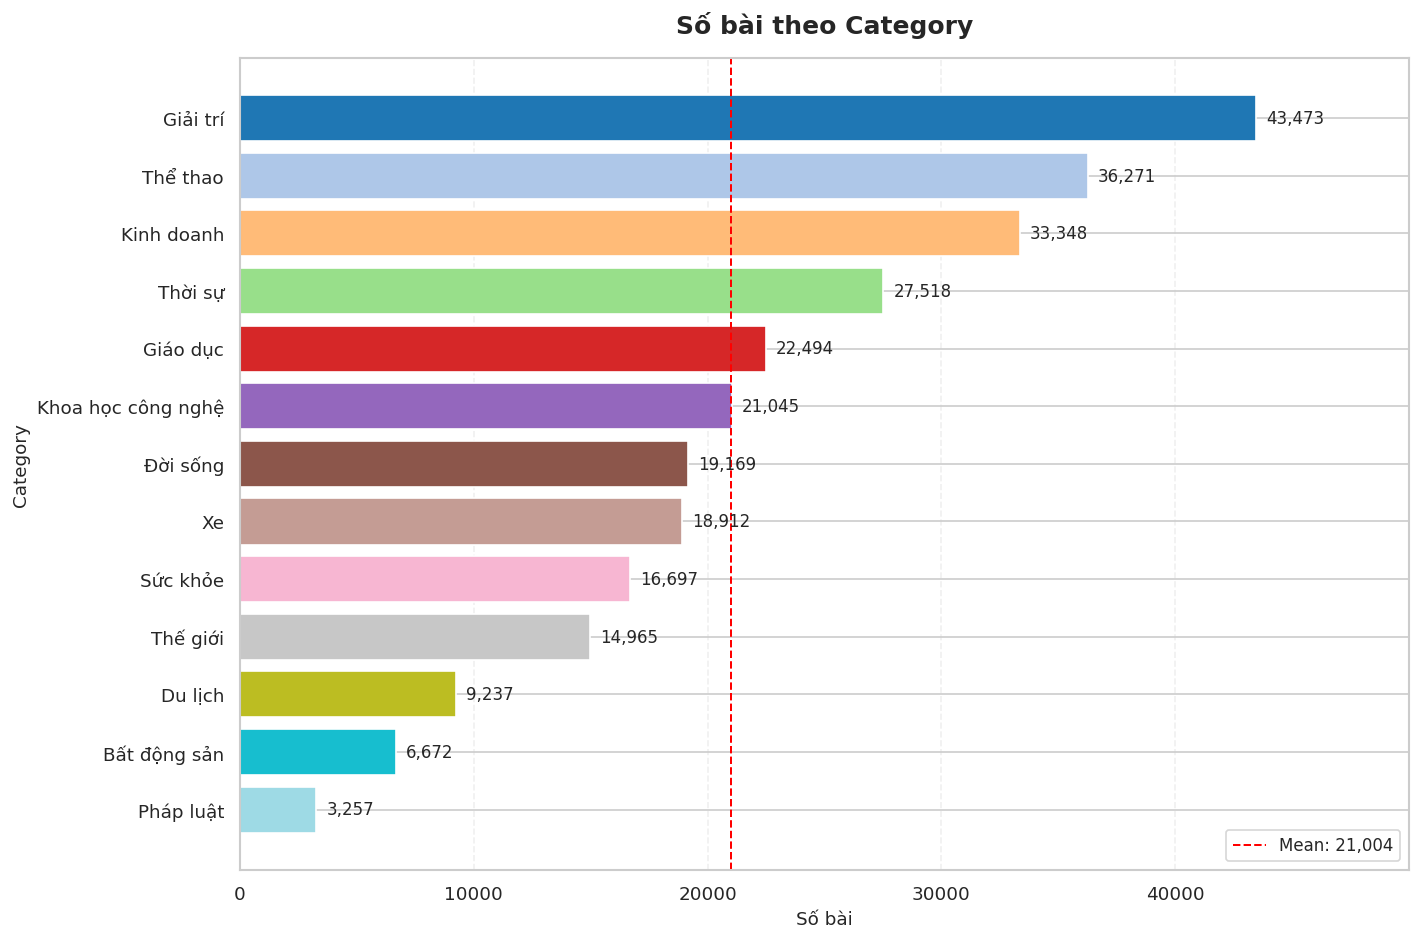

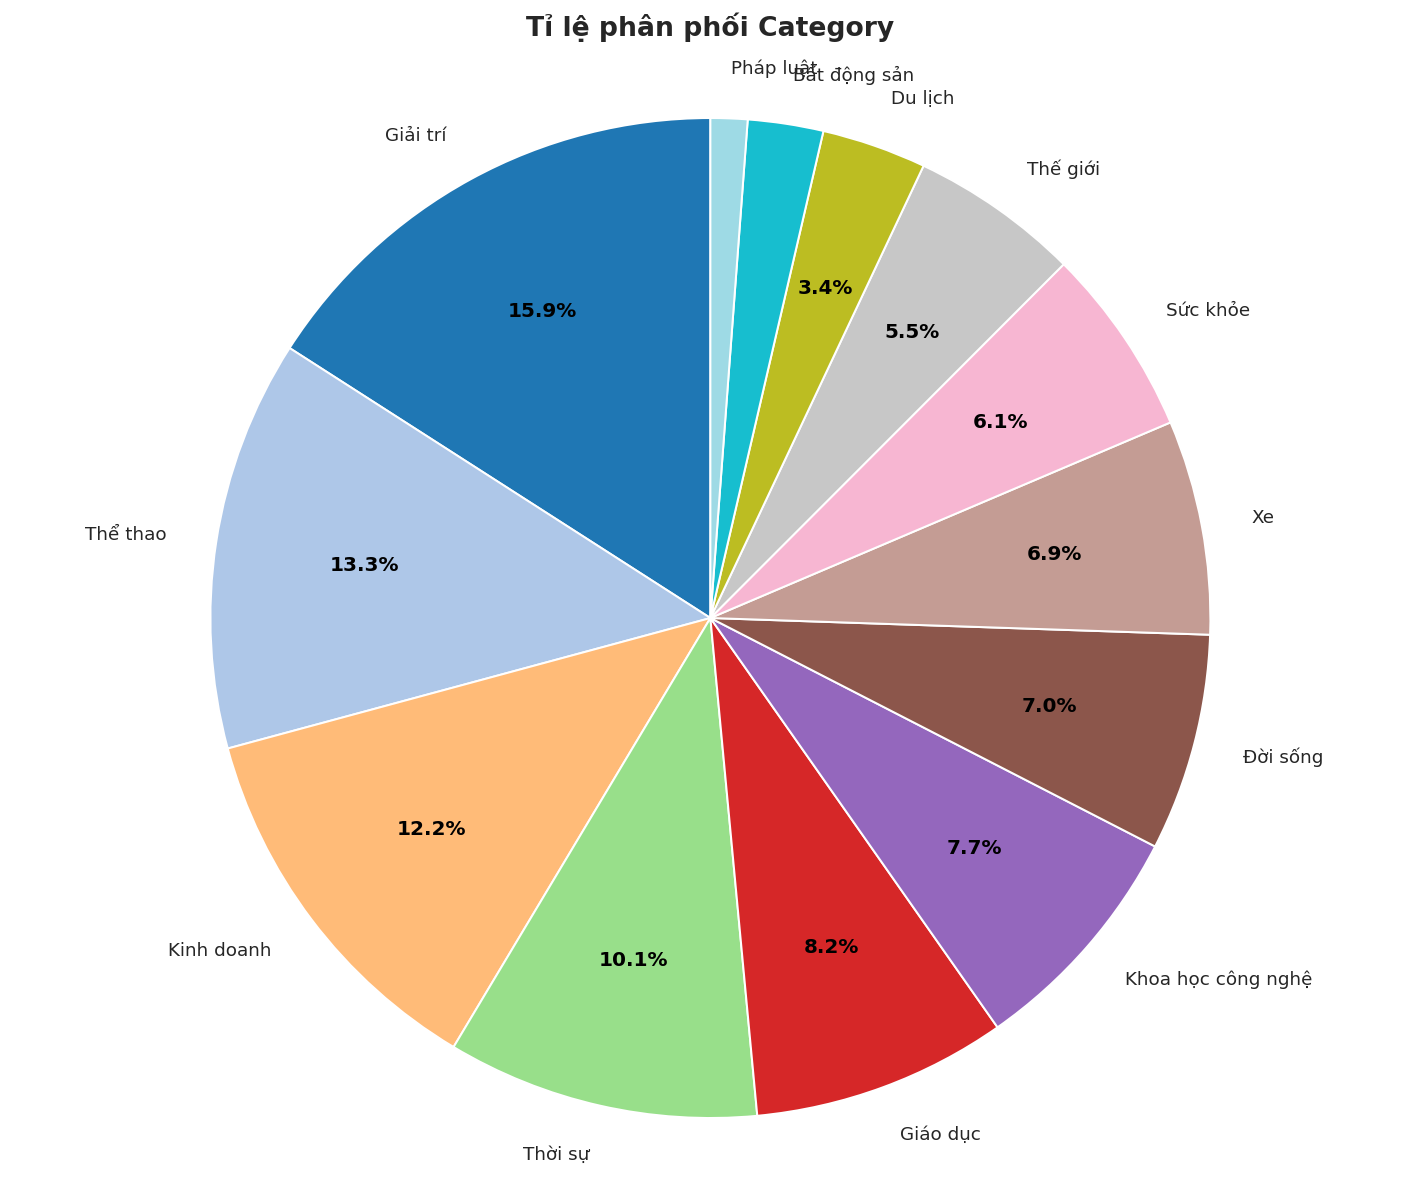

In [26]:
b4 = df_eda['category'].value_counts().reset_index()
b4.columns = ['Chủ đề', 'Số bài']
b4['Tỉ lệ (%)'] = (b4['Số bài'] / b4['Số bài'].sum() * 100).round(2)

imbalance_ratio = b4['Số bài'].max() / b4['Số bài'].min()

print('=== PHÂN PHỐI CATEGORY ===')
display(
    b4.style
    .hide(axis='index')
    .background_gradient(subset=['Số bài'], cmap='Blues')
)

print(
    f'\nImbalance Ratio (max/min): {imbalance_ratio:.1f}x'
    f' — {"Cần xem xét resampling" if imbalance_ratio > 5 else "Chấp nhận được"}'
)

# Tạo màu cố định cho từng category
categories = b4['Chủ đề'].tolist()
colors = cm.tab20(np.linspace(0, 1, len(categories)))
color_map = dict(zip(categories, colors))

# =========================
# BIỂU ĐỒ CỘT NGANG
# =========================
plot_df = b4.sort_values('Số bài', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bar_colors = plot_df['Chủ đề'].map(color_map)

bars = ax.barh(
    plot_df['Chủ đề'],
    plot_df['Số bài'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1
)

max_val = plot_df['Số bài'].max()

for bar, val in zip(bars, plot_df['Số bài']):
    ax.text(
        val + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=10
    )

mean_val = b4['Số bài'].mean()

ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label=f'Mean: {mean_val:,.0f}'
)

ax.set_xlabel('Số bài', fontsize=11)
ax.set_ylabel('Category', fontsize=11)
ax.set_title(
    'Số bài theo Category',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

# =========================
# BIỂU ĐỒ TRÒN
# =========================
fig, ax = plt.subplots(figsize=(12, 10))

pie_colors = b4['Chủ đề'].map(color_map)

wedges, texts, autotexts = ax.pie(
    b4['Tỉ lệ (%)'],
    labels=b4['Chủ đề'],
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 3 else '',
    startangle=90,
    colors=pie_colors,
    radius=1.1,   # phóng to hình tròn
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 11   # chữ label ngoài
    },
    pctdistance=0.7     # vị trí số % trong miếng bánh
)

# chỉnh số % to hơn
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)   # tăng size số %
    autotext.set_color('black')

ax.set_title(
    'Tỉ lệ phân phối Category',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

#### Nhận xét Phân phối Category (Class Distribution)

Dataset có **13 category** với tổng khoảng **273,058 bài báo**. Phân phối nhãn không đồng đều, thể hiện rõ đặc trưng tự nhiên của dữ liệu tin tức: một số chủ đề xuất hiện rất thường xuyên, trong khi một số chủ đề hẹp có số lượng bài ít hơn đáng kể.

**Imbalance ratio = 43,473 / 3,257 ≈ 13.3 lần**, cho thấy mức mất cân bằng đáng kể giữa category lớn nhất và nhỏ nhất.

Phân phối có thể chia thành ba nhóm:

- **Nhóm lớn**: `Giải trí`, `Thể thao`, `Kinh doanh`, `Thời sự`. Bốn nhóm này chiếm khoảng **51.49%** toàn bộ dataset, phản ánh đây là các mảng nội dung được đăng tải thường xuyên trên báo điện tử.
- **Nhóm trung bình**: `Giáo dục`, `Khoa học công nghệ`, `Đời sống`, `Xe`, `Sức khỏe`, `Thế giới`. Các nhóm này có số lượng ổn định hơn, đủ lớn để phục vụ huấn luyện và đánh giá.
- **Nhóm nhỏ**: `Du lịch`, `Bất động sản`, `Pháp luật`. Đặc biệt, `Pháp luật` chỉ có khoảng **3,257 bài**, nên khi đánh giá mô hình cần chú ý thêm các metric như Macro F1 thay vì chỉ nhìn Accuracy.

Kết quả này cho thấy dataset đủ lớn nhưng không cân bằng tuyệt đối. Đây là đặc điểm cần được ghi nhận khi chia train/dev/test và khi diễn giải hiệu năng của mô hình.

### 2.2. Phân phối Source

> **Lý do:** nếu một nguồn báo chiếm quá nhiều hoặc chi phối một số category cụ thể, mô hình có thể học một phần phong cách/nguồn báo thay vì chỉ học nội dung chủ đề.

=== PHÂN PHỐI SOURCE ===


Nguồn báo,Số bài,Tỉ lệ (%)
VietnamNet,124031,45.420000
Thanh Niên,96017,35.160000
Tuổi Trẻ,53010,19.410000


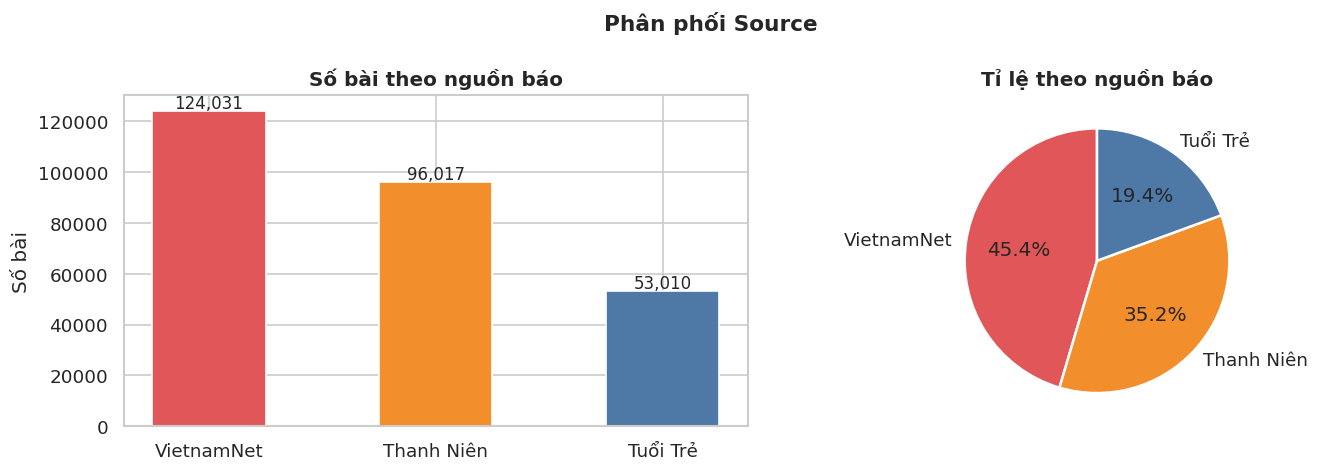

In [27]:
b5 = df_eda['source'].value_counts().reset_index()
b5.columns = ['Nguồn báo', 'Số bài']
b5['Tỉ lệ (%)'] = (b5['Số bài'] / b5['Số bài'].sum() * 100).round(2)

print('=== PHÂN PHỐI SOURCE ===')
display(b5.style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

src_colors = [SOURCE_COLORS.get(s, '#999') for s in b5['Nguồn báo']]
bars = axes[0].bar(b5['Nguồn báo'], b5['Số bài'], color=src_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, b5['Số bài']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + b5['Số bài'].max() * 0.01,
                 f'{val:,}', ha='center', fontsize=10)
axes[0].set_ylabel('Số bài')
axes[0].set_title('Số bài theo nguồn báo', fontweight='bold')

axes[1].pie(b5['Tỉ lệ (%)'], labels=b5['Nguồn báo'], autopct='%1.1f%%',
            colors=src_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Tỉ lệ theo nguồn báo', fontweight='bold')

plt.suptitle('Phân phối Source', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét Phân phối Source

Ba nguồn báo đóng góp không đồng đều vào dataset. VietnamNet chiếm tỷ lệ lớn nhất với khoảng **45.42%**, tiếp theo là Thanh Niên khoảng **35.2%**, và Tuổi Trẻ khoảng **19.4%**. Tỷ lệ giữa nguồn lớn nhất và nhỏ nhất khoảng **2.34 lần**.

Mức lệch này chưa phải là vấn đề nghiêm trọng nếu `source` không được đưa trực tiếp vào input của mô hình. Tuy nhiên, phân phối theo source vẫn cần được phân tích vì mỗi nguồn báo có thể có phong cách viết, cấu trúc chuyên mục và mức độ bao phủ category khác nhau. Nếu một category bị chi phối bởi một source cụ thể, mô hình có thể học các tín hiệu đặc trưng của nguồn báo thay vì học đặc trưng nội dung của category.

### 2.3. Phân phối Category × Source

> **Lý do:** kiểm tra một số category có bị chi phối hoặc thiếu hẳn một nguồn báo hay không. Đây là bước quan trọng để nhận diện source bias trong dữ liệu.

=== SỐ BÀI THEO CATEGORY × SOURCE ===


source,Thanh Niên,Tuổi Trẻ,VietnamNet
category,,,
Bất động sản,0,1264,5408
Du lịch,5584,1019,2634
Giáo dục,9311,4245,8938
Giải trí,14645,10306,18522
Khoa học công nghệ,12796,977,7272
Kinh doanh,10174,8328,14846
Pháp luật,0,1500,1757
Sức khỏe,3425,4534,8738
Thế giới,5627,4287,5051


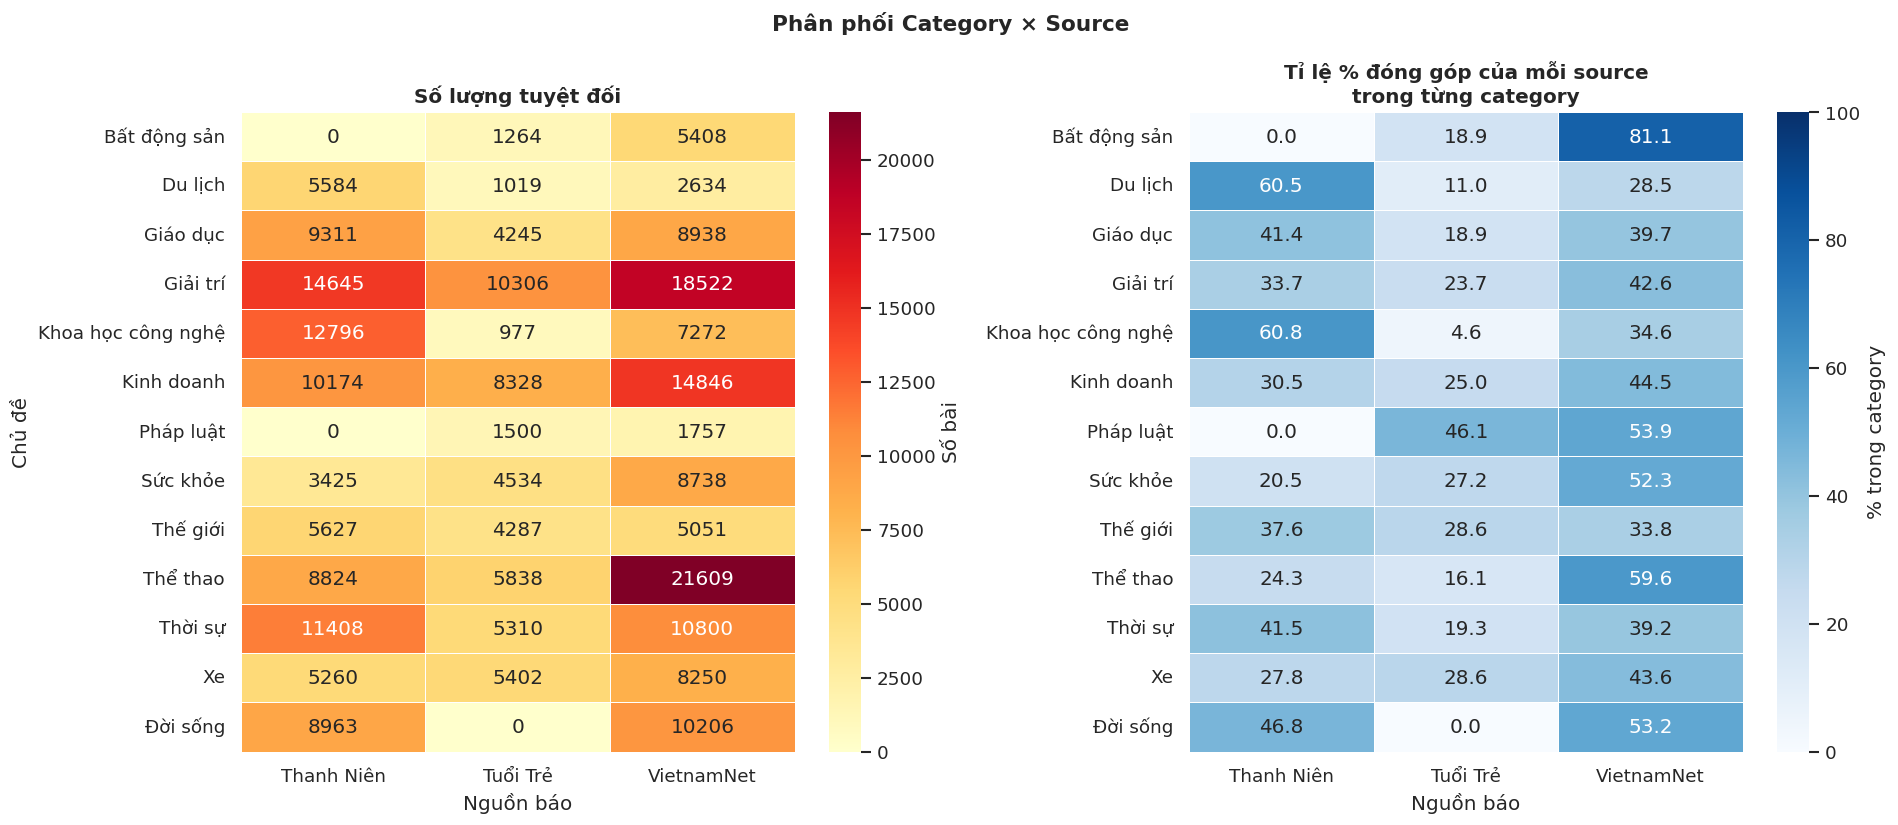

In [28]:
b6_count = df_eda.groupby(['category', 'source']).size().unstack(fill_value=0)

b6_pct = b6_count.div(b6_count.sum(axis=1), axis=0).mul(100).round(1)

print('=== SỐ BÀI THEO CATEGORY × SOURCE ===')
display(b6_count)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(b6_count, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Số bài'})
axes[0].set_title('Số lượng tuyệt đối', fontweight='bold')
axes[0].set_xlabel('Nguồn báo')
axes[0].set_ylabel('Chủ đề')

sns.heatmap(b6_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% trong category'},
            vmin=0, vmax=100)
axes[1].set_title('Tỉ lệ % đóng góp của mỗi source\ntrong từng category', fontweight='bold')
axes[1].set_xlabel('Nguồn báo')
axes[1].set_ylabel('')

plt.suptitle('Phân phối Category × Source', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét — Phân phối Category × Source

Phân phối giữa `category` và `source` cho thấy dữ liệu không được phân bố đồng đều giữa ba nguồn báo. Một số category có sự vắng mặt hoàn toàn của một nguồn cụ thể trong tập dữ liệu thu thập được.

Cụ thể, có 3 trường hợp một source không xuất hiện trong một category:

* **Bất động sản**: Thanh Niên không có bài trong tập dữ liệu thu thập được. Category này chỉ gồm bài từ Tuổi Trẻ, chiếm 18.9%, và VietnamNet, chiếm 81.1%.
* **Pháp luật**: Thanh Niên không có bài trong tập dữ liệu thu thập được. Category này chỉ gồm bài từ Tuổi Trẻ, chiếm 46.1%, và VietnamNet, chiếm 53.9%.
* **Đời sống**: Tuổi Trẻ không có bài trong tập dữ liệu thu thập được. Category này chỉ gồm bài từ Thanh Niên, chiếm 46.8%, và VietnamNet, chiếm 53.2%.

Sự vắng mặt này không nên được hiểu là các nguồn báo trên hoàn toàn không có nội dung thuộc những chủ đề tương ứng, mà chỉ phản ánh phạm vi dữ liệu đã crawl, cách ánh xạ chuyên mục, hoặc cấu trúc chuyên mục khác nhau giữa các trang báo.

Bên cạnh đó, một số category bị chi phối mạnh bởi một nguồn báo cụ thể, tức một source chiếm trên 55% tổng số bài trong category:

* **Thể thao**: VietnamNet chiếm 59.6%, với 21,609 bài.
* **Du lịch**: Thanh Niên chiếm 60.5%.
* **Khoa học công nghệ**: Thanh Niên chiếm 60.8%, trong khi Tuổi Trẻ chỉ chiếm 4.6%, tương ứng 977 bài. Đây là một trong những category có phân phối lệch rõ rệt nhất giữa các nguồn.

Ngược lại, một số category có phân phối tương đối cân bằng hơn giữa các source, không có nguồn nào vượt quá 50%. Các category này gồm **Giáo dục**, **Giải trí**, **Kinh doanh**, **Thế giới** và **Xe**. Với các category này, mô hình có nhiều khả năng học được đặc trưng nội dung của chủ đề thay vì phụ thuộc quá nhiều vào văn phong hoặc đặc điểm riêng của một nguồn báo.

Nhìn chung, kết quả cho thấy có dấu hiệu **source bias** trong dữ liệu, đặc biệt ở các category như **Bất động sản**, **Pháp luật**, **Đời sống**, **Thể thao**, **Du lịch** và **Khoa học công nghệ**. Tuy nhiên, đây không phải là vấn đề nên xử lý trực tiếp ở bước cleaning, vì việc cân bằng lại số lượng bài theo source trong từng category, chẳng hạn undersampling VietnamNet ở Thể thao hoặc Bất động sản, có thể làm mất một lượng lớn dữ liệu hợp lệ và phá vỡ phân phối tự nhiên của dataset.

Do đó, source bias nên được ghi nhận như một đặc tính quan trọng của dữ liệu. Trong các bước đánh giá mô hình sau này, nếu mô hình phân loại kém ở những category bị chi phối mạnh bởi một source, hoặc nếu mô hình có xu hướng học theo văn phong nguồn báo thay vì nội dung chủ đề, thì sự mất cân bằng giữa `category` và `source` sẽ là một trong những nguyên nhân cần được xem xét khi phân tích lỗi.

## 3. Phân tích thời gian (Temporal Analysis)

### 3.1. Phân phối thời gian theo tháng

> Phát hiện khoảng trống thu thập và xu hướng thay đổi số lượng bài theo thời gian. Phân tích này giúp đánh giá tính liên tục và độ đại diện của dữ liệu theo giai đoạn.

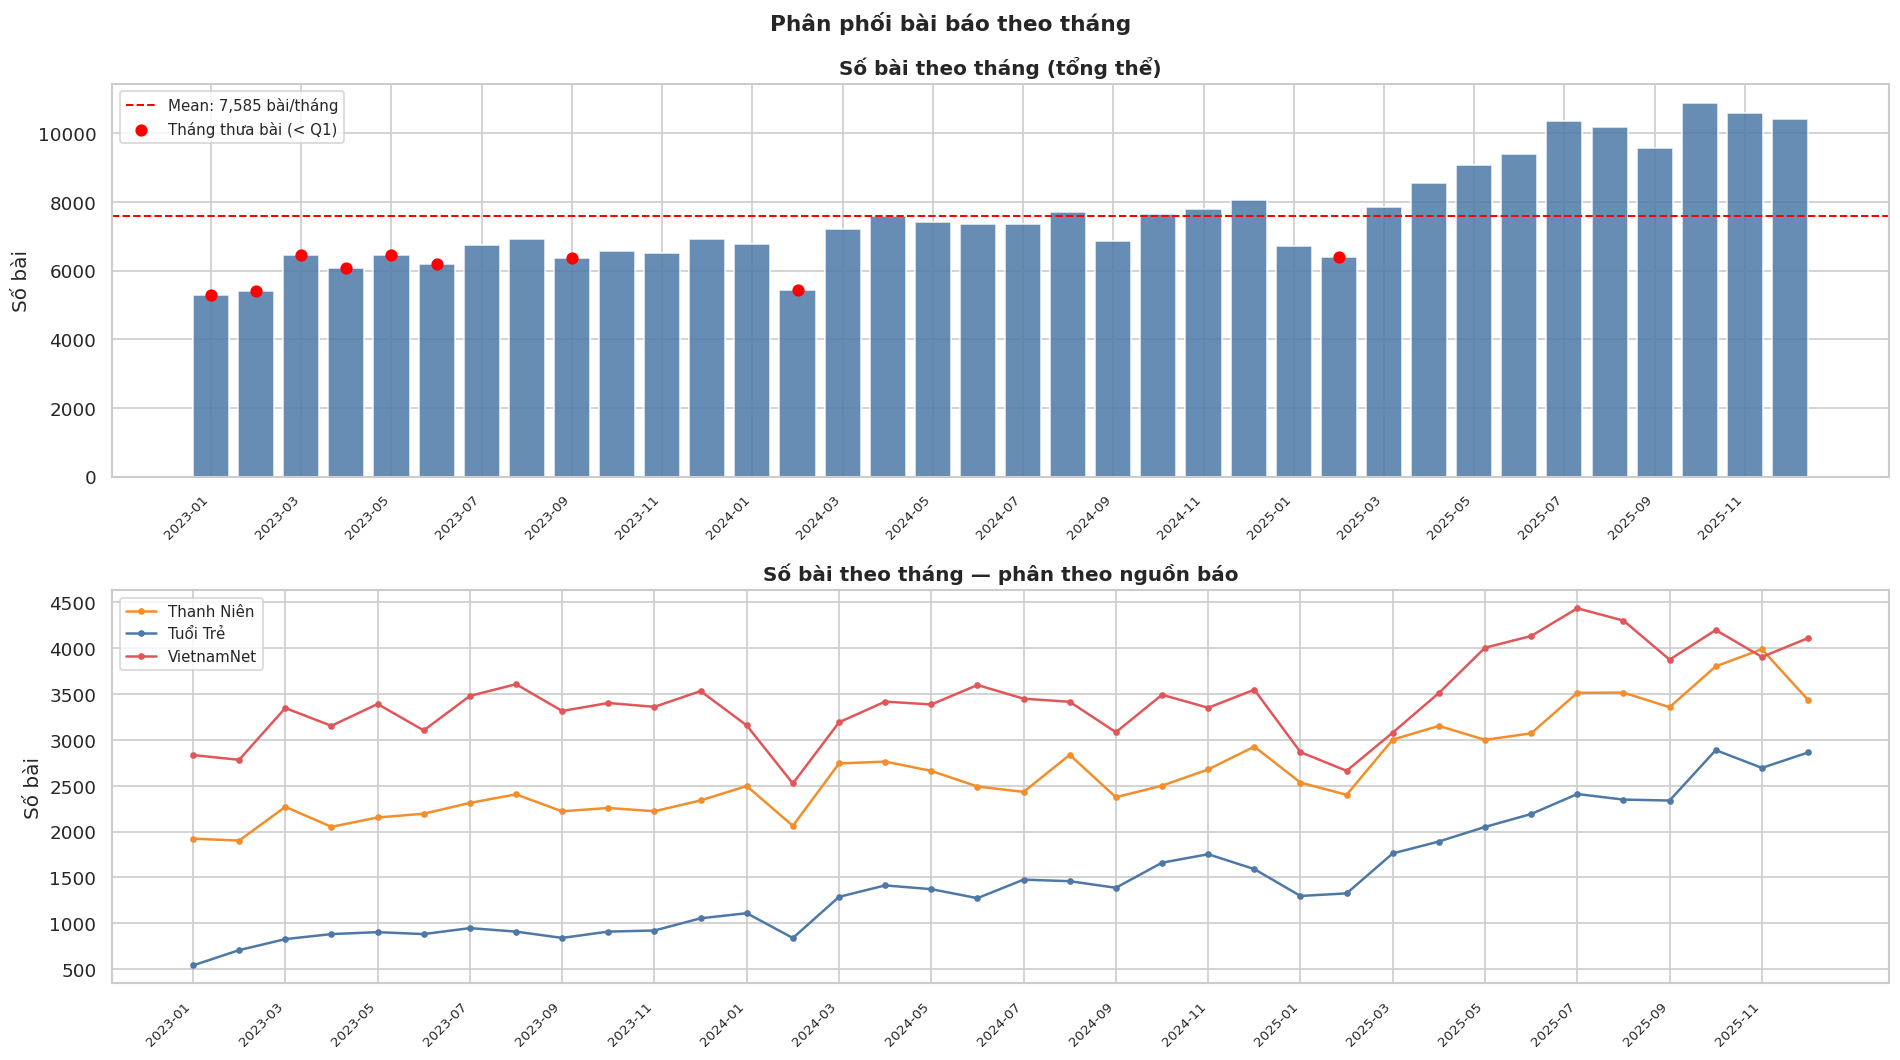


9 tháng có số bài dưới Q1 (6,490):
 ym_str  count
2023-01   5298
2023-02   5392
2023-03   6445
2023-04   6088
2023-05   6449
2023-06   6181
2023-09   6377
2024-02   5427
2025-02   6390


In [29]:
df_dated = df_eda.dropna(subset=['public_date']).copy()
df_dated['ym'] = df_dated['public_date'].dt.to_period('M')

# Phân phối tổng thể theo tháng
monthly = df_dated.groupby('ym').size().reset_index(name='count')
monthly['ym_str'] = monthly['ym'].astype(str)

# Phân phối theo source theo tháng
monthly_src = (df_dated.groupby(['ym', 'source']).size()
                        .reset_index(name='count'))
monthly_src['ym_str'] = monthly_src['ym'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- Plot 1: Tổng số bài theo tháng ---
axes[0].bar(monthly['ym_str'], monthly['count'],
            color='#4e79a7', edgecolor='white', alpha=0.85)
axes[0].axhline(monthly['count'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f"Mean: {monthly['count'].mean():,.0f} bài/tháng")

# Đánh dấu tháng thấp bất thường (< 25th percentile)
p25 = monthly['count'].quantile(0.25)
low_months = monthly[monthly['count'] < p25]
axes[0].scatter(low_months['ym_str'], low_months['count'],
                color='red', zorder=5, s=40, label='Tháng thưa bài (< Q1)')

axes[0].set_ylabel('Số bài')
axes[0].set_title('Số bài theo tháng (tổng thể)', fontweight='bold')
axes[0].legend(fontsize=9)
tick_step = max(1, len(monthly) // 18)
axes[0].set_xticks(range(0, len(monthly), tick_step))
axes[0].set_xticklabels(monthly['ym_str'][::tick_step], rotation=45, ha='right', fontsize=8)

# --- Plot 2: Theo source ---
for src, grp in monthly_src.groupby('source'):
    axes[1].plot(grp['ym_str'], grp['count'],
                 marker='o', markersize=3, linewidth=1.5,
                 color=SOURCE_COLORS.get(src, '#999'), label=src)

axes[1].set_ylabel('Số bài')
axes[1].set_title('Số bài theo tháng — phân theo nguồn báo', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(0, len(monthly), tick_step))
axes[1].set_xticklabels(monthly['ym_str'][::tick_step], rotation=45, ha='right', fontsize=8)

plt.suptitle('Phân phối bài báo theo tháng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if not low_months.empty:
    print(f'\n{len(low_months)} tháng có số bài dưới Q1 ({p25:,.0f}):')
    print(low_months[['ym_str', 'count']].to_string(index=False))

#### Nhận xét Phân phối thời gian theo tháng

**Xu hướng tổng thể tăng trưởng rõ rệt:** Dataset có xu hướng tăng dần từ ~5,300 bài/tháng đầu 2023 lên ~10,000+ bài/tháng cuối 2025, gần gấp đôi. Điều này phản ánh việc mở rộng thu thập dữ liệu theo thời gian, chủ yếu đến từ sự tăng trưởng mạnh của Tuổi Trẻ và VietnamNet từ 2024 trở đi.

**Không có khoảng trống thời gian:** Tất cả 36 tháng đều có dữ liệu — dataset liên tục, không bị đứt đoạn. Đây là điểm tốt đảm bảo tính đại diện theo thời gian.

**9 tháng dưới Q1 (6,490 bài) có thể giải thích rõ ràng, không phải lỗi thu thập:**

- **2023-01, 2023-02** (~5,300–5,400 bài): Dataset bắt đầu từ tháng 1/2023 nên tháng đầu có thể chỉ crawl được từ giữa tháng, hoặc hệ thống thu thập chưa ổn định.
- **2023-03 đến 2023-09** (6 tháng): Giai đoạn đầu của dataset khi lượng bài còn thấp — xu hướng tăng dần từ đó đến nay cho thấy đây là đặc điểm tự nhiên của quá trình thu thập.
- **2024-02, 2025-02**: Tháng 2 ít ngày hơn (28–29 ngày) cộng thêm Tết Nguyên Đán khiến lượng bài đăng giảm tự nhiên — pattern này lặp lại cả 3 năm, hoàn toàn có thể giải thích được.

**Phân theo nguồn:** VietnamNet dẫn đầu ổn định suốt toàn bộ giai đoạn. Tuổi Trẻ tăng mạnh nhất từ 2024, từ ~800–900 bài/tháng lên ~2,500–2,800 bài/tháng — mức tăng gần 3x. Thanh Niên tăng đều và ổn định hơn.

**Kết luận:** Không phát hiện khoảng trống hay bất thường nghiêm trọng. Các tháng có số bài thấp hơn Q1 không cho thấy khoảng trống dữ liệu nghiêm trọng, nhưng vẫn nên được ghi nhận như một dấu hiệu cần kiểm tra khi đánh giá mô hình theo thời gian. Một số nguyên nhân có thể bao gồm số ngày trong tháng, dịp Tết, biến động tần suất đăng bài hoặc sự thay đổi trong quá trình thu thập dữ liệu.

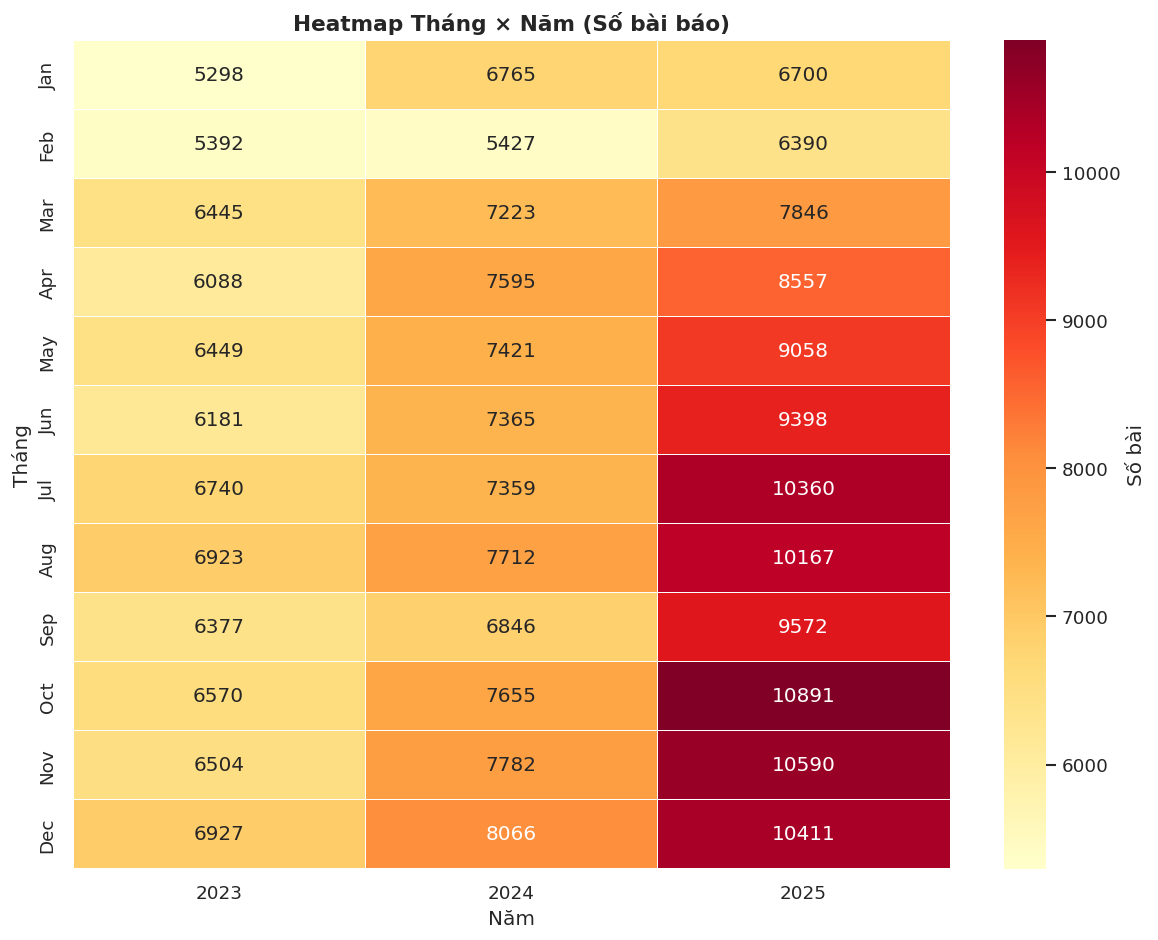

=== HEATMAP THÁNG × NĂM ===


year,2023,2024,2025
Jan,5298,6765,6700
Feb,5392,5427,6390
Mar,6445,7223,7846
Apr,6088,7595,8557
May,6449,7421,9058
Jun,6181,7365,9398
Jul,6740,7359,10360
Aug,6923,7712,10167
Sep,6377,6846,9572
Oct,6570,7655,10891


In [30]:
monthly_pivot = df_dated.groupby(['year', 'month']).size().reset_index(name='count')
heatmap_data = monthly_pivot.pivot(index='month', columns='year', values='count').fillna(0).astype(int)

# Đặt tên tháng
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.index = [month_names[i-1] for i in heatmap_data.index]

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Số bài'}, ax=ax,
            vmin=heatmap_data.min().min(), vmax=heatmap_data.max().max())

ax.set_title('Heatmap Tháng × Năm (Số bài báo)', fontweight='bold', fontsize=13)
ax.set_xlabel('Năm')
ax.set_ylabel('Tháng')

plt.tight_layout()
plt.show()

print('=== HEATMAP THÁNG × NĂM ===')
display(heatmap_data)

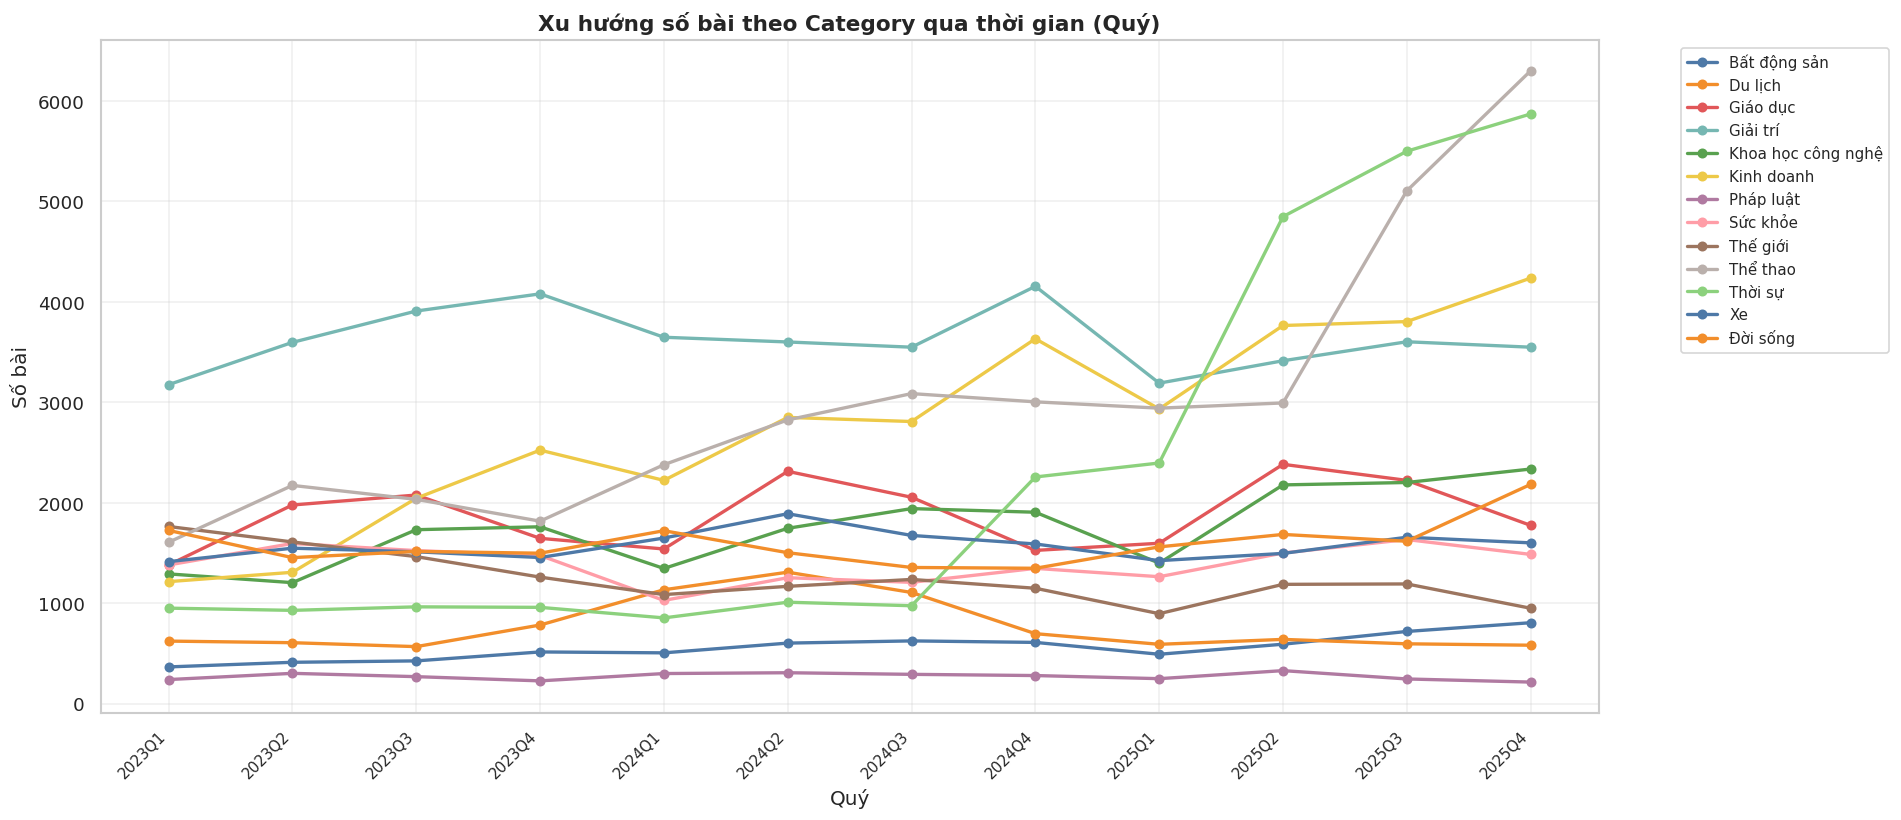

=== XU HƯỚNG CATEGORY THEO QUÝ ===

Bất động sản:
  Q đầu: 366 (giảm/tăng từ 2023Q1)
  Q cuối: 806 (2025Q4)
  Thay đổi: +440

Du lịch:
  Q đầu: 623 (giảm/tăng từ 2023Q1)
  Q cuối: 582 (2025Q4)
  Thay đổi: -41

Giáo dục:
  Q đầu: 1,381 (giảm/tăng từ 2023Q1)
  Q cuối: 1,775 (2025Q4)
  Thay đổi: +394

Giải trí:
  Q đầu: 3,176 (giảm/tăng từ 2023Q1)
  Q cuối: 3,549 (2025Q4)
  Thay đổi: +373

Khoa học công nghệ:
  Q đầu: 1,292 (giảm/tăng từ 2023Q1)
  Q cuối: 2,336 (2025Q4)
  Thay đổi: +1,044

Kinh doanh:
  Q đầu: 1,215 (giảm/tăng từ 2023Q1)
  Q cuối: 4,237 (2025Q4)
  Thay đổi: +3,022

Pháp luật:
  Q đầu: 240 (giảm/tăng từ 2023Q1)
  Q cuối: 215 (2025Q4)
  Thay đổi: -25

Sức khỏe:
  Q đầu: 1,381 (giảm/tăng từ 2023Q1)
  Q cuối: 1,486 (2025Q4)
  Thay đổi: +105

Thế giới:
  Q đầu: 1,764 (giảm/tăng từ 2023Q1)
  Q cuối: 950 (2025Q4)
  Thay đổi: -814

Thể thao:
  Q đầu: 1,607 (giảm/tăng từ 2023Q1)
  Q cuối: 6,301 (2025Q4)
  Thay đổi: +4,694

Thời sự:
  Q đầu: 951 (giảm/tăng từ 2023Q1)
  Q cuối: 5,87

In [31]:
# Tính số bài theo category và quý
df_dated['quarter'] = df_dated['public_date'].dt.to_period('Q')

quarterly_cat = (df_dated.groupby(['quarter', 'category']).size()
                         .reset_index(name='count'))
quarterly_cat['quarter_str'] = quarterly_cat['quarter'].astype(str)

# Vẽ line chart
fig, ax = plt.subplots(figsize=(16, 7))

for cat in df_eda['category'].unique():
    cat_data = quarterly_cat[quarterly_cat['category'] == cat]
    ax.plot(cat_data['quarter_str'], cat_data['count'],
            marker='o', markersize=5, linewidth=2,
            label=cat, color=COLORS[list(df_eda['category'].unique()).index(cat) % len(COLORS)])

ax.set_xlabel('Quý')
ax.set_ylabel('Số bài')
ax.set_title('Xu hướng số bài theo Category qua thời gian (Quý)', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3)

# Xoay nhãn trục X để dễ đọc
tick_step = max(1, len(quarterly_cat['quarter_str'].unique()) // 12)
ax.set_xticks(range(0, len(quarterly_cat['quarter_str'].unique()), tick_step))
ax.set_xticklabels(quarterly_cat['quarter_str'].unique()[::tick_step], rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

print('=== XU HƯỚNG CATEGORY THEO QUÝ ===')
# Hiển thị một số thống kê tóm tắt
for cat in df_eda['category'].unique():
    cat_trend = quarterly_cat[quarterly_cat['category'] == cat]
    print(f'\n{cat}:')
    print(f'  Q đầu: {cat_trend.iloc[0]["count"]:,} (giảm/tăng từ {cat_trend.iloc[0]["quarter_str"]})')
    print(f'  Q cuối: {cat_trend.iloc[-1]["count"]:,} ({cat_trend.iloc[-1]["quarter_str"]})')
    print(f'  Thay đổi: {cat_trend.iloc[-1]["count"] - cat_trend.iloc[0]["count"]:+,}')

### 3.2. Nhận xét xu hướng số bài theo Category qua thời gian theo quý

Biểu đồ cho thấy số lượng bài viết giữa các category có sự biến động khá rõ theo thời gian, đặc biệt từ năm 2025 trở đi. Một số chủ đề có xu hướng tăng mạnh, trong khi một số nhóm khác duy trì ổn định hoặc chỉ dao động nhẹ.

**Nhóm tăng mạnh nhất là `Thời sự` và `Thể thao`.**
Từ khoảng 2025Q2, số bài thuộc nhóm `Thời sự` tăng rất nhanh, vượt lên mức hơn 4,800 bài và tiếp tục đạt gần 5,900 bài vào 2025Q4. Nhóm `Thể thao` cũng tăng đột biến từ 2025Q3, đạt hơn 5,000 bài và cao nhất ở 2025Q4 với hơn 6,000 bài. Đây là hai category có mức tăng nổi bật nhất toàn biểu đồ.

**Nhóm `Giải trí` có số lượng bài cao và khá ổn định.**
Trong hầu hết các quý, `Giải trí` luôn nằm ở nhóm có số bài cao, dao động quanh mức 3,200–4,100 bài. Tuy có giảm nhẹ ở 2025Q1 nhưng sau đó tăng lại và duy trì trên 3,500 bài.

**Nhóm `Kinh doanh` tăng rõ sau giai đoạn 2024.**
Từ 2023Q1 đến 2024Q4, số bài `Kinh doanh` tăng dần và có một đỉnh ở 2024Q4. Sau đó tiếp tục tăng mạnh trong năm 2025, đạt hơn 4,000 bài ở 2025Q4. Điều này cho thấy dữ liệu về kinh doanh được thu thập ngày càng nhiều ở các quý gần đây.

**Một số nhóm có mức trung bình và dao động vừa phải như `Khoa học công nghệ`, `Giáo dục`, `Xe`, `Đời sống`, `Thế giới`.**
Các nhóm này không tăng đột biến như `Thời sự` hay `Thể thao`, nhưng vẫn có sự thay đổi theo quý. Trong đó `Khoa học công nghệ` có xu hướng tăng vào cuối 2025, `Đời sống` tăng mạnh ở 2025Q4, còn `Giáo dục` dao động khá lớn giữa các quý.

**Các nhóm có số bài thấp và ổn định hơn gồm `Bất động sản`, `Du lịch`, `Pháp luật`, `Sức khỏe`.**
Những category này thường nằm dưới mức 1,500 bài/quý. Đặc biệt `Pháp luật` có số bài thấp nhất và ít biến động nhất, cho thấy đây là nhóm dữ liệu nhỏ hơn đáng kể so với các nhóm còn lại.

**Kết luận:**
Phân phối dữ liệu theo thời gian không đồng đều giữa các category. Các chủ đề như `Thời sự`, `Thể thao`, `Giải trí`, `Kinh doanh` chiếm ưu thế và có xu hướng tăng mạnh ở các quý gần đây, trong khi một số nhóm như `Pháp luật`, `Bất động sản`, `Du lịch` có số lượng bài thấp hơn nhiều. 


## 4. Phân tích Missing Values

> **Lý do:** xác định chiến lược xử lý cho từng nhóm cột: cột văn bản cốt lõi, nhãn, metadata truy vết và các trường hỗ trợ phân tích.

=== MISSING VALUES ===


Cột,Số bản ghi thiếu,Tỉ lệ (%)
author,27100,9.920000
content,2107,0.770000
description,158,0.060000
tag,85,0.030000
public_date,8,0.000000
title,2,0.000000
sub_topic,0,0.000000
category,0,0.000000
source,0,0.000000
url,0,0.000000


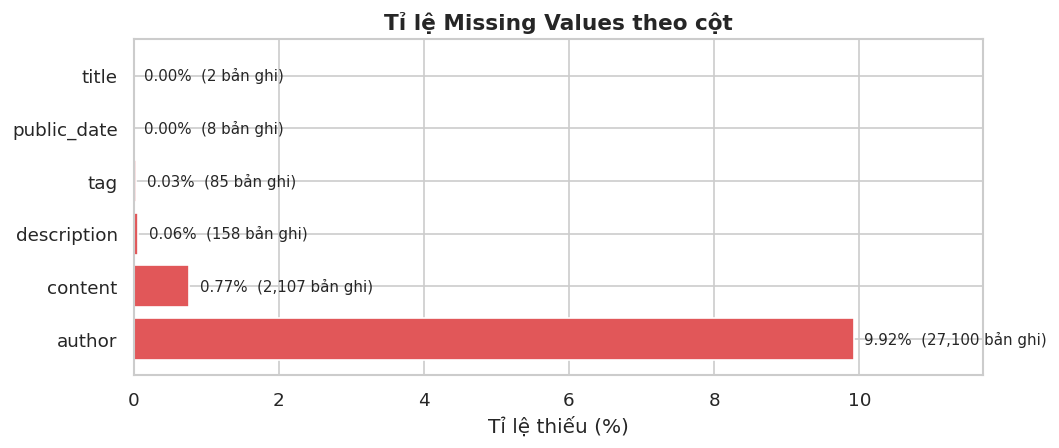

In [32]:
exclude_cols = ['year', 'month']
df_missing = df_eda.drop(columns=exclude_cols, errors='ignore')

missing = df_missing.isnull().sum().reset_index()
missing.columns = ['Cột', 'Số bản ghi thiếu']
missing['Tỉ lệ (%)'] = (missing['Số bản ghi thiếu'] / len(df_missing) * 100).round(2)
missing = missing.sort_values('Số bản ghi thiếu', ascending=False)

print('=== MISSING VALUES ===')
display(
    missing.style
    .hide(axis='index')
    .background_gradient(subset=['Tỉ lệ (%)'], cmap='Reds')
)

cols_missing = missing[missing['Số bản ghi thiếu'] > 0]

fig, ax = plt.subplots(figsize=(9, max(3, len(cols_missing) * 0.65)))

if not cols_missing.empty:
    bars = ax.barh(
        cols_missing['Cột'],
        cols_missing['Tỉ lệ (%)'],
        color='#e15759',
        edgecolor='white'
    )

    max_val = cols_missing['Tỉ lệ (%)'].max()
    offset = max_val * 0.015

    for bar, val, count in zip(
        bars,
        cols_missing['Tỉ lệ (%)'],
        cols_missing['Số bản ghi thiếu']
    ):
        ax.text(
            val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%  ({count:,} bản ghi)',
            va='center',
            fontsize=9
        )

    ax.set_xlabel('Tỉ lệ thiếu (%)')
    ax.set_title(
        'Tỉ lệ Missing Values theo cột',
        fontweight='bold',
        fontsize=13
    )

    ax.set_xlim(0, max_val * 1.18)

else:
    ax.text(
        0.5, 0.5,
        'Không có missing value!',
        ha='center',
        va='center',
        fontsize=14,
        color='green',
        transform=ax.transAxes
    )
    ax.set_title('Missing Values', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.1. Nhận xét Missing Values

Kết quả missing values cho thấy dữ liệu thiếu không phân bố đều giữa các cột, vì vậy không nên áp dụng một quy tắc xử lý chung cho toàn bộ dataset.

- `title`, `description` và `content` là ba trường văn bản cốt lõi của bài toán phân loại chủ đề. Các dòng thiếu một trong ba trường này cần được loại bỏ, vì nếu giữ lại sẽ làm giảm chất lượng đầu vào và gây nhiễu cho quá trình huấn luyện/evaluation.
- `tag` có tỷ lệ thiếu rất thấp. Tuy nhiên, do phân tích riêng ở phần sau cho thấy `tag` chứa tín hiệu phân loại rất mạnh, trường này không được xem là input mặc định của baseline chính. Việc xử lý thiếu `tag` vì vậy nên gắn với vai trò metadata hoặc bài toán mở rộng, không nên trộn vào baseline phân loại `category`.
- `author` có tỷ lệ thiếu cao nhất nhưng chủ yếu phục vụ thống kê, truy vết và phân tích metadata. Do đó, không nên loại bỏ bài báo chỉ vì thiếu `author`, vì điều này có thể làm mất nhiều dữ liệu nội dung hợp lệ.
- `public_date` thiếu rất ít nhưng cần được parse cẩn thận do dữ liệu đến từ nhiều nguồn báo với định dạng ngày khác nhau. Đặc biệt, một số bản ghi VietnamNet có khoảng trắng trước múi giờ `+07:00`, nên bước cleaning chính thức cần chuẩn hóa format trước khi tạo các trường `year`, `month`.

Tóm lại, missing ở các trường văn bản chính nên được xử lý nghiêm ngặt hơn metadata. Các metadata như `author`, `source`, `url`, `public_date`, `sub_topic` và `tag` cần được diễn giải theo đúng vai trò sử dụng, tránh nhầm lẫn giữa dữ liệu phục vụ truy vết/phân tích và dữ liệu đầu vào mặc định cho mô hình.

## 5. Phân tích Duplicate và chồng chéo nhãn

### 5.1. Duplicate tổng quát

> Duplicate có thể làm mô hình bị bias do một bài hoặc một nội dung xuất hiện nhiều lần. Ngoài ra, nếu cùng một văn bản nhưng có nhiều `category` khác nhau, bài toán supervised learning sẽ bị nhiễu nhãn.

In [33]:
import re
import pandas as pd

URL_COL = "url"

# --- 1. Hàm lấy phần thừa sau .html/.htm ---
def get_after_html(url):
    if pd.isna(url):
        return None

    url = str(url).strip()

    match = re.search(r"\.html?(.*)$", url, flags=re.IGNORECASE)
    if match:
        after = match.group(1)
        return after if after else None

    return None


# --- 2. Hàm clean URL: giữ đến hết .html/.htm ---
def clean_url(url):
    if pd.isna(url):
        return None

    url = str(url).strip()

    # Giữ từ đầu URL đến hết .html hoặc .htm
    match = re.search(r"^(.*?\.html?)", url, flags=re.IGNORECASE)
    if match:
        return match.group(1)

    return url


# --- 3. Kiểm tra phần thừa trước khi clean ---
df_eda["after_html"] = df_eda[URL_COL].apply(get_after_html)

after_html_list = sorted(
    df_eda["after_html"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Số kiểu phần thừa sau .html/.htm: {len(after_html_list):,}")

for item in after_html_list:
    print(item)


# --- 4. Lưu URL cũ tạm thời để đếm số dòng bị thay đổi ---
old_url = df_eda[URL_COL].astype(str).str.strip()


# --- 5. Sửa trực tiếp vào cột url ---
df_eda[URL_COL] = df_eda[URL_COL].apply(clean_url)


# --- 6. Đếm số URL đã bị thay đổi ---
new_url = df_eda[URL_COL].astype(str).str.strip()

num_changed = (old_url != new_url).sum()

print(f"\nSố URL đã được làm sạch: {num_changed:,}")


# --- 7. Kiểm tra lại sau khi clean ---
df_eda["after_html_clean"] = df_eda[URL_COL].apply(get_after_html)

remaining_after_html = sorted(
    df_eda["after_html_clean"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Số kiểu phần thừa còn lại sau khi clean: {len(remaining_after_html):,}")

for item in remaining_after_html:
    print(item)

Số kiểu phần thừa sau .html/.htm: 1
#isreadmore=1

Số URL đã được làm sạch: 506
Số kiểu phần thừa còn lại sau khi clean: 0


In [34]:
dup_full  = df_eda.duplicated().sum()
dup_url   = df_eda['url'].duplicated().sum()   if 'url'   in df_eda.columns else 'N/A'
dup_title = df_eda['title'].duplicated().sum() if 'title' in df_eda.columns else 'N/A'
dup_desc  = df_eda['description'].duplicated().sum() if 'description' in df_eda.columns else 'N/A'
dup_cont  = df_eda['content'].duplicated().sum() if 'content' in df_eda.columns else 'N/A'
dup_all3  = df_eda.duplicated(subset=['title', 'description', 'content']).sum()

b3 = pd.DataFrame({
    'Loại trùng lặp': [
        'Bản ghi trùng hoàn toàn',
        'URL trùng nhau',
        'Tiêu đề (title) trùng nhau',
        'Mô tả (description) trùng nhau',
        'Nội dung (content) trùng nhau',
        'Trùng cả title + description + content',
    ],
    'Số lượng': [dup_full, dup_url, dup_title, dup_desc, dup_cont, dup_all3]
})

print('=== DUPLICATES ===')
display(b3.style.hide(axis='index'))

# Phân bổ duplicate theo source cho từng loại
print('\n--- Phân bổ duplicate theo nguồn báo ---')
for label, col, subset in [
    ('Title trùng',                    'title',       ['title']),
    ('Description trùng',              'description', ['description']),
    ('Content trùng',                  'content',     ['content']),
    ('Title + Description + Content',  None,          ['title', 'description', 'content']),
]:

    dup_rows = df_eda[df_eda.duplicated(subset=subset, keep=False)]

    if len(dup_rows) == 0:
        print(f'\n{label}: không có duplicate')
        continue
    by_src = (dup_rows.groupby('source').size()
                        .reset_index(name='Số bài')
                        .assign(**{'Tỉ lệ (%)': lambda x: (x['Số bài'] / len(dup_rows) * 100).round(2)}))
    print(f'\n{label} ({len(dup_rows):,} bài):')
    display(by_src.style.hide(axis='index'))

=== DUPLICATES ===


Loại trùng lặp,Số lượng
Bản ghi trùng hoàn toàn,0
URL trùng nhau,94
Tiêu đề (title) trùng nhau,954
Mô tả (description) trùng nhau,1270
Nội dung (content) trùng nhau,4119
Trùng cả title + description + content,97



--- Phân bổ duplicate theo nguồn báo ---

Title trùng (1,804 bài):


source,Số bài,Tỉ lệ (%)
Thanh Niên,329,18.240000
Tuổi Trẻ,347,19.240000
VietnamNet,1128,62.530000



Description trùng (1,534 bài):


source,Số bài,Tỉ lệ (%)
Thanh Niên,759,49.480000
Tuổi Trẻ,386,25.160000
VietnamNet,389,25.360000



Content trùng (4,513 bài):


source,Số bài,Tỉ lệ (%)
Thanh Niên,294,6.510000
Tuổi Trẻ,201,4.450000
VietnamNet,4018,89.030000



Title + Description + Content (194 bài):


source,Số bài,Tỉ lệ (%)
Tuổi Trẻ,188,96.910000
VietnamNet,6,3.090000


### Phân tích hiện tượng trùng `content`

EDA trước đó cho thấy số dòng trùng `content` lớn hơn đáng kể so với số URL trùng. Điều này cho thấy hiện tượng trùng nội dung không chỉ đến từ việc crawl trùng cùng một URL, mà có thể đến từ các trường hợp: cùng một bài có nhiều URL khác nhau, cùng nội dung được đăng lại ở cùng nguồn, cùng nội dung xuất hiện ở nhiều nguồn, hoặc cùng nội dung nhưng được gán category khác nhau. Phần này phân tích sâu hơn các nhóm bài có `content` giống nhau để xác định nguyên nhân.

In [48]:
df_dup = df_eda.copy()

if 'content_norm' not in df_dup.columns:
    df_dup['content_norm'] = (
        df_dup['content']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

if 'url_norm' not in df_dup.columns and 'url' in df_dup.columns:
    url_until_html = df_dup['url'].astype('string').str.strip().str.extract(
        r'^(.*?\.html?)',
        expand=False
    )
    df_dup['url_norm'] = url_until_html.fillna(df_dup['url'].astype('string').str.strip())

url_col = 'url_norm' if 'url_norm' in df_dup.columns else 'url'

dup_content_rows = df_dup[df_dup.duplicated(subset=['content_norm'], keep=False)].copy()

print(f"Tổng số dòng nằm trong các nhóm content trùng: {len(dup_content_rows):,}")
print(f"Số nhóm content trùng: {dup_content_rows['content_norm'].nunique():,}")
print(f"Số dòng dư nếu chỉ giữ 1 dòng mỗi nhóm: {df_dup.duplicated(subset=['content_norm'], keep='first').sum():,}")

content_dup_groups = (
    dup_content_rows
    .groupby('content_norm')
    .agg(
        n_rows=('content_norm', 'size'),
        n_unique_url=(url_col, 'nunique'),
        n_unique_source=('source', 'nunique'),
        n_unique_category=('category', 'nunique'),
        n_unique_title=('title', 'nunique'),
        n_unique_description=('description', 'nunique'),
        sources=('source', lambda x: ' | '.join(sorted(x.dropna().astype(str).unique()))),
        categories=('category', lambda x: ' | '.join(sorted(x.dropna().astype(str).unique()))),
        sample_title=('title', 'first')
    )
    .reset_index()
    .sort_values('n_rows', ascending=False)
)

print("\n=== TOP NHÓM CONTENT TRÙNG NHIỀU NHẤT ===")
display(
    content_dup_groups
    .drop(columns=['content_norm'])
    .head(20)
)

Tổng số dòng nằm trong các nhóm content trùng: 4,513
Số nhóm content trùng: 394
Số dòng dư nếu chỉ giữ 1 dòng mỗi nhóm: 4,119

=== TOP NHÓM CONTENT TRÙNG NHIỀU NHẤT ===


,n_rows,n_unique_url,n_unique_source,n_unique_category,n_unique_title,n_unique_description,sources,categories,sample_title
0,2107,2107,3,12,1989,2075,Thanh Niên | Tuổi Trẻ | VietnamNet,Bất động sản | Du lịch | Giáo dục | Giải trí | Khoa học công nghệ | Kinh doanh | Sức khỏe | Thế giới | Thể thao | Thời sự | Xe | Đời sống,Vì sao shop tại Phú Mỹ Hưng có giá trị khai thác hiệu quả?
18,163,163,1,1,163,163,VietnamNet,Giải trí,"Sao Việt 31/10/2025: Mai Phương Thúy ốm vẫn tấu hài, Trương Ngọc Ánh U50 sexy"
5,119,119,1,1,119,119,VietnamNet,Giải trí,Sao Việt 24/8/2025: H'Hen Niê hài hước trêu chồng mặc áo vợ
132,87,87,1,1,86,87,VietnamNet,Thể thao,Lịch thi đấu bóng đá hôm nay 25/3
320,55,55,1,1,55,55,VietnamNet,Thể thao,Lịch thi đấu bóng đá hôm nay 7/4
6,45,45,1,1,45,45,VietnamNet,Giải trí,"Sao Việt 28/2/2025: Ngô Thanh Vân ôm chồng trẻ, nam MC 'cưỡng hôn' Xuân Son"
16,43,43,1,1,43,43,VietnamNet,Giải trí,"Sao Việt 30/6/2024: Quang Lê thon gọn, Trương Ngọc Ánh xinh đẹp bên con gái"
17,42,42,1,1,42,42,VietnamNet,Giải trí,"Sao Việt 30/8/2024: Diễn viên Việt Anh khoe cơ bắp, NSND Thu Quế khoe eo tuổi 55"
364,38,38,1,1,38,38,VietnamNet,Giải trí,"Diện áo dài nền nã, Ý Nhi 'đốn tim' người hâm mộ với nhan sắc xinh đẹp ở Úc"
19,36,36,1,1,36,36,VietnamNet,Giải trí,"Sao Việt 31/12/2025: Con gái Vũ Linh xinh đẹp, diva Hồng Nhung sau vụ hủy show"


In [49]:
# =========================
# PHÂN LOẠI NGUYÊN NHÂN CONTENT TRÙNG
# =========================

content_dup_groups['duplicate_type'] = 'Khác'

content_dup_groups.loc[
    content_dup_groups['n_unique_url'] == 1,
    'duplicate_type'
] = 'Cùng content - cùng URL'

content_dup_groups.loc[
    (content_dup_groups['n_unique_url'] > 1) &
    (content_dup_groups['n_unique_source'] == 1),
    'duplicate_type'
] = 'Cùng content - khác URL - cùng source'

content_dup_groups.loc[
    content_dup_groups['n_unique_source'] > 1,
    'duplicate_type'
] = 'Cùng content - khác source'

duplicate_type_summary = (
    content_dup_groups
    .groupby('duplicate_type')
    .agg(
        so_nhom=('duplicate_type', 'size'),
        so_dong=('n_rows', 'sum'),
        so_dong_du=('n_rows', lambda x: (x - 1).sum())
    )
    .reset_index()
    .sort_values('so_dong', ascending=False)
)

duplicate_type_summary['ti_le_dong_%'] = (
    duplicate_type_summary['so_dong'] / duplicate_type_summary['so_dong'].sum() * 100
).round(2)

print("=== PHÂN LOẠI KIỂU TRÙNG CONTENT ===")
display(duplicate_type_summary.style.hide(axis='index'))

=== PHÂN LOẠI KIỂU TRÙNG CONTENT ===


duplicate_type,so_nhom,so_dong,so_dong_du,ti_le_dong_%
Cùng content - khác URL - cùng source,299,2218,1919,49.150000
Cùng content - khác source,1,2107,2106,46.690000
Cùng content - cùng URL,94,188,94,4.170000


In [50]:
# =========================
# CONTENT TRÙNG NHƯNG KHÁC CATEGORY
# =========================

label_conflict_groups = content_dup_groups[
    content_dup_groups['n_unique_category'] > 1
].copy()

print(f"Số nhóm content trùng nhưng khác category: {len(label_conflict_groups):,}")
print(f"Số dòng thuộc các nhóm content trùng nhưng khác category: {label_conflict_groups['n_rows'].sum():,}")

display(
    label_conflict_groups
    .drop(columns=['content_norm'])
    .sort_values(['n_unique_category', 'n_rows'], ascending=False)
    .head(20)
)

Số nhóm content trùng nhưng khác category: 29
Số dòng thuộc các nhóm content trùng nhưng khác category: 2,205


,n_rows,n_unique_url,n_unique_source,n_unique_category,n_unique_title,n_unique_description,sources,categories,sample_title,duplicate_type
0,2107,2107,3,12,1989,2075,Thanh Niên | Tuổi Trẻ | VietnamNet,Bất động sản | Du lịch | Giáo dục | Giải trí | Khoa học công nghệ | Kinh doanh | Sức khỏe | Thế giới | Thể thao | Thời sự | Xe | Đời sống,Vì sao shop tại Phú Mỹ Hưng có giá trị khai thác hiệu quả?,Cùng content - khác source
332,11,11,1,3,11,11,VietnamNet,Thể thao | Xe | Đời sống,Than KSVN đăng quang cúp Quốc gia sau loạt 'đấu súng',Cùng content - khác URL - cùng source
319,7,7,1,3,7,7,VietnamNet,Du lịch | Thể thao | Đời sống,Con đường hoa kèn hồng nở rộ đẹp 'mê hồn' ở miền Tây,Cùng content - khác URL - cùng source
374,11,11,1,2,11,11,VietnamNet,Giải trí | Thể thao,"Diễn viên Thu Hà, Thu Quế và loạt NSND đình đám cùng lúc đón tin vui",Cùng content - khác URL - cùng source
233,10,10,1,2,10,10,VietnamNet,Xe | Đời sống,Chiếc Bugatti Chiron Pur Sport cuối cùng được bàn giao tới khách hàng,Cùng content - khác URL - cùng source
4,5,5,1,2,5,5,VietnamNet,Giải trí | Khoa học công nghệ,Nữ phát thanh viên Hàn Quốc nổi tiếng sau show hẹn hò,Cùng content - khác URL - cùng source
315,5,5,1,2,5,5,VietnamNet,Kinh doanh | Thời sự,Làng hoa nổi tiếng Đà Nẵng hối hả vào vụ Tết Nguyên Đán 2024,Cùng content - khác URL - cùng source
33,3,3,1,2,3,3,VietnamNet,Kinh doanh | Sức khỏe,BE - Hành trình 5 năm phát triển ngoạn mục tại Việt Nam,Cùng content - khác URL - cùng source
246,3,3,1,2,3,3,VietnamNet,Bất động sản | Sức khỏe,Vinhomes Ocean Park 2 - Đại đô thị của những kỷ lục phía Đông Hà Nội,Cùng content - khác URL - cùng source
78,3,3,1,2,3,3,VietnamNet,Du lịch | Kinh doanh,Hàng loạt show diễn đẳng cấp ‘đổ bộ’ thị trấn Hoàng Hôn,Cùng content - khác URL - cùng source


In [51]:
# =========================
# XEM CHI TIẾT VÀI NHÓM CONTENT TRÙNG KHÁC CATEGORY
# =========================

cols_to_show = [
    'source', 'category', 'sub_topic',
    'title', 'description', url_col, 'public_date'
]

for content_value in label_conflict_groups['content_norm'].head(5):
    print("=" * 120)
    print("NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY")
    
    display(
        df_dup[df_dup['content_norm'] == content_value][cols_to_show]
        .sort_values(['source', 'category', 'public_date'])
    )
    
    print("Sample content:")
    print(str(content_value)[:1200])

NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
75894,Thanh Niên,Du lịch,kham pha,Traveloka EPIC Sale 2023 thành công với lượng giao dịch tăng gấp đôi,"Ngày 14.4, Traveloka - nền tảng du lịch hàng đầu Đông Nam Á - kết thúc chương trình EPIC Sale với những kết quả tích cực. Chương trình khuyến mãi đã diễn ra từ 30.3 tới 5.4",https://thanhnien.vn/traveloka-epic-sale-2023-thanh-cong-voi-luong-giao-dich-tang-gap-doi-185230417181126561.htm,2023-04-17 19:00:00+07:00
78210,Thanh Niên,Du lịch,kham pha,"Trải nghiệm ẩm thực vẹn tròn hương vị, cùng view choáng ngợp ở LAGarden Restaurant","Nếu muốn có một buổi hẹn hò lãng mạn hay một buổi tiệc ấm áp trong một chiều lộng gió ở ven sông Sài Gòn, nhà hàng LAGarden ở TP.Thủ Đức (TP.HCM) sẽ là lựa chọn không thể nào phù hợp hơn. Các món đặc trưng của nhà hàng sử dụng nguyên liệu Việt được chế tác theo phong cách đương đại đa dạng, cho thực khách những trải nghiệm khó quên cả vị giác lẫn thị giác, kết hợp với quang cảnh bến du thuyền ven sông Sài Gòn cùng ánh đèn lung linh đẹp choáng ngợp - đây chắc chắn không chỉ là sự trải nghiệm, mà còn là những kỷ niệm đọng lại trong từng cung bậc cảm xúc!",https://thanhnien.vn/trai-nghiem-am-thuc-ven-tron-huong-vi-cung-view-choang-ngop-o-lagarden-restaurant-185240805104104511.htm,2024-08-05 10:49:00+07:00
103701,Thanh Niên,Giáo dục,tuyen sinh,Thi tốt nghiệp THPT 2023: Thí sinh chính thức bước vào làm bài môn ngữ văn,"Sáng nay (28.6), hơn 1 triệu thí sinh trên toàn quốc bước vào môn thi đầu tiên (ngữ văn) trong kỳ thi tốt nghiệp THPT 2023.",https://thanhnien.vn/hon-1-trieu-thi-sinh-chinh-thuc-buoc-vao-ky-thi-tot-nghiep-thpt-2023-185230627152515857.htm,2023-06-28 06:02:00+07:00
102911,Thanh Niên,Giáo dục,tuyen sinh,"Sáng nay, hơn 1 triệu thí sinh thi tốt nghiệp THPT cuối cùng theo chương trình cũ","Sáng nay (27.6), hơn 1 triệu thí sinh trên cả nước chính thức bước vào kỳ thi tốt nghiệp THPT với bài thi đầu tiên là môn ngữ văn.",https://thanhnien.vn/sang-nay-hon-1-trieu-thi-sinh-thi-tot-nghiep-thpt-cuoi-cung-theo-chuong-trinh-cu-185240626184228796.htm,2024-06-27 05:55:00+07:00
102454,Thanh Niên,Giáo dục,tuyen sinh,Đề văn tốt nghiệp THPT 2025: 'Vùng trời quê hương nào cũng là bầu trời Tổ quốc',"Sáng nay (26.6), 1.165.289 thí sinh chính thức bước vào kỳ thi tốt nghiệp THPT 2025, một kỳ thi có ý nghĩa lịch sử với nhiều thay đổi lớn và diễn ra trong bối cảnh đặc biệt của đất nước.",https://thanhnien.vn/sang-nay-gan-12-trieu-thi-sinh-buoc-vao-ky-thi-tot-nghiep-thpt-lich-su-185250625145725238.htm,2025-06-26 05:54:00+07:00
...,...,...,...,...,...,...,...
269991,VietnamNet,Đời sống,gioi tre,"9X Bắc Giang làm linh vật rắn thân thiện, đáng yêu khiến nhiều người thích thú","Linh vật 'Rắn hạnh phúc' của anh Quân với tông màu xanh chủ đạo, được làm bằng xi măng, cốt thép với chiều cao 5,1m, nặng 7 tấn, khiến nhiều người thích thú.",https://vietnamnet.vn/9x-bac-giang-lam-linh-vat-ran-than-thien-dang-yeu-khien-nhieu-nguoi-thich-thu-2363372.html,2025-01-16 05:30:00+07:00
267897,VietnamNet,Đời sống,chuyen la,Hội thi 'make-up' cho trâu có 1-0-2 tại Hà Nam,"Tại Hội thi vẽ trang trí trâu Đọi Sơn (Duy Tiên, Hà Nam), những chú trâu đẹp nhất, chất lượng nhất sẽ được tuyển chọn để trở thành 'mẫu make-up' của các họa sĩ.",https://vietnamnet.vn/hoi-thi-make-up-cho-trau-co-1-0-2-tai-ha-nam-2368320.html,2025-02-04 14:25:37+07:00
267894,VietnamNet,Đời sống,chuyen la,Ngắm những 'nàng' trâu to khỏe được trang điểm đẹp mắt ở Hà Nam,"Những “nàng” trâu to khoẻ, khoác trên mình “bộ cánh” sặc sỡ từ lâu đã trở thành điểm nhấn độc đáo trong lễ hội Tịch điền Đọi Sơn (thị xã Duy Tiên, tỉnh Hà Nam).",https://vietnamnet.vn/ngam-nhung-nang-trau-to-khoe-duoc-trang-diem-dep-mat-o-ha-nam-2368323.html,2025-02-04 21:32:00+07:00
263102,VietnamNet,Đời sống,gia đinh,"Dân Hội An chật vật chạy đua với lũ, nước dâng đến đâu kê cao đồ đến đó","Mưa lớn kéo dài khiến nhiều khu vực ở Hội An (TP Đà Nẵng) càng về chiều tối càng ngập sâu. Người dân phố cổ chật vật “chạy đua” với nước lũ, túc trực suốt

Sample content:

NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
168823,VietnamNet,Giải trí,the gioi sao,Vợ trẻ sinh 5 con cho Vượng Râu lần hiếm hoi khoe thân hình nuột nà,"Chọn phong cách thời trang giản dị, lần hiếm hoi vợ trẻ sinh 5 con cho nghệ sĩ Vượng Râu khoe thân hình nuột nà với bikini.",https://vietnamnet.vn/vo-tre-sinh-5-con-cho-vuong-rau-lan-hiem-hoi-kheo-than-hinh-nuot-na-2298193.html,2024-07-07 11:00:00+07:00
168783,VietnamNet,Giải trí,the gioi sao,"'Bà mối quốc dân' Cát Tường: Thủ khoa đại học, từng yêu 3 người kém cả chục tuổi","Cát Tường cho biết đã trải qua ba mối tình với 3 chàng trai kém lần lượt 10, 11 và 13 tuổi.",https://vietnamnet.vn/ba-moi-quoc-dan-cat-tuong-thu-khoa-dai-hoc-tung-yeu-3-nguoi-kem-ca-chuc-tuoi-2298092.html,2024-07-12 12:36:00+07:00
167838,VietnamNet,Giải trí,the gioi sao,"NSƯT Chiều Xuân, Lý Hùng chúc mừng thầy nhân Ngày Nhà giáo Việt Nam 20/11","NSƯT Chiều Xuân, NSND Quốc Hưng, diễn viên Lý Hùng... chúc mừng những người thầy vĩ đại trong cuộc đời mình, nhân dịp Ngày Nhà giáo Việt Nam 20/11.",https://vietnamnet.vn/nsut-chieu-xuan-ly-hung-chuc-mung-thay-nhan-ngay-nha-giao-viet-nam-20-11-2343747.html,2024-11-20 12:31:40+07:00
167672,VietnamNet,Giải trí,the gioi sao,"Dàn hoa hậu, diễn viên nổi tiếng dự đám cưới Khánh Vân và chồng hơn 17 tuổi","Tối 12/12, nhiều hoa hậu, á hậu, ngôi sao nổi tiếng của showbiz Việt tới dự tiệc cưới của hoa hậu Khánh Vân và chồng nhiếp ảnh gia Nguyễn Long tại TPHCM.",https://vietnamnet.vn/dan-hoa-hau-dien-vien-noi-tieng-du-dam-cuoi-khanh-van-va-chong-hon-17-tuoi-2351794.html,2024-12-12 20:46:34+07:00
167228,VietnamNet,Giải trí,the gioi sao,Hồ Ngọc Hà dẫn Kim Lý đi nương tựa Phật pháp,"Dẫn Kim Lý đi nương tựa Phật pháp, Hồ Ngọc Hà hiểu rằng hạnh phúc, tình yêu của con người cuối cùng cũng chỉ cần chữ 'bình an'.",https://vietnamnet.vn/ho-ngoc-ha-dan-kim-ly-di-nuong-tua-phat-phap-2371594.html,2025-02-15 13:01:26+07:00
158007,VietnamNet,Giải trí,phim truyen hinh,"Chỉ sau 1 phim, NSƯT Thái Sơn từ đóng người yêu Ngọc Huyền chuyển sang bố con","Ở phim 'Vui lên nào anh em ơi', Ngọc Huyền đóng bạn gái của Thái Sơn còn trong 'Cha tôi người ở lại' đang phát sóng, hai diễn viên lại đóng bố con dù chênh nhau 14 tuổi.",https://vietnamnet.vn/chi-sau-1-phim-nsut-thai-son-tu-dong-nguoi-yeu-ngoc-huyen-chuyen-sang-bo-con-2379365.html,2025-03-14 05:31:00+07:00
157881,VietnamNet,Giải trí,phim truyen hinh,"Diễn viên Thu Hà, Thu Quế và loạt NSND đình đám cùng lúc đón tin vui","NSND Thu Hà, vợ chồng NSND Thu Quế cùng loạt NSND, NSƯT nổi tiếng vừa được trao kỷ niệm chương vì sự nghiệp điện ảnh.",https://vietnamnet.vn/dien-vien-thu-ha-thu-que-va-loat-nsnd-dinh-dam-cung-luc-don-tin-vui-2393197.html,2025-04-20 14:21:00+07:00
166180,VietnamNet,Giải trí,the gioi sao,Thời trang độc lạ của Lê Dương Bảo Lâm,"Lê Dương Bảo Lâm tiếp tục gây cười với trang phục độc, lạ khi xuất hiện ở buổi ghi hình mùa 4 của chương trình '2 ngày 1 đêm'.",https://vietnamnet.vn/thoi-trang-doc-la-cua-le-duong-bao-lam-2425569.html,2025-07-27 00:00:00+07:00
165475,VietnamNet,Giải trí,the gioi sao,Cuộc sống tròn đầy của diễn viên Phú Đôn bên vợ trẻ kém 25 tuổi,Kết hôn muộn nhưng tròn đầy bên vợ trẻ kém 25 tuổi giúp NSƯT Phú Đôn trở thành một trong những nghệ sĩ hiếm hoi có hạnh phúc bền vững dù bước vào hôn nhân khi tóc đã điểm bạc.,https://vietnamnet.vn/cuoc-song-tron-day-cua-dien-vien-phu-don-ben-vo-tre-kem-25-tuoi-2465720.html,2025-11-30 05:16:00+07:00
222506,VietnamNet,Thể thao,bong đa viet nam,Đức Huy cầu hôn MC Mù Tạt ở Hàn Quốc,Tiền vệ Đức Huy cầu hôn MC VTV Huyền Trang Mù Tạt trong khung cảnh cực lãng mạn tại Hàn Quốc.,https://vietnamnet.vn/duc-huy-cau-hon-mc-mu-tat-o-han-quoc-2467235.html,2025-11-27 22:11:11+07:00


Sample content:
Ảnh: FBNV
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


...

Sample content:
Xem video:
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
257062,VietnamNet,Xe,kham pha,Chiếc Bugatti Chiron Pur Sport cuối cùng được bàn giao tới khách hàng,Chiếc Chiron Pur Sport thứ 60 sở hữu nhiều điểm nhấn đặc biệt ở ngoại thất và nội thất.,https://vietnamnet.vn/chiec-bugatti-chiron-pur-sport-cuoi-cung-duoc-ban-giao-toi-khach-hang-2111877.html,2023-02-19 11:20:42+07:00
269375,VietnamNet,Đời sống,am thuc,Cách muối kim chi giòn ngon chuẩn Hàn,"Vốn được biết đến là món ăn truyền thống của Hàn Quốc, kim chi sở hữu hương vị thơm cay đặc trưng cùng kết cấu giòn ngon và đặc biệt rất dễ làm.",https://vietnamnet.vn/cach-muoi-kim-chi-gion-ngon-chuan-han-2098852.html,2023-01-08 09:21:53+07:00
269356,VietnamNet,Đời sống,am thuc,"7 món dễ làm, chống ngán sau Tết","Sau những ngày Tết với đủ các món thịt mỡ và thừa đạm, loạt món từ rau củ quả hấp dưới đây không chỉ giúp cân bằng dinh dưỡng mà còn tốt cho sức khỏe.",https://vietnamnet.vn/7-mon-de-lam-chong-ngan-sau-tet-2104015.html,2023-01-26 13:13:34+07:00
269347,VietnamNet,Đời sống,am thuc,Những món ăn đường phố nổi tiếng ở Nhật Bản,"Bánh Snoopy Cha-ya, croquette, tempura là những món ăn đường phố thường được nhiều thực khách thưởng thức khi ghé thăm khu chợ Nishiki ở Kyoto.",https://vietnamnet.vn/nhung-mon-an-duong-pho-noi-tieng-o-nhat-ban-2106932.html,2023-02-05 10:11:33+07:00
269340,VietnamNet,Đời sống,am thuc,Canh đậu hũ nấu tôm dễ làm,"Với nguyên liệu dễ kiếm như đậu hũ, tôm, cá viên... người nội trợ có thể tự làm được tô canh thanh mát, đủ dinh dưỡng cho cả gia đình.",https://vietnamnet.vn/canh-dau-hu-nau-tom-de-lam-2111844.html,2023-02-19 09:32:05+07:00
269331,VietnamNet,Đời sống,am thuc,Cách làm đậu hũ Tứ Xuyên đơn giản tại nhà,"Là món ăn truyền thống của vùng Tứ Xuyên (Trung Quốc), đậu hũ Tứ Xuyên sở hữu vị ngọt, cay, đậm và thơm, thường được ăn kèm với cơm trắng.",https://vietnamnet.vn/cach-lam-dau-hu-tu-xuyen-don-gian-tai-nha-2117074.html,2023-03-05 19:57:00+07:00
268778,VietnamNet,Đời sống,chuyen la,Cuộc sống trên hòn đảo 'dư thừa' hàng nghìn nam giới,Cuốn sách 'Atlantic Cowboy' của nhiếp ảnh gia Andrea Gjestvang cho thấy sự mất cân bằng giới tính ở một trong những vùng bị cô lập nhất của Đan Mạch.,https://vietnamnet.vn/cuoc-song-tren-hon-dao-du-thua-hang-nghin-nam-gioi-2122095.html,2023-03-19 08:55:01+07:00
271260,VietnamNet,Đời sống,gioi tre,Cuộc sống của 'thánh ăn Hàn Quốc' sau khi giảm 50kg,"Sau thời gian giảm cân thành công, Yang Soo Bin vẫn giữ được thân hình khỏe khoắn, cân đối. Cô thường xuyên chia sẻ hình ảnh tập gym, mặc trang phục khoe vóc dáng.",https://vietnamnet.vn/cuoc-song-cua-thanh-an-han-quoc-sau-khi-giam-50kg-2128751.html,2023-04-05 13:25:37+07:00
269305,VietnamNet,Đời sống,am thuc,Cách làm món mực chiên giòn rụm cho cuối tuần,"Chế biến bằng nồi chiên không dầu, mực tươi không chỉ giữ được độ mềm mà còn có lớp vỏ giòn rụm, đậm đà ngay miếng cắn đầu tiên.",https://vietnamnet.vn/cach-lam-mon-muc-chien-gion-rum-cho-cuoi-tuan-2135751.html,2023-04-23 13:28:00+07:00
269269,VietnamNet,Đời sống,am thuc,Bí quyết nấu món cải bắp trộn cá ngừ thơm ngậy,Cải bắp thái sợi trộn với cá ngừ có sẵn thích hợp để nhâm nhi lúc rảnh rỗi. Món ăn chỉ mất khoảng 15 phút chế biến.,https://vietnamnet.vn/bi-quyet-nau-mon-cai-bap-tron-ca-ngu-thom-ngay-2155852.html,2023-06-18 15:06:42+07:00


Sample content:
Theo Zing
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
155738,VietnamNet,Du lịch,đi đau choi đi,Con đường hoa kèn hồng nở rộ đẹp 'mê hồn' ở miền Tây,"Con đường gần 1km với hàng trăm cây kèn hồng ở tỉnh Sóc Trăng đang mùa nở hoa rực rỡ, tạo nên khung cảnh vô cùng nên thơ, chẳng khác nào cảnh quay trong những bộ phim lãng mạn.",https://vietnamnet.vn/con-duong-hoa-ken-hong-no-ro-dep-me-hon-o-mien-tay-2255699.html,2024-03-09 14:55:00+07:00
239243,VietnamNet,Thể thao,bong đa quoc te,Man City làm điều đặc biệt tôn vinh 'máy ghi bàn' Haaland,"Các thành viên Man Ciy xếp thành hàng rào chúc mừng Erling Haaland khi tiền đạo Na Uy xô đổ kỷ lục ghi nhiều bàn thắng nhất trong một mùa giải Premier League, với 35 pha lập công.",https://vietnamnet.vn/man-city-lam-dieu-dac-biet-ton-vinh-may-ghi-ban-haaland-2139156.html,2023-05-04 07:30:00+07:00
239028,VietnamNet,Thể thao,bong đa quoc te,Haaland và dàn sao Man City ăn mừng vô địch đầy cảm xúc,"Haaland cùng các đồng đội vô cùng sung sướng, hạnh phúc trong lễ đăng quang Ngoại hạng Anh 2022/23 trên sân Etihad.",https://vietnamnet.vn/man-an-mung-vo-dich-day-cam-xuc-cua-dan-sao-man-city-2145697.html,2023-05-22 01:36:00+07:00
238831,VietnamNet,Thể thao,bong đa quoc te,Man City diễu hành ăn mừng oành tráng ở Manchester,"Đông đảo fan hâm mộ Man City bất chấp trời mưa và sấm sét đã đổ ra đường theo dõi cuộc diễu hành trên xe buýt mui trần của Man City, sau chiến tích 'ăn ba' vĩ đại.",https://vietnamnet.vn/man-city-dieu-hanh-an-mung-oanh-trang-o-manchester-2154050.html,2023-06-13 08:21:00+07:00
237946,VietnamNet,Thể thao,bong đa quoc te,Mauro Icardi biến thành gã hề sau pha dàn xếp penalty láu cá,"Tiền đạo người Argentina bỏ lỡ khó tin trước khung thành rộng mênh mông, khi đồng đội kiến tạo đường chuyền từ chấm 11m.",https://vietnamnet.vn/mauro-icardi-bien-thanh-ga-he-sau-pha-dan-xep-penalty-lau-ca-2194734.html,2023-09-27 05:17:00+07:00
241756,VietnamNet,Thể thao,hau truong,Cole Palmer bị phát hiện 'thư giãn' bên kiều nữ xinh đẹp,Cole Palmer đang tận hưởng kỳ nghỉ của mình cùng một người bạn gái tóc vàng sắc nước hương trời.,https://vietnamnet.vn/cole-palmer-bi-phat-hien-thu-gian-ben-kieu-nu-xinh-dep-2307942.html,2024-08-02 10:32:00+07:00
265907,VietnamNet,Đời sống,gia đinh,Trải lòng của 9X làm đẹp miễn phí cho bệnh nhân ung thư,"Nhiều bệnh nhân ung thư trải qua quãng thời gian khó khăn điều trị hóa chất không còn tự tin ra ngoài, không dám ngắm nhìn mình trong gương. Nhưng nét đẹp thực sự của họ chính là ở sự kiên cường chiến đấu với bệnh tật.",https://vietnamnet.vn/trai-long-cua-9x-lam-dep-mien-phi-cho-benh-nhan-ung-thu-2226598.html,2023-12-17 06:09:00+07:00


Sample content:
Xem clip:


In [52]:
# =========================
# XEM CHI TIẾT VÀI NHÓM CONTENT TRÙNG KHÁC CATEGORY
# =========================

cols_to_show = [
    'source', 'category', 'sub_topic',
    'title', 'description', url_col, 'public_date'
]

for content_value in label_conflict_groups['content_norm'].head(5):
    print("=" * 120)
    print("NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY")
    
    display(
        df_dup[df_dup['content_norm'] == content_value][cols_to_show]
        .sort_values(['source', 'category', 'public_date'])
    )
    
    print("Sample content:")
    print(str(content_value)[:1200])

NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
75894,Thanh Niên,Du lịch,kham pha,Traveloka EPIC Sale 2023 thành công với lượng giao dịch tăng gấp đôi,"Ngày 14.4, Traveloka - nền tảng du lịch hàng đầu Đông Nam Á - kết thúc chương trình EPIC Sale với những kết quả tích cực. Chương trình khuyến mãi đã diễn ra từ 30.3 tới 5.4",https://thanhnien.vn/traveloka-epic-sale-2023-thanh-cong-voi-luong-giao-dich-tang-gap-doi-185230417181126561.htm,2023-04-17 19:00:00+07:00
78210,Thanh Niên,Du lịch,kham pha,"Trải nghiệm ẩm thực vẹn tròn hương vị, cùng view choáng ngợp ở LAGarden Restaurant","Nếu muốn có một buổi hẹn hò lãng mạn hay một buổi tiệc ấm áp trong một chiều lộng gió ở ven sông Sài Gòn, nhà hàng LAGarden ở TP.Thủ Đức (TP.HCM) sẽ là lựa chọn không thể nào phù hợp hơn. Các món đặc trưng của nhà hàng sử dụng nguyên liệu Việt được chế tác theo phong cách đương đại đa dạng, cho thực khách những trải nghiệm khó quên cả vị giác lẫn thị giác, kết hợp với quang cảnh bến du thuyền ven sông Sài Gòn cùng ánh đèn lung linh đẹp choáng ngợp - đây chắc chắn không chỉ là sự trải nghiệm, mà còn là những kỷ niệm đọng lại trong từng cung bậc cảm xúc!",https://thanhnien.vn/trai-nghiem-am-thuc-ven-tron-huong-vi-cung-view-choang-ngop-o-lagarden-restaurant-185240805104104511.htm,2024-08-05 10:49:00+07:00
103701,Thanh Niên,Giáo dục,tuyen sinh,Thi tốt nghiệp THPT 2023: Thí sinh chính thức bước vào làm bài môn ngữ văn,"Sáng nay (28.6), hơn 1 triệu thí sinh trên toàn quốc bước vào môn thi đầu tiên (ngữ văn) trong kỳ thi tốt nghiệp THPT 2023.",https://thanhnien.vn/hon-1-trieu-thi-sinh-chinh-thuc-buoc-vao-ky-thi-tot-nghiep-thpt-2023-185230627152515857.htm,2023-06-28 06:02:00+07:00
102911,Thanh Niên,Giáo dục,tuyen sinh,"Sáng nay, hơn 1 triệu thí sinh thi tốt nghiệp THPT cuối cùng theo chương trình cũ","Sáng nay (27.6), hơn 1 triệu thí sinh trên cả nước chính thức bước vào kỳ thi tốt nghiệp THPT với bài thi đầu tiên là môn ngữ văn.",https://thanhnien.vn/sang-nay-hon-1-trieu-thi-sinh-thi-tot-nghiep-thpt-cuoi-cung-theo-chuong-trinh-cu-185240626184228796.htm,2024-06-27 05:55:00+07:00
102454,Thanh Niên,Giáo dục,tuyen sinh,Đề văn tốt nghiệp THPT 2025: 'Vùng trời quê hương nào cũng là bầu trời Tổ quốc',"Sáng nay (26.6), 1.165.289 thí sinh chính thức bước vào kỳ thi tốt nghiệp THPT 2025, một kỳ thi có ý nghĩa lịch sử với nhiều thay đổi lớn và diễn ra trong bối cảnh đặc biệt của đất nước.",https://thanhnien.vn/sang-nay-gan-12-trieu-thi-sinh-buoc-vao-ky-thi-tot-nghiep-thpt-lich-su-185250625145725238.htm,2025-06-26 05:54:00+07:00
...,...,...,...,...,...,...,...
269991,VietnamNet,Đời sống,gioi tre,"9X Bắc Giang làm linh vật rắn thân thiện, đáng yêu khiến nhiều người thích thú","Linh vật 'Rắn hạnh phúc' của anh Quân với tông màu xanh chủ đạo, được làm bằng xi măng, cốt thép với chiều cao 5,1m, nặng 7 tấn, khiến nhiều người thích thú.",https://vietnamnet.vn/9x-bac-giang-lam-linh-vat-ran-than-thien-dang-yeu-khien-nhieu-nguoi-thich-thu-2363372.html,2025-01-16 05:30:00+07:00
267897,VietnamNet,Đời sống,chuyen la,Hội thi 'make-up' cho trâu có 1-0-2 tại Hà Nam,"Tại Hội thi vẽ trang trí trâu Đọi Sơn (Duy Tiên, Hà Nam), những chú trâu đẹp nhất, chất lượng nhất sẽ được tuyển chọn để trở thành 'mẫu make-up' của các họa sĩ.",https://vietnamnet.vn/hoi-thi-make-up-cho-trau-co-1-0-2-tai-ha-nam-2368320.html,2025-02-04 14:25:37+07:00
267894,VietnamNet,Đời sống,chuyen la,Ngắm những 'nàng' trâu to khỏe được trang điểm đẹp mắt ở Hà Nam,"Những “nàng” trâu to khoẻ, khoác trên mình “bộ cánh” sặc sỡ từ lâu đã trở thành điểm nhấn độc đáo trong lễ hội Tịch điền Đọi Sơn (thị xã Duy Tiên, tỉnh Hà Nam).",https://vietnamnet.vn/ngam-nhung-nang-trau-to-khoe-duoc-trang-diem-dep-mat-o-ha-nam-2368323.html,2025-02-04 21:32:00+07:00
263102,VietnamNet,Đời sống,gia đinh,"Dân Hội An chật vật chạy đua với lũ, nước dâng đến đâu kê cao đồ đến đó","Mưa lớn kéo dài khiến nhiều khu vực ở Hội An (TP Đà Nẵng) càng về chiều tối càng ngập sâu. Người dân phố cổ chật vật “chạy đua” với nước lũ, túc trực suốt

Sample content:

NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
168823,VietnamNet,Giải trí,the gioi sao,Vợ trẻ sinh 5 con cho Vượng Râu lần hiếm hoi khoe thân hình nuột nà,"Chọn phong cách thời trang giản dị, lần hiếm hoi vợ trẻ sinh 5 con cho nghệ sĩ Vượng Râu khoe thân hình nuột nà với bikini.",https://vietnamnet.vn/vo-tre-sinh-5-con-cho-vuong-rau-lan-hiem-hoi-kheo-than-hinh-nuot-na-2298193.html,2024-07-07 11:00:00+07:00
168783,VietnamNet,Giải trí,the gioi sao,"'Bà mối quốc dân' Cát Tường: Thủ khoa đại học, từng yêu 3 người kém cả chục tuổi","Cát Tường cho biết đã trải qua ba mối tình với 3 chàng trai kém lần lượt 10, 11 và 13 tuổi.",https://vietnamnet.vn/ba-moi-quoc-dan-cat-tuong-thu-khoa-dai-hoc-tung-yeu-3-nguoi-kem-ca-chuc-tuoi-2298092.html,2024-07-12 12:36:00+07:00
167838,VietnamNet,Giải trí,the gioi sao,"NSƯT Chiều Xuân, Lý Hùng chúc mừng thầy nhân Ngày Nhà giáo Việt Nam 20/11","NSƯT Chiều Xuân, NSND Quốc Hưng, diễn viên Lý Hùng... chúc mừng những người thầy vĩ đại trong cuộc đời mình, nhân dịp Ngày Nhà giáo Việt Nam 20/11.",https://vietnamnet.vn/nsut-chieu-xuan-ly-hung-chuc-mung-thay-nhan-ngay-nha-giao-viet-nam-20-11-2343747.html,2024-11-20 12:31:40+07:00
167672,VietnamNet,Giải trí,the gioi sao,"Dàn hoa hậu, diễn viên nổi tiếng dự đám cưới Khánh Vân và chồng hơn 17 tuổi","Tối 12/12, nhiều hoa hậu, á hậu, ngôi sao nổi tiếng của showbiz Việt tới dự tiệc cưới của hoa hậu Khánh Vân và chồng nhiếp ảnh gia Nguyễn Long tại TPHCM.",https://vietnamnet.vn/dan-hoa-hau-dien-vien-noi-tieng-du-dam-cuoi-khanh-van-va-chong-hon-17-tuoi-2351794.html,2024-12-12 20:46:34+07:00
167228,VietnamNet,Giải trí,the gioi sao,Hồ Ngọc Hà dẫn Kim Lý đi nương tựa Phật pháp,"Dẫn Kim Lý đi nương tựa Phật pháp, Hồ Ngọc Hà hiểu rằng hạnh phúc, tình yêu của con người cuối cùng cũng chỉ cần chữ 'bình an'.",https://vietnamnet.vn/ho-ngoc-ha-dan-kim-ly-di-nuong-tua-phat-phap-2371594.html,2025-02-15 13:01:26+07:00
158007,VietnamNet,Giải trí,phim truyen hinh,"Chỉ sau 1 phim, NSƯT Thái Sơn từ đóng người yêu Ngọc Huyền chuyển sang bố con","Ở phim 'Vui lên nào anh em ơi', Ngọc Huyền đóng bạn gái của Thái Sơn còn trong 'Cha tôi người ở lại' đang phát sóng, hai diễn viên lại đóng bố con dù chênh nhau 14 tuổi.",https://vietnamnet.vn/chi-sau-1-phim-nsut-thai-son-tu-dong-nguoi-yeu-ngoc-huyen-chuyen-sang-bo-con-2379365.html,2025-03-14 05:31:00+07:00
157881,VietnamNet,Giải trí,phim truyen hinh,"Diễn viên Thu Hà, Thu Quế và loạt NSND đình đám cùng lúc đón tin vui","NSND Thu Hà, vợ chồng NSND Thu Quế cùng loạt NSND, NSƯT nổi tiếng vừa được trao kỷ niệm chương vì sự nghiệp điện ảnh.",https://vietnamnet.vn/dien-vien-thu-ha-thu-que-va-loat-nsnd-dinh-dam-cung-luc-don-tin-vui-2393197.html,2025-04-20 14:21:00+07:00
166180,VietnamNet,Giải trí,the gioi sao,Thời trang độc lạ của Lê Dương Bảo Lâm,"Lê Dương Bảo Lâm tiếp tục gây cười với trang phục độc, lạ khi xuất hiện ở buổi ghi hình mùa 4 của chương trình '2 ngày 1 đêm'.",https://vietnamnet.vn/thoi-trang-doc-la-cua-le-duong-bao-lam-2425569.html,2025-07-27 00:00:00+07:00
165475,VietnamNet,Giải trí,the gioi sao,Cuộc sống tròn đầy của diễn viên Phú Đôn bên vợ trẻ kém 25 tuổi,Kết hôn muộn nhưng tròn đầy bên vợ trẻ kém 25 tuổi giúp NSƯT Phú Đôn trở thành một trong những nghệ sĩ hiếm hoi có hạnh phúc bền vững dù bước vào hôn nhân khi tóc đã điểm bạc.,https://vietnamnet.vn/cuoc-song-tron-day-cua-dien-vien-phu-don-ben-vo-tre-kem-25-tuoi-2465720.html,2025-11-30 05:16:00+07:00
222506,VietnamNet,Thể thao,bong đa viet nam,Đức Huy cầu hôn MC Mù Tạt ở Hàn Quốc,Tiền vệ Đức Huy cầu hôn MC VTV Huyền Trang Mù Tạt trong khung cảnh cực lãng mạn tại Hàn Quốc.,https://vietnamnet.vn/duc-huy-cau-hon-mc-mu-tat-o-han-quoc-2467235.html,2025-11-27 22:11:11+07:00


Sample content:
Ảnh: FBNV
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


...

Sample content:
Xem video:
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
257062,VietnamNet,Xe,kham pha,Chiếc Bugatti Chiron Pur Sport cuối cùng được bàn giao tới khách hàng,Chiếc Chiron Pur Sport thứ 60 sở hữu nhiều điểm nhấn đặc biệt ở ngoại thất và nội thất.,https://vietnamnet.vn/chiec-bugatti-chiron-pur-sport-cuoi-cung-duoc-ban-giao-toi-khach-hang-2111877.html,2023-02-19 11:20:42+07:00
269375,VietnamNet,Đời sống,am thuc,Cách muối kim chi giòn ngon chuẩn Hàn,"Vốn được biết đến là món ăn truyền thống của Hàn Quốc, kim chi sở hữu hương vị thơm cay đặc trưng cùng kết cấu giòn ngon và đặc biệt rất dễ làm.",https://vietnamnet.vn/cach-muoi-kim-chi-gion-ngon-chuan-han-2098852.html,2023-01-08 09:21:53+07:00
269356,VietnamNet,Đời sống,am thuc,"7 món dễ làm, chống ngán sau Tết","Sau những ngày Tết với đủ các món thịt mỡ và thừa đạm, loạt món từ rau củ quả hấp dưới đây không chỉ giúp cân bằng dinh dưỡng mà còn tốt cho sức khỏe.",https://vietnamnet.vn/7-mon-de-lam-chong-ngan-sau-tet-2104015.html,2023-01-26 13:13:34+07:00
269347,VietnamNet,Đời sống,am thuc,Những món ăn đường phố nổi tiếng ở Nhật Bản,"Bánh Snoopy Cha-ya, croquette, tempura là những món ăn đường phố thường được nhiều thực khách thưởng thức khi ghé thăm khu chợ Nishiki ở Kyoto.",https://vietnamnet.vn/nhung-mon-an-duong-pho-noi-tieng-o-nhat-ban-2106932.html,2023-02-05 10:11:33+07:00
269340,VietnamNet,Đời sống,am thuc,Canh đậu hũ nấu tôm dễ làm,"Với nguyên liệu dễ kiếm như đậu hũ, tôm, cá viên... người nội trợ có thể tự làm được tô canh thanh mát, đủ dinh dưỡng cho cả gia đình.",https://vietnamnet.vn/canh-dau-hu-nau-tom-de-lam-2111844.html,2023-02-19 09:32:05+07:00
269331,VietnamNet,Đời sống,am thuc,Cách làm đậu hũ Tứ Xuyên đơn giản tại nhà,"Là món ăn truyền thống của vùng Tứ Xuyên (Trung Quốc), đậu hũ Tứ Xuyên sở hữu vị ngọt, cay, đậm và thơm, thường được ăn kèm với cơm trắng.",https://vietnamnet.vn/cach-lam-dau-hu-tu-xuyen-don-gian-tai-nha-2117074.html,2023-03-05 19:57:00+07:00
268778,VietnamNet,Đời sống,chuyen la,Cuộc sống trên hòn đảo 'dư thừa' hàng nghìn nam giới,Cuốn sách 'Atlantic Cowboy' của nhiếp ảnh gia Andrea Gjestvang cho thấy sự mất cân bằng giới tính ở một trong những vùng bị cô lập nhất của Đan Mạch.,https://vietnamnet.vn/cuoc-song-tren-hon-dao-du-thua-hang-nghin-nam-gioi-2122095.html,2023-03-19 08:55:01+07:00
271260,VietnamNet,Đời sống,gioi tre,Cuộc sống của 'thánh ăn Hàn Quốc' sau khi giảm 50kg,"Sau thời gian giảm cân thành công, Yang Soo Bin vẫn giữ được thân hình khỏe khoắn, cân đối. Cô thường xuyên chia sẻ hình ảnh tập gym, mặc trang phục khoe vóc dáng.",https://vietnamnet.vn/cuoc-song-cua-thanh-an-han-quoc-sau-khi-giam-50kg-2128751.html,2023-04-05 13:25:37+07:00
269305,VietnamNet,Đời sống,am thuc,Cách làm món mực chiên giòn rụm cho cuối tuần,"Chế biến bằng nồi chiên không dầu, mực tươi không chỉ giữ được độ mềm mà còn có lớp vỏ giòn rụm, đậm đà ngay miếng cắn đầu tiên.",https://vietnamnet.vn/cach-lam-mon-muc-chien-gion-rum-cho-cuoi-tuan-2135751.html,2023-04-23 13:28:00+07:00
269269,VietnamNet,Đời sống,am thuc,Bí quyết nấu món cải bắp trộn cá ngừ thơm ngậy,Cải bắp thái sợi trộn với cá ngừ có sẵn thích hợp để nhâm nhi lúc rảnh rỗi. Món ăn chỉ mất khoảng 15 phút chế biến.,https://vietnamnet.vn/bi-quyet-nau-mon-cai-bap-tron-ca-ngu-thom-ngay-2155852.html,2023-06-18 15:06:42+07:00


Sample content:
Theo Zing
NHÓM CONTENT TRÙNG NHƯNG KHÁC CATEGORY


,source,category,sub_topic,title,description,url_norm,public_date
155738,VietnamNet,Du lịch,đi đau choi đi,Con đường hoa kèn hồng nở rộ đẹp 'mê hồn' ở miền Tây,"Con đường gần 1km với hàng trăm cây kèn hồng ở tỉnh Sóc Trăng đang mùa nở hoa rực rỡ, tạo nên khung cảnh vô cùng nên thơ, chẳng khác nào cảnh quay trong những bộ phim lãng mạn.",https://vietnamnet.vn/con-duong-hoa-ken-hong-no-ro-dep-me-hon-o-mien-tay-2255699.html,2024-03-09 14:55:00+07:00
239243,VietnamNet,Thể thao,bong đa quoc te,Man City làm điều đặc biệt tôn vinh 'máy ghi bàn' Haaland,"Các thành viên Man Ciy xếp thành hàng rào chúc mừng Erling Haaland khi tiền đạo Na Uy xô đổ kỷ lục ghi nhiều bàn thắng nhất trong một mùa giải Premier League, với 35 pha lập công.",https://vietnamnet.vn/man-city-lam-dieu-dac-biet-ton-vinh-may-ghi-ban-haaland-2139156.html,2023-05-04 07:30:00+07:00
239028,VietnamNet,Thể thao,bong đa quoc te,Haaland và dàn sao Man City ăn mừng vô địch đầy cảm xúc,"Haaland cùng các đồng đội vô cùng sung sướng, hạnh phúc trong lễ đăng quang Ngoại hạng Anh 2022/23 trên sân Etihad.",https://vietnamnet.vn/man-an-mung-vo-dich-day-cam-xuc-cua-dan-sao-man-city-2145697.html,2023-05-22 01:36:00+07:00
238831,VietnamNet,Thể thao,bong đa quoc te,Man City diễu hành ăn mừng oành tráng ở Manchester,"Đông đảo fan hâm mộ Man City bất chấp trời mưa và sấm sét đã đổ ra đường theo dõi cuộc diễu hành trên xe buýt mui trần của Man City, sau chiến tích 'ăn ba' vĩ đại.",https://vietnamnet.vn/man-city-dieu-hanh-an-mung-oanh-trang-o-manchester-2154050.html,2023-06-13 08:21:00+07:00
237946,VietnamNet,Thể thao,bong đa quoc te,Mauro Icardi biến thành gã hề sau pha dàn xếp penalty láu cá,"Tiền đạo người Argentina bỏ lỡ khó tin trước khung thành rộng mênh mông, khi đồng đội kiến tạo đường chuyền từ chấm 11m.",https://vietnamnet.vn/mauro-icardi-bien-thanh-ga-he-sau-pha-dan-xep-penalty-lau-ca-2194734.html,2023-09-27 05:17:00+07:00
241756,VietnamNet,Thể thao,hau truong,Cole Palmer bị phát hiện 'thư giãn' bên kiều nữ xinh đẹp,Cole Palmer đang tận hưởng kỳ nghỉ của mình cùng một người bạn gái tóc vàng sắc nước hương trời.,https://vietnamnet.vn/cole-palmer-bi-phat-hien-thu-gian-ben-kieu-nu-xinh-dep-2307942.html,2024-08-02 10:32:00+07:00
265907,VietnamNet,Đời sống,gia đinh,Trải lòng của 9X làm đẹp miễn phí cho bệnh nhân ung thư,"Nhiều bệnh nhân ung thư trải qua quãng thời gian khó khăn điều trị hóa chất không còn tự tin ra ngoài, không dám ngắm nhìn mình trong gương. Nhưng nét đẹp thực sự của họ chính là ở sự kiên cường chiến đấu với bệnh tật.",https://vietnamnet.vn/trai-long-cua-9x-lam-dep-mien-phi-cho-benh-nhan-ung-thu-2226598.html,2023-12-17 06:09:00+07:00


Sample content:
Xem clip:


In [54]:
# =========================
# CONTENT TRÙNG THEO SOURCE
# =========================

dup_by_source_deep = (
    dup_content_rows
    .groupby('source')
    .agg(
        so_dong_trung_content=('content_norm', 'size'),
        so_nhom_content_trung=('content_norm', 'nunique'),
        so_url_khac_nhau=(url_col, 'nunique')
    )
    .reset_index()
    .sort_values('so_dong_trung_content', ascending=False)
)

dup_by_source_deep['ti_le_%'] = (
    dup_by_source_deep['so_dong_trung_content'] / len(dup_content_rows) * 100
).round(2)

display(dup_by_source_deep.style.hide(axis='index'))

source,so_dong_trung_content,so_nhom_content_trung,so_url_khac_nhau,ti_le_%
VietnamNet,4018,300,4018,89.030000
Thanh Niên,294,1,294,6.510000
Tuổi Trẻ,201,95,107,4.450000


### Nhận xét về hiện tượng trùng `content`

Kết quả phân tích duplicate cho thấy số lượng trùng lặp theo `content` cao hơn đáng kể so với trùng lặp theo URL. Cụ thể, có 4,513 dòng nằm trong các nhóm có `content` trùng nhau, thuộc 394 nhóm nội dung trùng. Nếu chỉ giữ lại một bản ghi đại diện cho mỗi nhóm, số dòng dư cần xử lý là 4,119 dòng. Trong khi đó, số URL trùng chỉ là 94. Điều này cho thấy việc kiểm tra trùng lặp chỉ dựa trên URL là chưa đủ, vì nhiều bản ghi có thể mang cùng nội dung nhưng lại được biểu diễn bằng các URL khác nhau.

Tuy nhiên, khi quan sát sâu hơn, nhóm duplicate lớn nhất có tới 2,107 dòng, xuất hiện trên cả 3 nguồn báo và trải rộng qua 12 category, nhưng phần `Sample content` lại rỗng. Đây là dấu hiệu rất quan trọng cho thấy một phần lớn hiện tượng trùng `content` không phải đến từ các bài báo thật sự giống nhau, mà đến từ lỗi trích xuất nội dung hoặc các bản ghi có `content` bị rỗng sau quá trình crawl/làm sạch. Ngoài ra, một số nhóm trùng khác chỉ có nội dung rất ngắn như “Ảnh: FBNV”, “Xem video:”, “Theo Zing”, “Xem clip:”. Những cụm này không phải là nội dung bài báo đầy đủ, mà chỉ là boilerplate hoặc phần chú thích còn sót lại từ quá trình trích xuất HTML.

Phân loại các nhóm trùng `content` cũng cho thấy có 299 nhóm thuộc dạng “cùng content - khác URL - cùng source”, chiếm 2,218 dòng, tương đương khoảng 49.15% số dòng duplicate content. Điều này cho thấy trong cùng một nguồn báo, đặc biệt là VietnamNet, có nhiều trường hợp cùng một nội dung hoặc cùng một đoạn nội dung ngắn được gắn với nhiều URL khác nhau. Ngoài ra, có một nhóm “cùng content - khác source” với 2,107 dòng, chiếm khoảng 46.69%; tuy nhiên nhóm này chính là nhóm `content` rỗng nên không nên xem là hiện tượng các báo thật sự đăng trùng bài, mà nên xem là lỗi dữ liệu do thiếu nội dung. Nhóm “cùng content - cùng URL” chỉ chiếm 94 nhóm với 188 dòng, tương đương 4.17%, cho thấy duplicate do crawl trùng cùng URL chỉ là một phần nhỏ của vấn đề.

Phân tích theo nguồn cho thấy VietnamNet chiếm phần lớn các dòng nằm trong nhóm trùng `content`, với 4,018 dòng, tương đương khoảng 89.03% tổng số dòng duplicate content. Thanh Niên có 294 dòng và Tuổi Trẻ có 201 dòng. Điều này cho thấy hiện tượng trùng nội dung tập trung mạnh ở VietnamNet, đặc biệt ở các dạng bài có cấu trúc lặp lại như “Sao Việt”, “Lịch thi đấu bóng đá”, “Kết quả bóng đá” hoặc các bài có phần nội dung được trích xuất quá ngắn. Đây có thể là do cấu trúc HTML của một số nhóm bài đặc thù khiến crawler chỉ lấy được phần chú thích, nguồn ảnh, dòng điều hướng hoặc đoạn boilerplate thay vì toàn bộ nội dung bài viết.

Ngoài ra, có 298 nhóm cùng `content` nhưng khác `title` hoặc `description`, với tổng cộng 4,321 dòng. Điều này cho thấy nhiều bản ghi có phần `content` giống nhau nhưng tiêu đề hoặc mô tả khác nhau. Một phần hiện tượng này đến từ các bài có nội dung thật sự lặp lại hoặc được cập nhật/tái đăng, nhưng một phần lớn cũng đến từ lỗi `content` quá ngắn: nhiều bài khác nhau có title và description khác nhau nhưng content chỉ còn lại một cụm boilerplate giống nhau. Do đó, không nên kết luận ngay rằng toàn bộ 4,119 dòng dư là duplicate bài báo thật sự; cần tách riêng duplicate do content lỗi và duplicate thật.

Từ các kết quả trên, hướng xử lý hợp lý trong bước cleaning là xử lý theo hai tầng. Trước hết, cần loại bỏ các bản ghi có `content` rỗng hoặc quá ngắn, vì các dòng này không đủ thông tin cho bài toán phân loại văn bản và cũng là nguyên nhân chính làm tăng giả tạo số lượng duplicate content. Sau khi loại bỏ các dòng lỗi này, mới tiếp tục kiểm tra duplicate trên `content` đã chuẩn hóa. Với các nhóm còn lại nếu cùng `content` và cùng `category`, có thể giữ lại một bản ghi đại diện để giảm trùng lặp. Nếu cùng `content` nhưng khác `category`, đây mới là label conflict thật sự và cần được loại bỏ hoặc xử lý riêng để tránh làm nhiễu nhãn.

Như vậy, hiện tượng trùng `content` trong dữ liệu không chỉ phản ánh lỗi crawl trùng bài, mà còn cho thấy vấn đề chất lượng nội dung sau trích xuất. Do đó, bước cleaning không nên chỉ dựa vào URL, mà cần ưu tiên kiểm tra chất lượng `content`, loại bỏ content rỗng/quá ngắn, sau đó mới xử lý duplicate content thật. Cách làm này giúp giảm nhiễu dữ liệu, hạn chế label conflict giả và tránh rủi ro cùng một nội dung xuất hiện ở nhiều tập train/dev/test sau khi chia dữ liệu.


In [35]:
subset_cols = ['title', 'description', 'content']

# 1. Lấy tất cả dòng bị trùng cả 3 cột
dup_all3_rows = df_eda[
    df_eda.duplicated(subset=subset_cols, keep=False)
].copy()

# 2. Chỉ giữ những nhóm có nhiều hơn 1 URL khác nhau
groups_diff_url = (
    dup_all3_rows
    .groupby(subset_cols, dropna=False)
    .filter(lambda x: x['url'].nunique() > 1)
    .copy()
)

print(f"Số dòng trùng cả 3 cột nhưng URL khác nhau: {len(groups_diff_url):,}")
print(f"Số nhóm trùng cả 3 cột nhưng URL khác nhau: {groups_diff_url.groupby(subset_cols, dropna=False).ngroups:,}")

display(
    groups_diff_url[
        ['source', 'category', 'sub_topic', 'url', 'title', 'description', 'content']
    ].head(50)
)

Số dòng trùng cả 3 cột nhưng URL khác nhau: 6
Số nhóm trùng cả 3 cột nhưng URL khác nhau: 3


,source,category,sub_topic,url,title,description,content
185834,VietnamNet,Khoa học công nghệ,chuyen đoi so,https://vietnamnet.vn/huong-toi-he-thong-duong...,Hướng tới hệ thống đường sắt hiện đại trong ch...,Thứ trưởng Bộ Xây dựng Nguyễn Danh Huy cho biế...,Phát biểu tại Hội nghị Quốc tế về Công nghệ đư...
185835,VietnamNet,Khoa học công nghệ,chuyen đoi so,https://vietnamnet.vn/huong-toi-he-thong-duong...,Hướng tới hệ thống đường sắt hiện đại trong ch...,Thứ trưởng Bộ Xây dựng Nguyễn Danh Huy cho biế...,Phát biểu tại Hội nghị Quốc tế về Công nghệ đư...
201652,VietnamNet,Kinh doanh,thi truong,https://vietnamnet.vn/huyen-thoai-t1-den-viet-...,"Huyền thoại T1 đến Việt Nam, VEC trở thành điể...",Chuỗi sự kiện eSports với sự tham gia của đội ...,Không chỉ mang đến trải nghiệm giải trí quy mô...
201653,VietnamNet,Kinh doanh,thi truong,https://vietnamnet.vn/huyen-thoai-t1-den-viet-...,"Huyền thoại T1 đến Việt Nam, VEC trở thành điể...",Chuỗi sự kiện eSports với sự tham gia của đội ...,Không chỉ mang đến trải nghiệm giải trí quy mô...
230400,VietnamNet,Thể thao,bong đa quoc te,https://vietnamnet.vn/lich-thi-dau-cup-c1-cham...,Lịch thi đấu Cup C1 - Champions League 2025/26...,Lịch thi đấu UEFA Champions League 2025/26: Cậ...,<NA>
230607,VietnamNet,Thể thao,bong đa quoc te,https://vietnamnet.vn/lich-thi-dau-cup-c1-cham...,Lịch thi đấu Cup C1 - Champions League 2025/26...,Lịch thi đấu UEFA Champions League 2025/26: Cậ...,<NA>


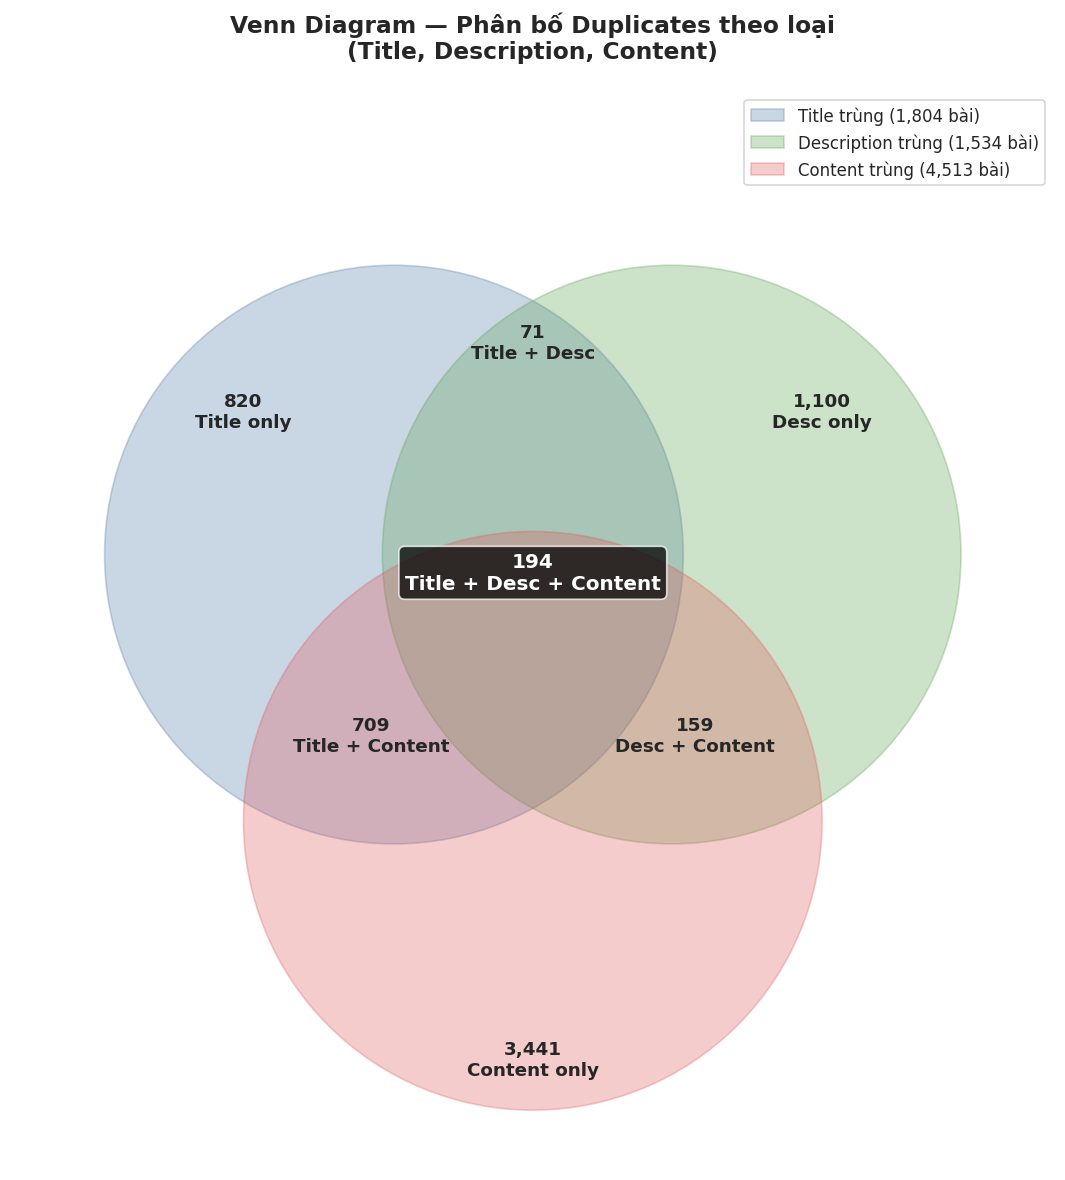

Chỉ Title trùng              : 820
Chỉ Description trùng        : 1,100
Chỉ Content trùng            : 3,441
Title + Description only     : 71
Title + Content only         : 709
Description + Content only   : 159
Trùng thật cả 3 field        : 194
Số bản ghi dư thừa cần drop  : 97


In [36]:
m_title = df_eda.duplicated(subset=['title'], keep=False)
m_desc = df_eda.duplicated(subset=['description'], keep=False)
m_content = df_eda.duplicated(subset=['content'], keep=False)


m_true_all3 = df_eda.duplicated(
    subset=['title', 'description', 'content'],
    keep=False
)

title_only = (m_title & ~m_desc & ~m_content).sum()
desc_only = (~m_title & m_desc & ~m_content).sum()
content_only = (~m_title & ~m_desc & m_content).sum()

title_desc_only = (m_title & m_desc & ~m_content).sum()
title_content_only = (m_title & ~m_desc & m_content).sum()
desc_content_only = (~m_title & m_desc & m_content).sum()

all3_true = m_true_all3.sum()

title_dup = m_title.sum()
desc_dup = m_desc.sum()
content_dup = m_content.sum()


fig, ax = plt.subplots(figsize=(12, 10))

circle1 = Circle((0.38, 0.55), 0.25, color='#4e79a7', alpha=0.3)
circle2 = Circle((0.62, 0.55), 0.25, color='#59a14f', alpha=0.3)
circle3 = Circle((0.50, 0.32), 0.25, color='#e15759', alpha=0.3)

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.text(0.25, 0.66, f'{title_only:,}\nTitle only',
        ha='center', fontsize=11, fontweight='bold')

ax.text(0.75, 0.66, f'{desc_only:,}\nDesc only',
        ha='center', fontsize=11, fontweight='bold')

ax.text(0.50, 0.10, f'{content_only:,}\nContent only',
        ha='center', fontsize=11, fontweight='bold')


ax.text(0.50, 0.72, f'{title_desc_only:,}\nTitle + Desc',
        ha='center', fontsize=11, fontweight='bold')

ax.text(0.36, 0.38, f'{title_content_only:,}\nTitle + Content',
        ha='center', fontsize=11, fontweight='bold')

ax.text(0.64, 0.38, f'{desc_content_only:,}\nDesc + Content',
        ha='center', fontsize=11, fontweight='bold')

ax.text(
    0.50, 0.52,
    f'{all3_true:,}\nTitle + Desc + Content',
    ha='center',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round', facecolor='black', alpha=0.75)
)


ax.set_xlim(0.05, 0.95)
ax.set_ylim(0.02, 0.95)
ax.set_aspect('equal')
ax.axis('off')

handles = [
    mpatches.Patch(color='#4e79a7', alpha=0.3, label=f'Title trùng ({title_dup:,} bài)'),
    mpatches.Patch(color='#59a14f', alpha=0.3, label=f'Description trùng ({desc_dup:,} bài)'),
    mpatches.Patch(color='#e15759', alpha=0.3, label=f'Content trùng ({content_dup:,} bài)')
]

ax.legend(handles=handles, loc='upper right', fontsize=10)

ax.set_title(
    'Venn Diagram — Phân bố Duplicates theo loại\n(Title, Description, Content)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()


print(f'Chỉ Title trùng              : {title_only:,}')
print(f'Chỉ Description trùng        : {desc_only:,}')
print(f'Chỉ Content trùng            : {content_only:,}')
print(f'Title + Description only     : {title_desc_only:,}')
print(f'Title + Content only         : {title_content_only:,}')
print(f'Description + Content only   : {desc_content_only:,}')
print(f'Trùng thật cả 3 field        : {all3_true:,}')
print(f'Số bản ghi dư thừa cần drop  : {df_eda.duplicated(subset=["title", "description", "content"], keep="first").sum():,}')

| Vùng                                  | Ý nghĩa                                                                            |
| ------------------------------------- | ---------------------------------------------------------------------------------- |
| `Chỉ Title trùng = 820`               | Những bài có title bị trùng, nhưng description và content không thuộc nhóm trùng   |
| `Chỉ Description trùng = 1,100`       | Những bài chỉ bị trùng description                                                 |
| `Chỉ Content trùng = 3,441`           | Những bài chỉ bị trùng content                                                     |
| `Title + Description only = 71`       | Những bài vừa có title trùng vừa có description trùng, nhưng content không trùng   |
| `Title + Content only = 709`          | Những bài vừa có title trùng vừa có content trùng, nhưng description không trùng   |
| `Description + Content only = 159`    | Những bài vừa có description trùng vừa có content trùng, nhưng title không trùng   |
| `Title + Description + Content = 194` | Những bài đồng thời thuộc cả 3 nhóm: title trùng, description trùng, content trùng |


In [37]:
# Lấy mẫu để kiểm tra trực tiếp các trường hợp duplicate
title_dup = df_eda[df_eda.duplicated(subset=['title'], keep=False)].copy()
desc_dup = df_eda[df_eda.duplicated(subset=['description'], keep=False)].copy()
full_dup = df_eda[df_eda.duplicated(subset=['title', 'description', 'content'], keep=False)].copy()

# 2 bài duplicate title cùng 1 nhóm
title_key = title_dup['title'].drop_duplicates().sample(1, random_state=42).iloc[0]
title_dup_sample = title_dup[title_dup['title'] == title_key].head(2)

# 2 bài duplicate description cùng 1 nhóm
desc_key = desc_dup['description'].drop_duplicates().sample(1, random_state=24).iloc[0]
desc_dup_sample = desc_dup[desc_dup['description'] == desc_key].head(2)

# 2 bài duplicate title + description + content cùng 1 nhóm
full_key = full_dup.drop_duplicates(subset=['title', 'description', 'content']).sample(1, random_state=101).iloc[0]
full_dup_sample = full_dup[
    (full_dup['title'] == full_key['title']) &
    (full_dup['description'] == full_key['description']) &
    (full_dup['content'] == full_key['content'])
].head(2)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print('=== Sample duplicate title ===')
print(f'Title group: {title_key!r}')
display(title_dup_sample[['source', 'title', 'description', 'content' ,'url', 'public_date']])


print('\n=== Sample duplicate description ===')
print(f'Description group: {desc_key!r}')
display(desc_dup_sample[['source', 'title', 'description', 'content', 'url', 'public_date']])

print('\n=== Sample duplicate title + description + content ===')
display(full_dup_sample[['source', 'title', 'description', 'content', 'url', 'public_date']])

=== Sample duplicate title ===
Title group: 'Lịch thi đấu bóng đá hôm nay 13/11'


,source,title,description,content,url,public_date
230523,VietnamNet,Lịch thi đấu bóng đá hôm nay 13/11,"Lịch thi đấu bóng đá hôm nay 13/11/2025 - Cung cấp lịch thi đấu bóng đá trong nước và quốc tế hấp dẫn đêm nay, rạng sáng mai.","Lịch thi đấu bóng đáhôm nay AFC Champions League Nữ 2025/26 Vòng loại World Cup 2026 – Khu vực Châu Á Vòng loại World Cup 2026 – Khu vực Châu Phi Vòng loại World Cup 2026 – Khu vực Châu Âu Vòng loại World Cup 2026 – Khu vực Bắc, Trung Mỹ & Caribbean 🤝Giao hữu Quốc tế",https://vietnamnet.vn/lich-thi-dau-bong-da-hom-nay-13-11-2462034.html,2025-11-13 07:30:00+07:00
234086,VietnamNet,Lịch thi đấu bóng đá hôm nay 13/11,"Lịch thi đấu bóng đá hôm nay 13/11/2024 - Cung cấp lịch thi đấu bóng đá trong nước và quốc tế hấp dẫn đêm nay, rạng sáng mai.",<NA>,https://vietnamnet.vn/lich-thi-dau-bong-da-hom-nay-13-11-2341297.html,2024-11-13 07:16:00+07:00



=== Sample duplicate description ===
Description group: 'Là sự kiện ấn tượng nằm trong chuỗi hoạt động kỷ niệm 70 năm Giải phóng Thủ đô, Giải Marathon Quốc tế Hà Nội Techcombank mùa 3 với “cung đường di sản” dự kiến thu hút số lượng người tham gia đông nhất từ trước đến nay.'


source  \
132146  Thanh Niên   
241728  VietnamNet   

                                                                                 title  \
132146  Những điều đáng mong đợi nhất ở giải Marathon Quốc tế Hà Nội Techcombank mùa 3   
241728      3 điều đáng mong đợi nhất ở giải Marathon Quốc tế Hà Nội Techcombank mùa 3   

                                                                                                                                                                                                                       description  \
132146  Là sự kiện ấn tượng nằm trong chuỗi hoạt động kỷ niệm 70 năm Giải phóng Thủ đô, Giải Marathon Quốc tế Hà Nội Techcombank mùa 3 với “cung đường di sản” dự kiến thu hút số lượng người tham gia đông nhất từ trước đến nay.   
241728  Là sự kiện ấn tượng nằm trong chuỗi hoạt động kỷ niệm 70 năm Giải phóng Thủ đô, Giải Marathon Quốc tế Hà Nội Techcombank mùa 3 với “cung đường di sản” dự kiến thu hút số lượng người tham gia đông nhất từ trước đến nay.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       


=== Sample duplicate title + description + content ===


source                                                       title  \
32603  Tuổi Trẻ  Thế giới thích ông Biden nhưng đã lên kịch bản 'Trump 2.0'   
36373  Tuổi Trẻ  Thế giới thích ông Biden nhưng đã lên kịch bản 'Trump 2.0'   

                                                                                                                                                   description  \
32603  Sau cuộc tranh luận tuần trước, các lãnh đạo thế giới chuẩn bị sẵn sàng cho nhiệm kỳ mới của ông Trump dù phần lớn ý kiến ngoài Mỹ thích ông Biden hơn.   
36373  Sau cuộc tranh luận tuần trước, các lãnh đạo thế giới chuẩn bị sẵn sàng cho nhiệm kỳ mới của ông Trump dù phần lớn ý kiến ngoài Mỹ thích ông Biden hơn.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

**Nhận xét Bảng Duplicates**

Dataset không có bản ghi trùng hoàn toàn, tức không tồn tại hai dòng giống nhau trên toàn bộ các cột. Tuy nhiên, sau khi chuẩn hóa URL, vẫn phát hiện 94 URL trùng nhau. Điều này cho thấy việc kiểm tra duplicate theo URL cần được thực hiện sau bước chuẩn hóa URL, đồng thời vẫn cần kiểm tra thêm các trường nội dung vì URL không phải lúc nào cũng phản ánh đầy đủ tình trạng trùng lặp thực sự của bài viết.

Đối với trường `title`, có 954 bản ghi dư thừa theo tiêu đề, tương ứng 1,804 bài nằm trong các nhóm có title trùng. Phần lớn các trường hợp này đến từ VietnamNet, chiếm 62.42%. Nguyên nhân có thể do một số chuyên mục định kỳ sử dụng tiêu đề giống hoặc gần giống nhau theo ngày, chẳng hạn như “Giá vàng hôm nay”, “Tỉ giá hôm nay”, “Lịch thi đấu bóng đá hôm nay”. Vì các bài này vẫn có thể khác nhau về `description`, `content`, URL hoặc thời điểm đăng, nên chưa thể xem là duplicate thực sự và không nên loại bỏ bản ghi chỉ dựa trên việc trùng `title`.

Đối với trường `description`, có 1,270 bản ghi dư thừa, tương ứng 1,534 bài nằm trong các nhóm có description trùng. Trong đó, Thanh Niên chiếm tỷ lệ cao nhất, khoảng 48.91%. Hiện tượng này có thể đến từ việc một số chuyên mục sử dụng mô tả ngắn hoặc mô tả theo dạng template. Do `description` thường ngắn và dễ bị lặp lại tự nhiên, việc trùng description chưa đủ cơ sở để kết luận các bản ghi là duplicate thực sự.

Đối với trường `content`, có 4,513 bài nằm trong các nhóm có content trùng, trong đó 4,119 bản ghi được xem là dư thừa nếu thực hiện collapse/deduplicate theo content và chỉ giữ lại một bản ghi đại diện cho mỗi nhóm. Đây là nhóm duplicate đáng chú ý nhất, trong đó VietnamNet chiếm 89.05%. Nguyên nhân có thể đến từ việc cùng một nội dung được đăng lại từ nguồn thông tấn, được phân phối ở nhiều chuyên mục khác nhau, hoặc crawler thu được nhiều phiên bản bài viết có URL khác nhau nhưng nội dung giống nhau.

Đối với bài toán phân loại chủ đề dựa trên tổ hợp `title + description + content`, trường `content` thường dài nhất và chiếm phần lớn tín hiệu văn bản. Do đó, nếu nhiều bản ghi có content giống nhau, biểu diễn đầu vào của các bài sẽ gần như tương đồng, dù title hoặc description có thể khác một phần nhỏ. Nếu giữ lại nhiều bản ghi có cùng content trong tập huấn luyện, mô hình có thể bị thiên lệch vì một số nội dung được lặp lại nhiều lần. Việc chia dữ liệu theo group split có thể giúp hạn chế data leakage giữa train và test, nhưng không giải quyết hoàn toàn vấn đề bias trong train set. Vì vậy, với nhóm content trùng, hướng xử lý phù hợp là cân nhắc deduplicate theo content, chỉ giữ một bản ghi đại diện cho mỗi nhóm content trùng.

Đối với trường hợp trùng đồng thời cả `title + description + content`, có 97 bản ghi dư thừa, tương ứng 194 bài nằm trong các nhóm trùng hoàn toàn theo ba trường văn bản. Đây là nhóm duplicate rõ ràng nhất và cần được xử lý trong bước làm sạch dữ liệu. Phần lớn các trường hợp này thuộc về Tuổi Trẻ, chiếm 96.91%. Nguyên nhân có thể do URL có thêm fragment, tham số phụ hoặc các biến thể khác khiến việc kiểm tra trùng lặp bằng URL đơn thuần không phát hiện được.

Tóm lại, ở bước làm sạch dữ liệu, không nên loại bỏ bản ghi chỉ vì trùng `title` hoặc trùng `description`, vì hai trường này ngắn và có thể lặp lại tự nhiên theo dạng bài định kỳ hoặc template. Tuy nhiên, đối với các nhóm trùng `content`, nên cân nhắc deduplicate theo content để giảm lặp nội dung và hạn chế bias trong quá trình huấn luyện. Nếu thực hiện deduplicate theo `content`, số bản ghi dư thừa cần loại bỏ là 4,119 dòng, chiếm khoảng 1.51% tổng số 273,058 bản ghi. Ngoài ra, các trường hợp trùng đồng thời `title + description + content` với 97 bản ghi dư thừa nên được ưu tiên xử lý vì đây là nhóm duplicate có độ chắc chắn cao nhất.


### 5.2. Kiểm tra chồng chéo nhãn

In [38]:
# =========================
# Kiểm tra nhãn chồng chéo / label conflict
# Cùng title + description + content nhưng khác category
# =========================

text_cols = ['title', 'description', 'content']
label_col = 'category'

tdc_dup = df_eda[df_eda.duplicated(subset=text_cols, keep=False)].copy()

label_conflict_check = (
    tdc_dup
    .groupby(text_cols, dropna=False)
    .agg(
        n_rows=(label_col, 'size'),
        n_unique_category=(label_col, 'nunique'),
        categories=(label_col, lambda x: sorted(x.dropna().unique()))
    )
    .reset_index()
)

label_conflict_groups = label_conflict_check[
    label_conflict_check['n_unique_category'] > 1
].copy()

print(f'Số nhóm trùng title + description + content nhưng khác category: {len(label_conflict_groups):,}')
print(f'Số bản ghi nằm trong các nhóm conflict: {label_conflict_groups["n_rows"].sum():,}')

label_conflict_groups.head()

Số nhóm trùng title + description + content nhưng khác category: 15
Số bản ghi nằm trong các nhóm conflict: 30


title  \
8   Bầu cử Mỹ và sự ồn ào của những người nổi tiếng khi công khai ủng hộ ông Trump hay bà Harris   
18            Ca khúc Freedom của Beyoncé được sử dụng để vận động tranh cử cho bà Kamala Harris   
19         Cardi B và sao Hollywood phản ứng trước chiến thắng của ông Trump: 'Tạm biệt nước Mỹ'   
27                                                   Facebook dỡ hạn chế tài khoản cho ông Trump   
34                                  Liệu Taylor Swift có giành chiến thắng cho bà Kamala Harris?   

                                                                                                                                                                                                            description  \
8                                               Trước đây, các ngôi sao thường tỏ ra kín tiếng mỗi khi kỳ bầu cử Mỹ tới gần dù vị thế của họ trong ngành giải trí có lớn như thế nào, thời đó giờ đã trở thành dĩ vãng.   
18                                                   Phó tổng thống Kamala Harris đã có màn ra mắt ấn tượng tại trụ sở chiến dịch tranh cử tổng thống của bà ở Wilmington, khi bước ra với ca khúc Freedom của Beyoncé.   
19                                                           Cardi B, Ariana Grande và nhiều sao Hollywood bày tỏ phản ứng về tin ông Trump tái đắc cử, Billie Eilish gọi chiến thắng là 'Cuộc chiến chống lại phụ nữ'.   
27                                                                      Trước Đại hội toàn quốc Đảng Cộng hòa, Meta thông báo sẽ dỡ bỏ các hạn chế với tài khoản Facebook và Instagram của cựu tổng thống Donald Trump.   
34  Taylor Swift, một trong những biểu tượng văn hóa đại chúng nổi tiếng nhất nước Mỹ và ước tính có đến hàng tỉ fan trên toàn thế giới vừa lên tiếng ủng hộ Phó tổng thống Kamala Harris trong cuộc đua vào Nhà Trắng.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [39]:
# Lấy ra toàn bộ dòng thuộc các nhóm bị conflict category
conflict_rows = tdc_dup.merge(
    label_conflict_groups[text_cols],
    on=text_cols,
    how='inner'
)

# Sắp xếp để dễ quan sát
conflict_rows = conflict_rows.sort_values(
    by=text_cols + [label_col]
)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

display(
    conflict_rows[
    ['source', 'category', 'title', 'description', 'content', 'url', 'public_date']
    ].head(20)
)

source            category  \
7   Tuổi Trẻ            Giải trí   
16  Tuổi Trẻ            Thế giới   
2   Tuổi Trẻ            Giải trí   
25  Tuổi Trẻ            Thế giới   
5   Tuổi Trẻ            Giải trí   
13  Tuổi Trẻ            Thế giới   
9   Tuổi Trẻ  Khoa học công nghệ   
26  Tuổi Trẻ            Thế giới   
0   Tuổi Trẻ            Giải trí   
20  Tuổi Trẻ            Thế giới   
11  Tuổi Trẻ          Kinh doanh   
21  Tuổi Trẻ            Thế giới   
24  Tuổi Trẻ            Thế giới   
29  Tuổi Trẻ                  Xe   
6   Tuổi Trẻ            Giải trí   
15  Tuổi Trẻ            Thế giới   
4   Tuổi Trẻ            Giải trí   
23  Tuổi Trẻ            Thế giới   
14  Tuổi Trẻ            Thế giới   
28  Tuổi Trẻ            Thể thao   

                                                                                           title  \
7   Bầu cử Mỹ và sự ồn ào của những người nổi tiếng khi công khai ủng hộ ông Trump hay bà Harris   
16  Bầu cử Mỹ và sự ồn ào của những người nổi tiếng khi công khai ủng hộ ông Trump hay bà Harris   
2             Ca khúc Freedom của Beyoncé được sử dụng để vận động tranh cử cho bà Kamala Harris   
25            Ca khúc Freedom của Beyoncé được sử dụng để vận động tranh cử cho bà Kamala Harris   
5          Cardi B và sao Hollywood phản ứng trước chiến thắng của ông Trump: 'Tạm biệt nước Mỹ'   
13         Cardi B và sao Hollywood phản ứng trước chiến thắng của ông Trump: 'Tạm biệt nước Mỹ'   
9                                                    Facebook dỡ hạn chế tài khoản cho ông Trump   
26                                                   Facebook dỡ hạn chế tài khoản cho ông Trump   
0                                   Liệu Taylor Swift có giành chiến thắng cho bà Kamala Harris?   
20                                  Liệu Taylor Swift có giành chiến thắng cho bà Kamala Harris?   
11                       Mỹ sẽ có lãnh đạo mới, tác động kinh tế đến Việt Nam liệu có khác biệt?   
21                       Mỹ sẽ có lãnh đạo mới, tác động kinh tế đến Việt Nam liệu có khác biệt?   
24              Nghiệp đoàn ô tô Mỹ kiện ông Trump và tỉ phú Elon Musk sau buổi phỏng vấn trên X   
29              Nghiệp đoàn ô tô Mỹ kiện ông Trump và tỉ phú Elon Musk sau buổi phỏng vấn trên X   
6            Người ủng hộ ông Trump ăn mừng náo nhiệt trên X, các siêu sao phe bà Harris im lặng   
15           Người ủng hộ ông Trump ăn mừng náo nhiệt trên X, các siêu sao phe bà Harris im lặng   
4                                                  Những phim xuất sắc nhất để xem mùa bầu cử Mỹ   
23                                                 Những phim xuất sắc nhất để xem mùa bầu cử Mỹ   
14                      Phó tổng thống Mỹ Kamala Harris: Tập thể dục hằng ngày, ăn nhiều chất xơ   
28                      Phó tổng thống Mỹ Kamala Harris: Tập thể dục hằng ngày, ăn nhiều chất xơ   

                                                                                                                                                                                                               description  \
7                                                  Trước đây, các ngôi sao thường tỏ ra kín tiếng mỗi khi kỳ bầu cử Mỹ tới gần dù vị thế của họ trong ngành giải trí có lớn như thế nào, thời đó giờ đã trở thành dĩ vãng.   
16                                                 Trước đây, các ngôi sao thường tỏ ra kín tiếng mỗi khi kỳ bầu cử Mỹ tới gần dù vị thế của họ trong ngành giải trí có lớn như thế nào, thời đó giờ đã trở thành dĩ vãng.   
2                                                       Phó tổng thống Kamala Harris đã có màn ra mắt ấn tượng tại trụ sở chiến dịch tranh cử tổng thống của bà ở Wilmington, khi bước ra với ca khúc Freedom của Beyoncé.   
25                                                      Phó tổng thống Kamala Harris đã có màn ra mắt ấn tượng tại trụ sở chiến dịch tranh cử tổng thống của bà ở Wilmington, khi bước ra với ca khúc Freedom của Beyoncé.   
5                                     

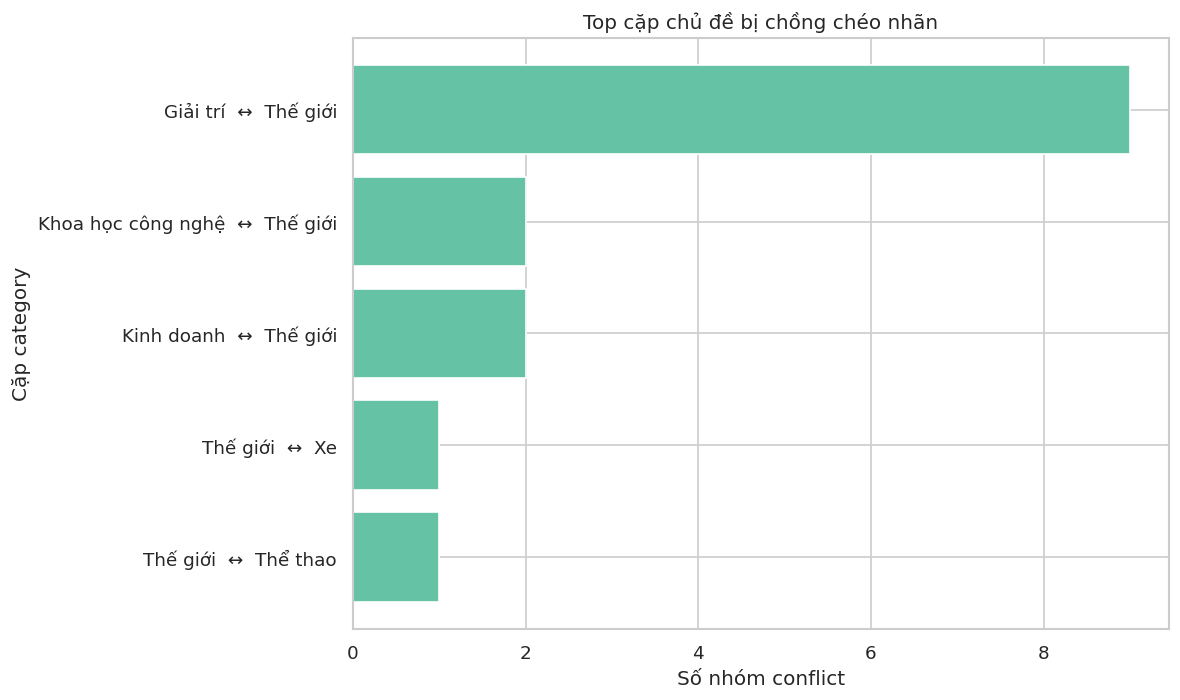

In [40]:
text_cols = ['title', 'description', 'content']
label_col = 'category'

# Lấy các dòng trùng đúng bộ ba text
tdc_dup = df_eda[df_eda.duplicated(subset=text_cols, keep=False)].copy()

# Gán group_id cho mỗi nhóm có cùng title+description+content
tdc_dup['group_id'] = tdc_dup.groupby(text_cols, dropna=False).ngroup()

# Chỉ giữ các nhóm có nhiều hơn 1 category
conflict_group_ids = (
    tdc_dup.groupby('group_id')[label_col]
    .nunique()
    .loc[lambda x: x > 1]
    .index
)

conflict_rows = tdc_dup[tdc_dup['group_id'].isin(conflict_group_ids)].copy()

# Với mỗi group conflict, lấy tập category duy nhất
group_categories = (
    conflict_rows.groupby('group_id')[label_col]
    .apply(lambda x: sorted(set(x.dropna())))
)

# Tạo danh sách các cặp category bị conflict
pair_list = []
for group_id, cats in group_categories.items():
    if len(cats) >= 2:
        for pair in combinations(cats, 2):
            pair_list.append((group_id, pair[0], pair[1]))

pair_df = pd.DataFrame(pair_list, columns=['group_id', 'cat1', 'cat2'])

# Đếm số nhóm conflict cho từng cặp category
pair_count = (
    pair_df.groupby(['cat1', 'cat2'])
    .size()
    .reset_index(name='n_groups')
    .sort_values('n_groups', ascending=False)
)

pair_count.head(20)

# Tạo nhãn cho cặp category
pair_count['pair_label'] = pair_count['cat1'] + '  ↔  ' + pair_count['cat2']

top_n = min(15, len(pair_count))
plot_df = pair_count.head(top_n).sort_values('n_groups', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['pair_label'], plot_df['n_groups'])
plt.xlabel('Số nhóm conflict')
plt.ylabel('Cặp category')
plt.title('Top cặp chủ đề bị chồng chéo nhãn')
plt.tight_layout()
plt.show()

Nhóm thực hiện kiểm tra hiện tượng chồng chéo nhãn bằng cách tìm các bản ghi có cùng title, description và content nhưng lại mang category khác nhau. Kết quả phát hiện 15 nhóm conflict, tương ứng 30 bản ghi. Heatmap và biểu đồ cặp category cho thấy các lỗi gán nhãn không phân bố đều mà tập trung vào một số cặp chủ đề nhất định, phản ánh sự gần nghĩa giữa các nhóm tin tức hoặc lỗi gán nhãn trong quá trình crawl. Các nhóm này cần được tách riêng để xử lý, vì cùng một đầu vào văn bản nhưng lại có nhiều nhãn khác nhau sẽ gây nhiễu cho bài toán phân loại. Có thể loại bỏ toàn bộ nhóm conflict hoặc chọn nhãn theo một quy tắc nhất quán, nhưng không nên giữ nguyên trong tập huấn luyện.

## 6. Phân tích độ dài văn bản thô (Raw Text Length)

### 6.1. Phân tích độ dài Title, Description và Content

> Phát hiện bài crawl lỗi hoặc thiếu nội dung, xác định ngưỡng lọc hợp lý và hiểu mức đóng góp của từng trường văn bản trong input baseline.

=== THỐNG KÊ ĐỘ DÀI VĂN BẢN ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Độ dài title (từ),273058.00,14.00,3.10,0.00,6.00,9.00,12.00,14.00,16.00,19.00,21.00,30.00
Độ dài description (từ),273058.00,36.60,10.40,0.00,18.00,22.00,29.00,35.00,43.00,54.00,70.00,171.00
Độ dài content (từ),273058.00,668.40,408.50,0.00,5.00,203.00,410.00,598.00,850.00,1368.00,1888.00,36148.00
Độ dài full text: title + description + content (từ),273058.00,719.00,412.00,4.00,49.00,248.00,457.00,649.00,904.00,1425.00,1945.00,36198.00



=== NGƯỠNG TỰ ĐỘNG THEO PHÂN VỊ ===


,P01,P05,P95,P99
Title,6.00,9.00,19.00,21.00
Description,18.00,22.00,54.00,70.00
Content,5.00,203.00,1368.00,1888.00
Full text,49.00,248.00,1425.00,1945.00



=== KIỂM TRA BẤT THƯỜNG THEO NGƯỠNG TỰ ĐỘNG ===
Title:
  Rất ngắn <= P01 (6 từ): 3,022 bài (1.11%)
  Rất dài  >= P99 (21 từ): 3,110 bài (1.14%)
Description:
  Rất ngắn <= P01 (18 từ): 3,278 bài (1.20%)
  Rất dài  >= P99 (70 từ): 2,824 bài (1.03%)
Content:
  Rất ngắn <= P01 (5 từ): 2,812 bài (1.03%)
  Rất dài  >= P99 (1888 từ): 2,735 bài (1.00%)
Full text:
  Rất ngắn <= P01 (49 từ): 2,796 bài (1.02%)
  Rất dài  >= P99 (1945 từ): 2,733 bài (1.00%)


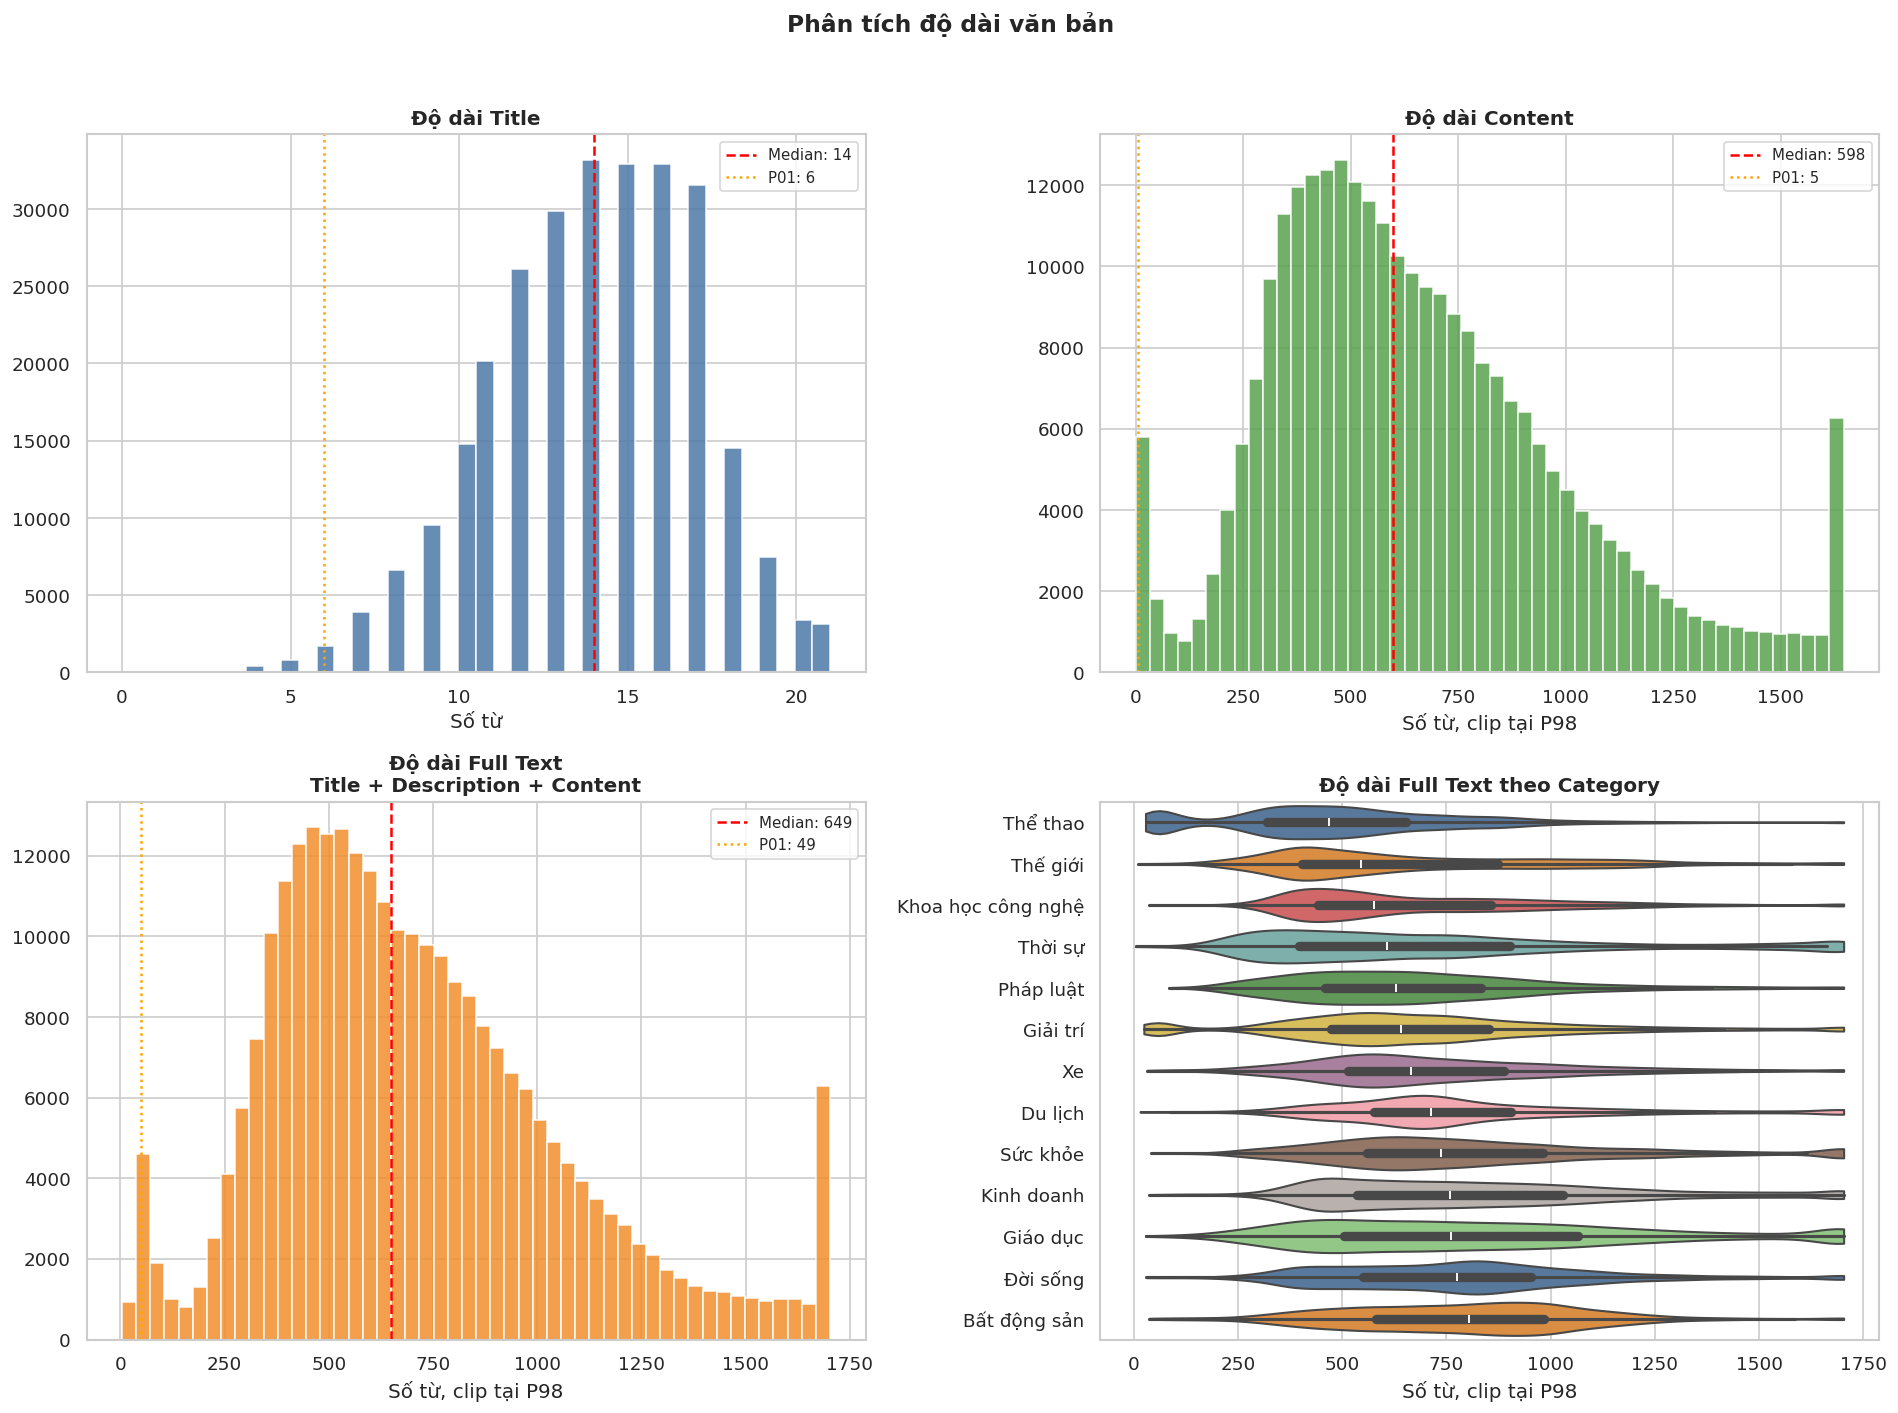

In [41]:
df_eda['title_wc'] = df_eda['title'].fillna('').astype(str).apply(lambda x: len(x.split()))

df_eda['description_wc'] = df_eda['description'].fillna('').astype(str).apply(lambda x: len(x.split()))

df_eda['content_wc'] = df_eda['content'].fillna('').astype(str).apply(lambda x: len(x.split()))

# Gộp title + description + content
df_eda['full_text'] = (
    df_eda['title'].fillna('').astype(str) + ' ' +
    df_eda['description'].fillna('').astype(str) + ' ' +
    df_eda['content'].fillna('').astype(str)
).str.strip()

df_eda['full_text_wc'] = df_eda['full_text'].apply(lambda x: len(x.split()))

stats_cols = [
    'title_wc',
    'description_wc',
    'content_wc',
    'full_text_wc'
]

desc = df_eda[stats_cols].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).T

desc.index = [
    'Độ dài title (từ)',
    'Độ dài description (từ)',
    'Độ dài content (từ)',
    'Độ dài full text: title + description + content (từ)'
]

print('=== THỐNG KÊ ĐỘ DÀI VĂN BẢN ===')
display(desc.round(1))

auto_thresholds = {}

for col in stats_cols:
    p01 = df_eda[col].quantile(0.01)
    p05 = df_eda[col].quantile(0.05)
    p95 = df_eda[col].quantile(0.95)
    p99 = df_eda[col].quantile(0.99)

    auto_thresholds[col] = {
        'P01': p01,
        'P05': p05,
        'P95': p95,
        'P99': p99
    }

threshold_df = pd.DataFrame(auto_thresholds).T
threshold_df.index = [
    'Title',
    'Description',
    'Content',
    'Full text'
]

print('\n=== NGƯỠNG TỰ ĐỘNG THEO PHÂN VỊ ===')
display(threshold_df.round(1))

print('\n=== KIỂM TRA BẤT THƯỜNG THEO NGƯỠNG TỰ ĐỘNG ===')

for col, name in zip(
    stats_cols,
    ['Title', 'Description', 'Content', 'Full text']
):
    low_thres = df_eda[col].quantile(0.01)
    high_thres = df_eda[col].quantile(0.99)

    n_short = (df_eda[col] <= low_thres).sum()
    n_long = (df_eda[col] >= high_thres).sum()

    print(f'{name}:')
    print(f'  Rất ngắn <= P01 ({low_thres:.0f} từ): {n_short:,} bài ({n_short / len(df_eda) * 100:.2f}%)')
    print(f'  Rất dài  >= P99 ({high_thres:.0f} từ): {n_long:,} bài ({n_long / len(df_eda) * 100:.2f}%)')

if 'COLORS' not in globals():
    COLORS = cm.tab20(np.linspace(0, 1, df_eda['category'].nunique()))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

data_title = df_eda['title_wc'].dropna()
p01_title = data_title.quantile(0.01)
p99_title = data_title.quantile(0.99)

axes[0].hist(
    data_title.clip(upper=p99_title),
    bins=40,
    color='#4e79a7',
    edgecolor='white',
    alpha=0.85
)

axes[0].axvline(
    data_title.median(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Median: {data_title.median():.0f}"
)

axes[0].axvline(
    p01_title,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label=f'P01: {p01_title:.0f}'
)

axes[0].set_xlabel('Số từ')
axes[0].set_title('Độ dài Title', fontweight='bold')
axes[0].legend(fontsize=9)


data_content = df_eda['content_wc'].dropna()
p01_content = data_content.quantile(0.01)
p98_content = data_content.quantile(0.98)

axes[1].hist(
    data_content.clip(upper=p98_content),
    bins=50,
    color='#59a14f',
    edgecolor='white',
    alpha=0.85
)

axes[1].axvline(
    data_content.median(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Median: {data_content.median():.0f}"
)

axes[1].axvline(
    p01_content,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label=f'P01: {p01_content:.0f}'
)

axes[1].set_xlabel('Số từ, clip tại P98')
axes[1].set_title('Độ dài Content', fontweight='bold')
axes[1].legend(fontsize=9)


data_full = df_eda['full_text_wc'].dropna()
p01_full = data_full.quantile(0.01)
p98_full = data_full.quantile(0.98)

axes[2].hist(
    data_full.clip(upper=p98_full),
    bins=50,
    color='#f28e2b',
    edgecolor='white',
    alpha=0.85
)

axes[2].axvline(
    data_full.median(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Median: {data_full.median():.0f}"
)

axes[2].axvline(
    p01_full,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label=f'P01: {p01_full:.0f}'
)

axes[2].set_xlabel('Số từ, clip tại P98')
axes[2].set_title('Độ dài Full Text\nTitle + Description + Content', fontweight='bold')
axes[2].legend(fontsize=9)


cat_order = (
    df_eda.groupby('category')['full_text_wc']
    .median()
    .sort_values()
    .index
    .tolist()
)

plot_df = df_eda.copy()
plot_df['full_text_wc_clip'] = plot_df['full_text_wc'].clip(
    upper=plot_df['full_text_wc'].quantile(0.98)
)

sns.violinplot(
    data=plot_df,
    x='full_text_wc_clip',
    y='category',
    order=cat_order,
    palette=COLORS[:len(cat_order)],
    ax=axes[3],
    inner='box',
    cut=0
)

axes[3].set_xlabel('Số từ, clip tại P98')
axes[3].set_ylabel('')
axes[3].set_title('Độ dài Full Text theo Category', fontweight='bold')

plt.suptitle(
    'Phân tích độ dài văn bản',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Nhận xét Phân tích độ dài văn bản**

Title: Độ dài tiêu đề có phân phối rất ổn định, mean và median đều khoảng 14 từ, độ lệch chuẩn chỉ 3.1. Phần lớn title nằm trong khoảng 9–19 từ ở vùng 5%–95%, cho thấy tiêu đề báo chí trong dataset khá nhất quán và không có biến động lớn. Một số title rất ngắn ở ngưỡng P01 khoảng 6 từ và title dài ở P99 khoảng 21 từ, nhưng tỉ lệ chỉ quanh 1%, nên không phải vấn đề nghiêm trọng.

Description: Description có median khoảng 35 từ, mean khoảng 36.6 từ, phân phối khá cân bằng. Khoảng 90% description nằm từ 22 đến 54 từ, cho thấy phần mô tả được crawl khá đầy đủ và nhất quán. Một số description dài tới 171 từ, nhưng vì P99 chỉ khoảng 70 từ, các trường hợp quá dài có thể là ngoại lệ cần kiểm tra thêm.

Content: Content có phân phối lệch phải rõ rệt. Median là 598 từ, mean là 668.4 từ, cao hơn median, chứng tỏ có một số bài rất dài kéo trung bình lên. Đặc biệt max lên tới 36,148 từ, trong khi P99 chỉ 1,888 từ, đây là outlier cực mạnh. Các bài rất dài có thể là bài tổng hợp/phân tích dài, nhưng cũng có khả năng là lỗi crawl dính nhiều nội dung không thuộc bài viết.

Full text = title + description + content: Đây là độ dài quan trọng nhất cho baseline chính, vì baseline phân loại category được định nghĩa dựa trên ba trường văn bản này. Full text có median 649 từ, mean 719 từ, và 95% bài nằm dưới khoảng 1,425 từ. Điều này cho thấy phần lớn văn bản đầu vào có độ dài vừa phải, phù hợp cho các mô hình ML truyền thống như TF-IDF, Naive Bayes, SVM, Logistic Regression hoặc Random Forest. Tuy nhiên, max vẫn lên tới 36,198 từ, cho thấy outlier chủ yếu đến từ cột content.

Khi dùng P01 và P99, mỗi nhóm bất thường chiếm khoảng 1% dữ liệu. Cụ thể, có 2,796 bài có full text ≤ 49 từ và 2,733 bài có full text ≥ 1,945 từ. Nhóm full text quá ngắn đáng chú ý hơn vì bài báo mà tổng cả title, description và content chỉ dưới 49 từ có thể là bài crawl thiếu nội dung, bài video/ảnh, hoặc lỗi trích xuất.

Violin plot theo category: Độ dài full text giữa các category có sự khác biệt nhất định, nhưng không quá cực đoan. Một số nhóm như Thể thao, Thế giới, Khoa học công nghệ, Thời sự có đuôi phải dài hơn, cho thấy có nhiều bài phân tích hoặc bài tường thuật dài. Trong khi đó, một số nhóm như Bất động sản, Đời sống, Xe có phân phối tập trung hơn.

Drop tự động:
- full_text_wc <= P01, tức khoảng <= 49 từ

Kiểm tra thủ công:
- full_text_wc >= P99, tức khoảng >= 1,945 từ

In [42]:
df_outliers = df_eda[df_eda['full_text_wc'] >= 1945]

print(f"Tổng số bài thuộc nhóm outlier (>= 1945 từ): {len(df_outliers):,} bài")

# Lấy ngẫu nhiên 20 bài
df_random_sample = df_outliers.sample(n=20, random_state=42)

print(f"\n=== ĐANG HIỂN THỊ 20 BÀI NGẪU NHIÊN ĐỂ KIỂM TRA ===")
for idx, row in df_random_sample.iterrows():
    print("-" * 80)
    source_info = row['source'] if 'source' in df_eda.columns else 'N/A'
    url_info = row['url'] if 'url' in df_eda.columns else 'N/A'
    
    print(f"[ID]: {idx} | [Nguồn]: {source_info} | [Chủ đề]: {row['category']}")
    print(f"[Số từ]: {row['full_text_wc']} từ")
    print(f"[Tiêu đề]: {row['title']}")
    print(f"[URL]: {url_info}")
    print(f"[Mô tả]: {row['description']}")
    print(f"[NỘI DUNG NGUYÊN VĂN BÀI BÁO]:\n{row['content']}")
    print("-" * 80)

Tổng số bài thuộc nhóm outlier (>= 1945 từ): 2,733 bài

=== ĐANG HIỂN THỊ 20 BÀI NGẪU NHIÊN ĐỂ KIỂM TRA ===
--------------------------------------------------------------------------------
[ID]: 105972 | [Nguồn]: Thanh Niên | [Chủ đề]: Kinh doanh
[Số từ]: 2488 từ
[Tiêu đề]: Hồi sinh đô thị sông nước
[URL]: https://thanhnien.vn/hoi-sinh-do-thi-song-nuoc-185250920225048514.htm
[Mô tả]: Ghe thuyền chật sông, ngày đêm đi lại không ngớt - ký ức của người Sài Gòn hàng trăm năm trước đã gắn liền với thuyền bè sông nước, nơi những bến đò ngang xuôi ngược tấp nập sáng đêm.
[NỘI DUNG NGUYÊN VĂN BÀI BÁO]:
Dần dà, đô thị phát triển, đường nối cầu, cầu nối sông, những tuyến đò ngang chỉ còn lại trong hoài niệm. Song, vẫn còn một hồn đô thị sông nước đang chờ được hồi sinh giữa thành phố hoa lệ. Đường thủy đóng vai trò quan trọng đối với giao thông TP.HCM. Trong ảnh : bến phà Cát Lái, TP.HCM ẢNH: NGỌC DƯƠNG Mòn mỏi chờ bến phà xưa Gần 1 tháng qua kể từ khi cầu Bình Triệu 1 điều chỉnh lưu thông để ph

### 6.2. Kết luận sau khi kiểm tra thủ công nhóm Outlier độ dài

Qua việc lấy mẫu ngẫu nhiên và kiểm tra trực tiếp các bài có độ dài bất thường (`full_text_wc >= 1,945 từ`), có thể thấy rằng phần lớn các bài thuộc nhóm này **không phải dữ liệu lỗi**. Nhiều bài là các bài Longform, bài phân tích chuyên sâu, bài tổng hợp sự kiện, bài tư vấn hoặc bài có nhiều tiểu mục. Các văn bản này vẫn có cấu trúc rõ ràng, nội dung đầy đủ và mang tín hiệu chủ đề rất tốt cho bài toán phân loại. Vì vậy, việc loại bỏ tự động toàn bộ nhóm bài dài theo ngưỡng P99 là không phù hợp, vì có thể làm mất nhiều bài viết hợp lệ và giàu ngữ cảnh. 

Tuy nhiên, quá trình kiểm tra thủ công cũng cho thấy trong một số bài dài có xuất hiện các thành phần nhiễu do quá trình thu thập dữ liệu, chẳng hạn như chú thích ảnh dạng `ẢNH:`, `Ảnh:`, tên tác giả ảnh, URL nhúng trong nội dung, text điều hướng như `Play`, `Mute`, `Next`, banner/quảng cáo hoặc các dòng dẫn sang bài khác như `Xem chi tiết...`. Các thành phần này không làm bản ghi trở thành dữ liệu sai, nhưng có thể làm tăng độ dài văn bản không cần thiết và gây nhiễu khi tạo đặc trưng đầu vào cho mô hình.

Do đó, hướng xử lý được chốt là **không drop tự động các bài có `full_text_wc >= 1,945`**. Thay vào đó, ở bước tiền xử lý văn bản, cần bổ sung các thao tác làm sạch bằng regex để loại bỏ các thành phần nhiễu như URL, chú thích ảnh, text điều hướng video, dòng quảng cáo và các đoạn điều hướng không thuộc nội dung chính của bài báo. Sau bước này, văn bản đầu vào sẽ phản ánh tốt hơn nội dung cốt lõi của bài viết, trong khi vẫn giữ lại các bài Longform hợp lệ.

**Kết luận:** Nhóm bài quá dài nhìn chung vẫn là dữ liệu hợp lệ nên được giữ lại. Tuy nhiên, kết quả kiểm tra thủ công cho thấy cần bổ sung bước làm sạch chuyên sâu ở phần chuẩn hóa văn bản, tập trung vào việc loại bỏ URL, chú thích ảnh, text điều hướng, banner/quảng cáo và các dòng nhiễu do crawling. Ngược lại, các bài quá ngắn mới là nhóm có rủi ro thiếu nội dung cao hơn và phù hợp để loại bỏ tự động theo ngưỡng đã xác định trong EDA.


## 7. Phân tích đặc trưng ngôn ngữ thô

### 7.1. Kiểm tra các icon/ký tự đặc biệt

In [55]:
df_icon = df_eda.copy() if 'df_eda' in globals() else df.copy()

text_cols = ['title', 'description', 'content']
text_cols = [col for col in text_cols if col in df_icon.columns]

def get_unicode_block(char):
    code = ord(char)

    blocks = [
        (0x2190, 0x21FF, 'Arrows'),
        (0x2300, 0x23FF, 'Miscellaneous Technical'),
        (0x2460, 0x24FF, 'Enclosed Alphanumerics'),
        (0x2500, 0x257F, 'Box Drawing'),
        (0x2580, 0x259F, 'Block Elements'),
        (0x25A0, 0x25FF, 'Geometric Shapes'),
        (0x2600, 0x26FF, 'Miscellaneous Symbols'),
        (0x2700, 0x27BF, 'Dingbats'),
        (0x2900, 0x297F, 'Supplemental Arrows-B'),
        (0x2B00, 0x2BFF, 'Miscellaneous Symbols and Arrows'),
        (0x1F000, 0x1F02F, 'Mahjong Tiles'),
        (0x1F030, 0x1F09F, 'Domino Tiles'),
        (0x1F100, 0x1F1FF, 'Enclosed Alphanumeric Supplement'),
        (0x1F200, 0x1F2FF, 'Enclosed Ideographic Supplement'),
        (0x1F300, 0x1F5FF, 'Miscellaneous Symbols and Pictographs'),
        (0x1F600, 0x1F64F, 'Emoticons'),
        (0x1F680, 0x1F6FF, 'Transport and Map Symbols'),
        (0x1F700, 0x1F77F, 'Alchemical Symbols'),
        (0x1F780, 0x1F7FF, 'Geometric Shapes Extended'),
        (0x1F800, 0x1F8FF, 'Supplemental Arrows-C'),
        (0x1F900, 0x1F9FF, 'Supplemental Symbols and Pictographs'),
        (0x1FA00, 0x1FA6F, 'Chess Symbols'),
        (0x1FA70, 0x1FAFF, 'Symbols and Pictographs Extended-A'),
        (0xFE00, 0xFE0F, 'Variation Selectors'),
        (0x200D, 0x200D, 'Zero Width Joiner')
    ]

    for start, end, block_name in blocks:
        if start <= code <= end:
            return block_name

    return 'Other'


def is_icon_like_char(char):
    category = unicodedata.category(char)
    block = get_unicode_block(char)

    if category in ['So', 'Sk']:
        return True

    if block in [
        'Arrows',
        'Miscellaneous Technical',
        'Enclosed Alphanumerics',
        'Box Drawing',
        'Block Elements',
        'Geometric Shapes',
        'Miscellaneous Symbols',
        'Dingbats',
        'Supplemental Arrows-B',
        'Miscellaneous Symbols and Arrows',
        'Mahjong Tiles',
        'Domino Tiles',
        'Enclosed Alphanumeric Supplement',
        'Enclosed Ideographic Supplement',
        'Miscellaneous Symbols and Pictographs',
        'Emoticons',
        'Transport and Map Symbols',
        'Alchemical Symbols',
        'Geometric Shapes Extended',
        'Supplemental Arrows-C',
        'Supplemental Symbols and Pictographs',
        'Chess Symbols',
        'Symbols and Pictographs Extended-A'
    ]:
        return True

    return False


def extract_icon_like_chars(text):
    if pd.isna(text):
        return []

    text = str(text)
    return [char for char in text if is_icon_like_char(char)]


icon_summary = []

for col in text_cols:
    s = df_icon[col].fillna('').astype(str)
    icons_per_row = s.apply(extract_icon_like_chars)

    icon_summary.append({
        'column': col,
        'rows_contain_icon_like_char': (icons_per_row.apply(len) > 0).sum(),
        'rate_percent': round((icons_per_row.apply(len) > 0).mean() * 100, 4),
        'total_icon_like_count': icons_per_row.apply(len).sum(),
        'unique_icon_like_count': len(set([icon for icons in icons_per_row for icon in icons]))
    })

icon_summary_df = pd.DataFrame(icon_summary)
icon_summary_df

,column,rows_contain_icon_like_char,rate_percent,total_icon_like_count,unique_icon_like_count
0,title,30,0.01,30,3
1,description,139,0.05,159,4
2,content,2061,0.75,6904,99


In [56]:
all_icon_chars = []

for col in text_cols:
    s = df_icon[col].fillna('').astype(str)
    icons_per_row = s.apply(extract_icon_like_chars)
    all_icon_chars.extend([icon for icons in icons_per_row for icon in icons])

icon_freq_df = (
    pd.DataFrame(Counter(all_icon_chars).items(), columns=['icon', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

icon_freq_df['unicode_name'] = icon_freq_df['icon'].apply(
    lambda x: unicodedata.name(x, 'UNKNOWN')
)

icon_freq_df['unicode_category'] = icon_freq_df['icon'].apply(
    lambda x: unicodedata.category(x)
)

icon_freq_df['unicode_block'] = icon_freq_df['icon'].apply(get_unicode_block)

icon_freq_df.head(100)

,icon,count,unicode_name,unicode_category,unicode_block
0,™,1764,TRADE MARK SIGN,So,Other
1,→,1647,RIGHTWARDS ARROW,Sm,Arrows
2,°,1175,DEGREE SIGN,So,Other
3,®,802,REGISTERED SIGN,So,Other
4,●,758,BLACK CIRCLE,So,Geometric Shapes
...,...,...,...,...,...
95,🌟,1,GLOWING STAR,So,Miscellaneous Symbols and Pictographs
96,👑,1,CROWN,So,Miscellaneous Symbols and Pictographs
97,🥇,1,FIRST PLACE MEDAL,So,Supplemental Symbols and Pictographs
98,☰,1,TRIGRAM FOR HEAVEN,So,Miscellaneous Symbols


In [57]:
print(' '.join(icon_freq_df['icon'].astype(str).tolist()))

™ → ° ® ● ■ ˚ ` 🡪 ▪ ➢ 🏆 ◊ ✅ ☎ 🌐 📍 ♦ ✔ 🔥 🎥 ℃ 📌 ⚡ ^ 🔹 📺 🗓 ↑ 🎁 ⚽ ▶ ○ 📅 ❖ © 🏟 ´ ㎡ ℅ 📞 🔍 🔴 ✓ ➡ ⏰ 👉 ❌ 🏐 🎯 🥉 🤝 ⚔ 🔑 🔮 🕘 🕒 🔻 ► 📩 � ☑ 🏘 ❤ 📧 📪 ℠ ♥ 📆 ˝ 📄 ㎛ 📝 🏥 🏢 🌷 〒 ￼ ⌘ ⇧ 🔎 🏛 ¸ ⌥ 🔵 🔢 💡 🟢 🧠 🧮 🔝 ⚠ 🕛 🕐 📊 🌟 👑 🥇 ☰ 🔜


### 7.2. Word Cloud theo Category

> Kiểm tra trực quan ngôn ngữ đặc trưng của từng chủ đề. Word Cloud chỉ là phân tích định tính ban đầu, không thay thế cho các kiểm định định lượng.

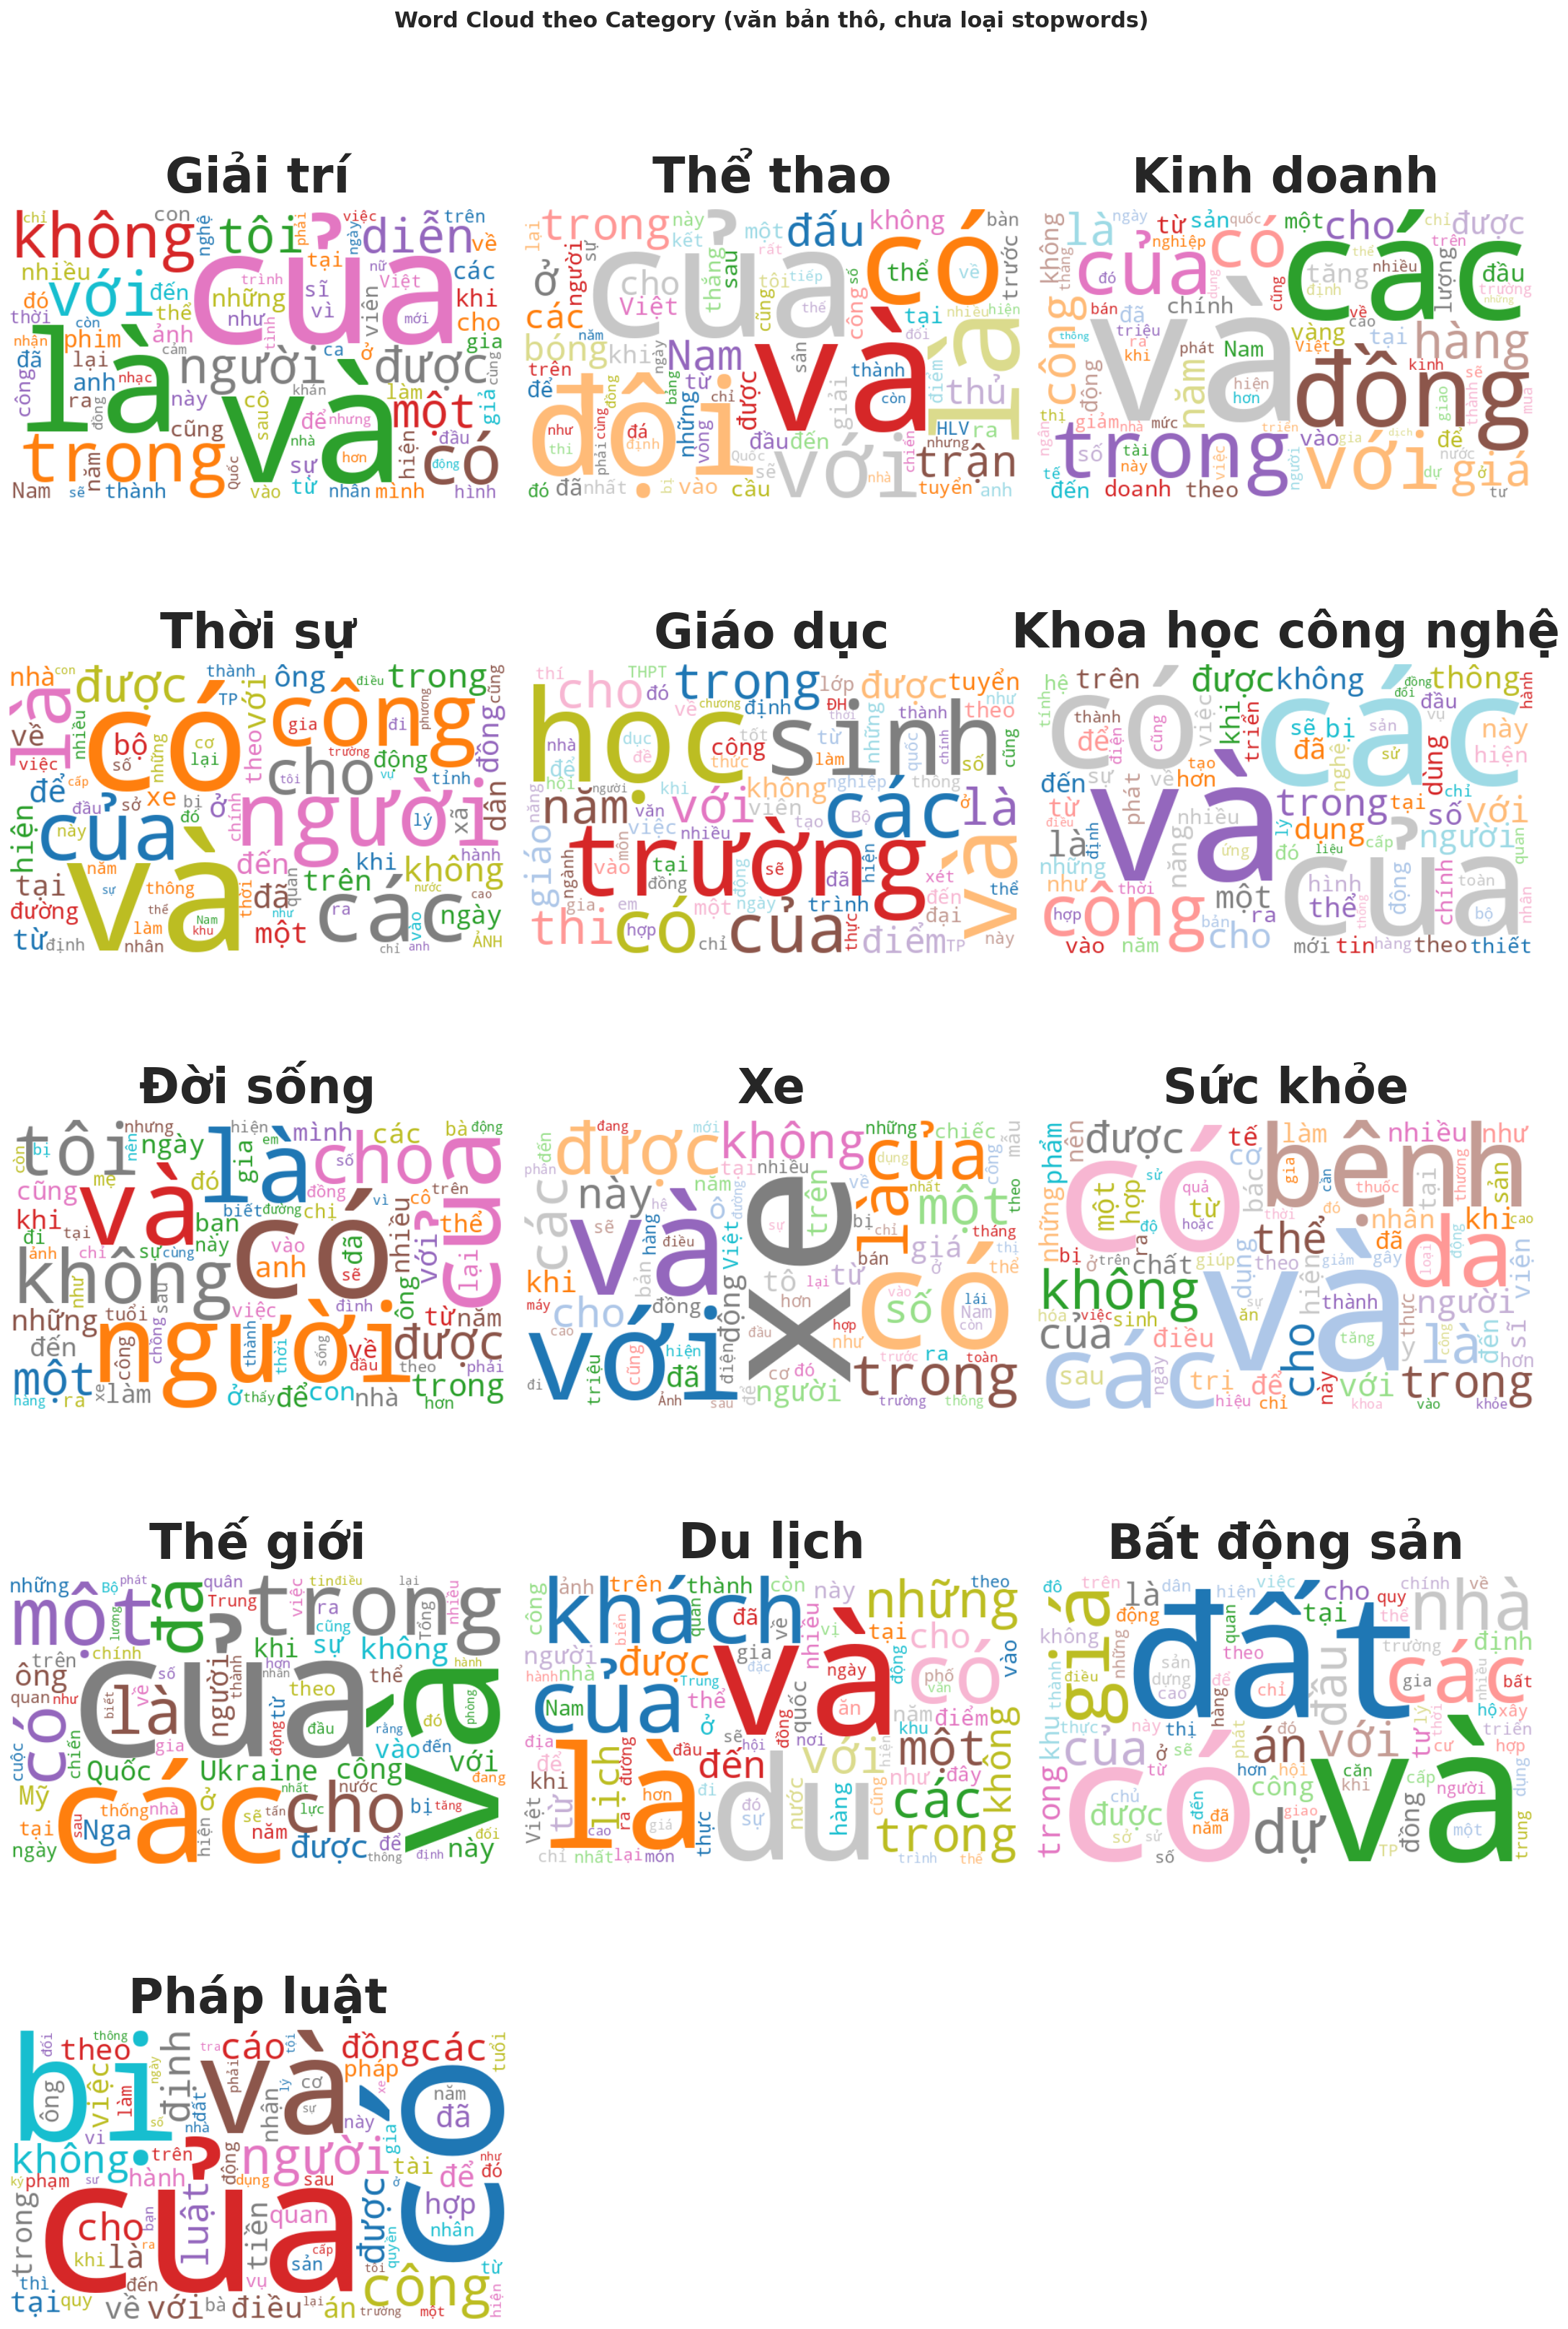

In [58]:
TEXT_COL = "content" 
TEXT_FOR_WC = TEXT_COL if TEXT_COL in df_eda.columns else 'title'

FONT_PATH = None  

categories = df_eda['category'].value_counts().index.tolist()
n_cats     = len(categories)
ncols      = 3
nrows      = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5.5))
axes      = axes.flatten()

for i, cat in enumerate(categories):
    texts = df_eda[df_eda['category'] == cat][TEXT_FOR_WC].dropna().astype(str)
    corpus = ' '.join(texts.sample(min(500, len(texts)), random_state=42))

    wc_kwargs = dict(
        width=600, height=350,
        background_color='white',
        max_words=80,
        collocations=False,
        colormap=f'tab{10 if i % 3 == 0 else 20}'
    )
    if FONT_PATH:
        wc_kwargs['font_path'] = FONT_PATH

    wc = WordCloud(**wc_kwargs).generate(corpus)
    axes[i].imshow(wc, interpolation='bilinear')

    # Tăng kích thước tiêu đề từng category
    axes[i].set_title(
        cat,
        fontweight='bold',
        fontsize=40,
        pad=14
    )

    axes[i].axis('off')

# Ẩn ô thừa
for j in range(n_cats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Word Cloud theo Category (văn bản thô, chưa loại stopwords)',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### 7.3. Nhận xét Word Cloud theo Category (văn bản thô)

**Nhận xét chung:**
Word Cloud trên cột `content` cho thấy các từ rất phổ biến trong tiếng Việt như **“và”, “của”, “là”, “trong”, “với”, “được”, “không”, “cho”, “đến”, “một”, “các”** xuất hiện dày đặc ở hầu hết các category. Đây là điều hoàn toàn hợp lý vì dữ liệu đang ở dạng **văn bản thô, chưa loại stopwords và chưa chuẩn hóa**. Ngoài ra, các thực thể rất hay gặp trong tin tức như **“ông”, “bà”, “người”, “Việt”, “Nam”, “nước”** cũng xuất hiện nổi bật, phản ánh phong cách diễn đạt đặc trưng của văn bản báo chí.
Tuy nhiên, bên dưới lớp từ phổ biến đó, nhiều category vẫn đã bộc lộ được **từ khóa đặc trưng riêng**, cho thấy dữ liệu có tín hiệu phân loại tương đối rõ ngay từ giai đoạn thô.

**Các category có tín hiệu đặc trưng tương đối rõ ngay cả khi chưa xử lý:**

* **Thể thao:** nổi bật với các từ như **“đội”, “trận”, “đấu”, “thủ”, “HLV”, “bóng”**, phản ánh rõ nội dung về thi đấu và các sự kiện thể thao.
* **Giáo dục:** các từ như **“học”, “sinh”, “trường”, “thi”, “điểm”, “tuyển”** xuất hiện khá rõ, cho thấy đây là một nhóm có từ vựng rất đặc thù.
* **Khoa học công nghệ:** xuất hiện các tín hiệu như **“AI”, “công”, “ứng”, “dụng”, “thông”**, cho thấy dù còn bị lẫn nhiều từ phổ biến nhưng vẫn có dấu hiệu của nhóm công nghệ.
* **Xe:** các từ như **“xe”, “tô”, “giá”, “đồng”, “chiếc”** khá nổi bật, phản ánh nội dung liên quan đến ô tô, xe cộ và giá bán.
* **Sức khỏe:** có thể thấy các từ như **“bệnh”, “bác”, “sĩ”, “cơ”, “thể”**, cho thấy nội dung nghiêng rõ về y tế và sức khỏe con người.
* **Thế giới:** nổi bật các từ như **“Ukraine”, “Nga”, “Mỹ”, “ông”**, phản ánh rõ bối cảnh quốc tế và các vấn đề địa chính trị.
* **Bất động sản:** các từ **“dự”, “án”, “đất”, “nhà”, “khu”, “giá”** xuất hiện nổi bật, rất đúng với đặc trưng của nhóm nhà đất.
* **Pháp luật:** xuất hiện các từ như **“án”, “bị”, “công”, “định”, “vụ”**, thể hiện khá rõ đặc trưng của nhóm pháp lý, tố tụng, xử lý vụ việc.
* **Du lịch:** có các tín hiệu như **“khách”, “đi”, “đến”, “tour”**, cho thấy nhóm này cũng có ngôn ngữ tương đối riêng.

**Các category có tín hiệu nhưng còn bị nhiễu mạnh bởi từ phổ biến:**

* **Kinh doanh:** có xuất hiện các từ như **“đồng”, “giá”, “tăng”, “hàng”, “công”**, nhưng vẫn bị lẫn khá nhiều từ chung nên mức độ phân biệt trực quan chưa thật sự sắc nét.
* **Giải trí:** có một số từ như **“phim”, “ca”, “anh”, “nghệ”**, nhưng nhìn chung vẫn bị chi phối nhiều bởi các từ phổ biến như “ông”, “bà”, “người”.
* **Thời sự:** phần lớn vẫn nổi bật các từ rất chung như **“ông”, “bà”, “của”, “đã”, “cho”**, nên khó tách biệt trực quan với các nhóm tin tức tổng hợp khác.
* **Đời sống:** cũng mang tính tổng hợp, dùng nhiều từ đời thường như **“con”, “người”, “nhà”, “ăn”**, nhưng chưa có cụm từ khóa đủ mạnh để phân biệt rõ bằng quan sát trực tiếp.

**Nhận xét riêng về mức độ phân biệt giữa các nhóm:**
Các nhóm như **Giáo dục, Thể thao, Xe, Bất động sản, Sức khỏe, Pháp luật, Thế giới** là những category cho thấy **tín hiệu phân loại rõ nhất** ngay cả khi văn bản chưa qua tiền xử lý. Ngược lại, các nhóm như **Thời sự, Đời sống, Giải trí, Kinh doanh** có xu hướng dùng nhiều từ mang tính tổng quát của báo chí, vì vậy ranh giới trực quan còn mờ hơn.

**Kết luận:**
Word Cloud từ dữ liệu thô cho thấy việc **loại bỏ stopwords, chuẩn hóa văn bản và có thể tách từ tốt hơn** là bước rất cần thiết nếu muốn phân tích nội dung sâu hơn hoặc xây dựng mô hình phân loại hiệu quả. Tuy nhiên, kết quả cũng khá tích cực vì ngay cả trong trạng thái chưa xử lý, nhiều category vẫn đã xuất hiện những từ khóa đặc trưng rõ ràng. Điều này cho thấy bộ dữ liệu có **tín hiệu ngôn ngữ phù hợp cho bài toán phân loại chủ đề**.


## 8. Phân tích trường `tag` và rủi ro shortcut

Trường `tag` là một trường văn bản ngắn, thường chứa các từ khóa cô đọng do nguồn báo cung cấp để mô tả nội dung bài viết. Về mặt thông tin, `tag` có thể rất hữu ích vì giúp người đọc nắm nhanh chủ đề chính của bài báo.

Tuy nhiên, chính vì `tag` được biên tập dưới dạng từ khóa ngắn gọn, trường này có thể chứa tín hiệu rất gần với nhãn `category`. Nếu đưa `tag` vào baseline phân loại category, mô hình có thể học shortcut từ các từ khóa biên tập thay vì học đầy đủ tín hiệu từ `title`, `description` và `content`.

Vì vậy, phần này phân tích riêng trường `tag` để trả lời hai câu hỏi:

1. `tag` có phải là trường ngữ nghĩa mạnh hay không?
2. Có nên đưa `tag` vào input mặc định của baseline phân loại `category` hay không?

=== THỐNG KÊ TRƯỜNG TAG ===


,metric,value
0,Số bài có tag,272973.00
1,Số bài thiếu tag,85.00
2,Tỷ lệ thiếu tag (%),0.03
3,Số tag trung bình mỗi bài,4.81
4,Trung vị số tag mỗi bài,4.00
5,Số từ trung bình trong trường tag,15.18



=== MẪU TAG THEO BÀI VIẾT ===


,category,title,tag
0,Kinh doanh,"Đề nghị ngân hàng nộp thuế thay cho Agoda, AirBnB, Booking và Paypal","nhà cung cấp nước ngoài,nộp thuế,cơ quan thuế,agoda"
1,Khoa học công nghệ,"Quản lý tiền không cần ngân hàng, DeFi đang thay đổi trật tự tài chính ra sao?","usdt,staking,defi,blockchain,smart"
2,Sức khỏe,Mổ mắt miễn phí - Nỗ lực chung tay vì cộng đồng,"bệnh nhân nghèo,đục thủy tinh thể,hồng sơn"
3,Xe,Phụ nữ bán ô tô làm gì khi có đề nghị khiếm nhã?,"sales ô tô,nữ tư vấn bán hàng,góc nhìn chuyên gia,chuyện hậu trường,bán ô tô"
4,Xe,Tài xế say rượu phi xe vào cửa hàng tông trúng bé trai và thai phụ,"tài xế, tài xế say rượu, Mitsubishi Mirage"
5,Thể thao,Hoàng Anh Gia Lai gây chấn động tại Pleiku,"clb hoàng anh gia lai,sân pleiku,thể công - viettel,hlv velizar popov"
6,Giáo dục,"Hôm nay thí sinh thi đánh giá năng lực xét tuyển vào hơn 100 trường ĐH, CĐ","thi đánh giá năng lực, ĐH Quốc Gia Tp.HCM, Xét tuyển, tuyển sinh 2024"
7,Kinh doanh,Sabeco - 8 năm liên tiếp vào top 10 công ty đồ uống uy tín năm 2024,"Sabeco, thực phẩm - đồ uống, Vietnam Report"
8,Xe,Hyundai Tucson thêm chế độ lái ru ngủ trẻ em ngồi sau,"hyundai tucson,hyundai,hyundai tucson baby mode,chế độ lái ru ngủ trẻ em"
9,Thể thao,Đưa đội U21 tham dự Asiad 2026: Chiến lược đúng của VFF,"asiad 2026,u21 vn,liên đoàn bóng đá việt nam,vff,bóng đá việt nam"


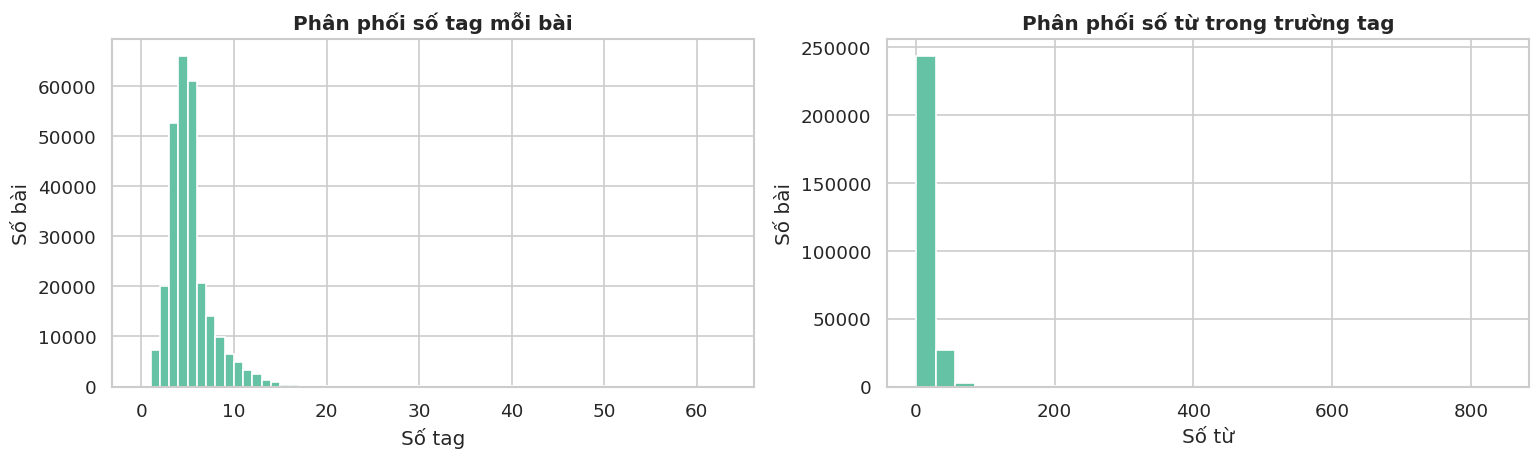

In [59]:
# =========================
# 8.1. Chuẩn bị dữ liệu tag
# =========================
import re
import unicodedata


def normalize_text_for_tag(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"\s+", " ", s)
    return s


def split_tags(tag):
    if pd.isna(tag):
        return []
    tag = str(tag).strip()
    # Các nguồn báo thường phân tách tag bằng dấu phẩy; bổ sung một số delimiter phổ biến khác.
    parts = re.split(r"[,;|]+", tag)
    return [p.strip() for p in parts if p.strip()]


df_tag = df_eda.copy()
df_tag["tag_clean"] = df_tag["tag"].map(lambda x: str(x).strip() if pd.notna(x) else pd.NA)
df_tag["tag_list"] = df_tag["tag_clean"].map(split_tags)
df_tag["n_tags"] = df_tag["tag_list"].map(len)
df_tag["tag_word_count"] = df_tag["tag_clean"].fillna("").str.split().str.len()

tag_stats = pd.DataFrame({
    "metric": [
        "Số bài có tag",
        "Số bài thiếu tag",
        "Tỷ lệ thiếu tag (%)",
        "Số tag trung bình mỗi bài",
        "Trung vị số tag mỗi bài",
        "Số từ trung bình trong trường tag"
    ],
    "value": [
        df_tag["tag_clean"].notna().sum(),
        df_tag["tag_clean"].isna().sum(),
        round(df_tag["tag_clean"].isna().mean() * 100, 4),
        round(df_tag.loc[df_tag["tag_clean"].notna(), "n_tags"].mean(), 2),
        df_tag.loc[df_tag["tag_clean"].notna(), "n_tags"].median(),
        round(df_tag.loc[df_tag["tag_clean"].notna(), "tag_word_count"].mean(), 2)
    ]
})

print("=== THỐNG KÊ TRƯỜNG TAG ===")
display(tag_stats)

print("\n=== MẪU TAG THEO BÀI VIẾT ===")
display(df_tag[["category", "title", "tag"]].sample(10, random_state=42).reset_index(drop=True))

# Phân phối số tag mỗi bài
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_n_tags = df_tag.loc[df_tag["tag_clean"].notna(), "n_tags"]
axes[0].hist(plot_n_tags, bins=range(0, int(plot_n_tags.max()) + 2), edgecolor="white")
axes[0].set_title("Phân phối số tag mỗi bài", fontweight="bold")
axes[0].set_xlabel("Số tag")
axes[0].set_ylabel("Số bài")

plot_tag_wc = df_tag.loc[df_tag["tag_clean"].notna(), "tag_word_count"]
axes[1].hist(plot_tag_wc, bins=30, edgecolor="white")
axes[1].set_title("Phân phối số từ trong trường tag", fontweight="bold")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số bài")

plt.tight_layout()
plt.show()

### 8.1. Nhận xét thống kê tag

`tag` là trường ngắn hơn rất nhiều so với `content`, nhưng lại chứa các cụm từ khóa cô đọng mô tả nội dung bài viết. Điều này cho thấy `tag` có giá trị ngữ nghĩa cao và có thể hữu ích cho các bài toán mở rộng như gợi ý tag tự động.

Tuy nhiên, vì `tag` được thiết kế để tóm tắt chủ đề, trường này có khả năng mang tín hiệu rất gần với `category`. Do đó, cần kiểm tra kỹ hơn trước khi quyết định có sử dụng `tag` làm đầu vào cho bài toán phân loại category hay không.

In [60]:
# =========================
# 8.2. Kiểm tra tag có chứa trực tiếp tên category không
# =========================
df_tag["category_norm"] = df_tag["category"].map(normalize_text_for_tag)
df_tag["tag_norm"] = df_tag["tag"].map(normalize_text_for_tag)


def contains_category_phrase(row):
    category = row["category_norm"]
    tag = row["tag_norm"]
    if not category or not tag:
        return False
    # Dùng boundary để hạn chế match sai, ví dụ category "Xe" không bị match vào "xem".
    pattern = r"(?<!\w)" + re.escape(category) + r"(?!\w)"
    return bool(re.search(pattern, tag))


df_tag["tag_contains_category"] = df_tag.apply(contains_category_phrase, axis=1)

tag_category_overlap = pd.DataFrame({
    "metric": [
        "Số bài có tag chứa trực tiếp tên category",
        "Tỷ lệ trên toàn bộ dữ liệu (%)"
    ],
    "value": [
        int(df_tag["tag_contains_category"].sum()),
        round(df_tag["tag_contains_category"].mean() * 100, 4)
    ]
})

print("=== TAG CHỨA TRỰC TIẾP TÊN CATEGORY ===")
display(tag_category_overlap)

print("\n=== MẪU BÀI CÓ TAG CHỨA TÊN CATEGORY ===")
display(
    df_tag[df_tag["tag_contains_category"]][["category", "tag", "title"]]
    .head(20)
    .reset_index(drop=True)
)

=== TAG CHỨA TRỰC TIẾP TÊN CATEGORY ===


,metric,value
0,Số bài có tag chứa trực tiếp tên category,25418.00
1,Tỷ lệ trên toàn bộ dữ liệu (%),9.31



=== MẪU BÀI CÓ TAG CHỨA TÊN CATEGORY ===


,category,tag,title
0,Bất động sản,"bàn giao căn hộ,the western capital,chủ đầu tư,chung cư,công ty tnhh quản lý bất động sản hoàng phúc",Chủ đầu tư chung cư The Western Capital bị kiện do giao nhà chậm
1,Bất động sản,"kiều bào việt nam,an cư,bất động sản,waterpoint",Cơ hội mới cho kiều bào an cư và đầu tư tại Việt Nam
2,Bất động sản,"hiệp hội bất động sản tp.hcm,nghị quyết 98,luật đầu tư,ppp,hình thức bt",Đề xuất gỡ vướng thời điểm định giá đất cho các dự án BT
3,Bất động sản,"aqua city,tập đoàn novaland,bất động sản,đồng nai,pháp lý",Novaland cam kết tháo gỡ toàn bộ vướng mắc pháp lý ở dự án Aqua City
4,Bất động sản,"nhà ở xã hội,nhà ở,thị trường bất động sản,bộ xây dựng,dự án nhà ở xã hội","Thủ tướng: Đưa dự án nhà ở xã hội vào luồng xanh, thực hiện dự án chỉ trong 2-3 năm"
5,Bất động sản,"nhà ở,bất động sản,giao dịch bất động sản,bộ xây dựng,mua nhà ở xã hội","Chính thức nâng trần thu nhập mua nhà ở xã hội, Thủ tướng yêu cầu hướng dẫn cụ thể"
6,Bất động sản,"tp.hcm,sở xây dựng tp.hcm,kinh doanh bất động sản,huy động vốn,ủy quyền","Sở Xây dựng TP.HCM: Doanh nghiệp bất động sản không được ủy quyền đặt cọc, mua bán"
7,Bất động sản,"bất động sản,tập đoàn lotte,keppel,thủ thiêm",Chủ đầu tư Empire City gửi kiến nghị về khoản tiền đất bổ sung 8.800 tỉ đồng
8,Bất động sản,"bất động sản,ủy ban chứng khoán nhà nước,báo cáo tài chính,hợp đồng,trái phiếu",Nhiều doanh nghiệp bất động sản bị phạt vì loạt vi phạm
9,Bất động sản,"công ty ô tô,haxaco,đấu giá,hội đồng quản trị,bất động sản","'Trùm' buôn xe Mercedes rao bán lô đất nghìn tỉ ở TP.HCM, không ai hỏi mua"


### 8.2. Nhận xét về khả năng chứa nhãn trực tiếp

Kết quả kiểm tra cho thấy một phần dữ liệu có `tag` chứa trực tiếp tên `category`. Đây là dấu hiệu cần chú ý vì trong những trường hợp này, `tag` có thể hoạt động gần như một gợi ý nhãn.

In [61]:
# =========================
# 8.3. Top tag theo category và dominance của tag
# =========================
tag_exploded = df_tag[["category", "source", "tag_list"]].explode("tag_list").dropna(subset=["tag_list"]).copy()
tag_exploded["tag_item"] = tag_exploded["tag_list"].map(normalize_text_for_tag)
tag_exploded = tag_exploded[tag_exploded["tag_item"] != ""]

# Top tag theo từng category
top_tags_by_category = (
    tag_exploded
    .groupby(["category", "tag_item"])
    .size()
    .reset_index(name="count")
    .sort_values(["category", "count"], ascending=[True, False])
)

print("=== TOP 10 TAG THEO MỖI CATEGORY ===")
display(
    top_tags_by_category
    .groupby("category")
    .head(10)
    .reset_index(drop=True)
)

# Dominance: một tag xuất hiện chủ yếu trong category nào?
tag_category_dist = (
    tag_exploded
    .groupby(["tag_item", "category"])
    .size()
    .reset_index(name="count")
)

tag_total = (
    tag_category_dist
    .groupby("tag_item")["count"]
    .sum()
    .reset_index(name="total_count")
)

tag_max_category = (
    tag_category_dist
    .sort_values(["tag_item", "count"], ascending=[True, False])
    .groupby("tag_item")
    .head(1)
    .rename(columns={"category": "dominant_category", "count": "dominant_count"})
)

tag_dominance = tag_max_category.merge(tag_total, on="tag_item")
tag_dominance["dominance_rate"] = tag_dominance["dominant_count"] / tag_dominance["total_count"]

# Chỉ xét các tag xuất hiện đủ nhiều để tránh các tag hiếm gây nhiễu kết luận.
tag_dominance_filtered = tag_dominance[tag_dominance["total_count"] >= 20].copy()

print("\n=== CÁC TAG CÓ DOMINANCE CAO THEO CATEGORY (total_count >= 20) ===")
display(
    tag_dominance_filtered
    .sort_values(["dominance_rate", "total_count"], ascending=[False, False])
    .head(30)
    .reset_index(drop=True)
)

# Tóm tắt tỷ lệ tag có dominance rất cao
summary_dominance = pd.DataFrame({
    "metric": [
        "Số tag có total_count >= 20",
        "Số tag có dominance_rate = 1.00",
        "Tỷ lệ tag dominance_rate = 1.00 (%)",
        "Số tag có dominance_rate >= 0.90",
        "Tỷ lệ tag dominance_rate >= 0.90 (%)"
    ],
    "value": [
        len(tag_dominance_filtered),
        int((tag_dominance_filtered["dominance_rate"] == 1.0).sum()),
        round((tag_dominance_filtered["dominance_rate"] == 1.0).mean() * 100, 2),
        int((tag_dominance_filtered["dominance_rate"] >= 0.90).sum()),
        round((tag_dominance_filtered["dominance_rate"] >= 0.90).mean() * 100, 2)
    ]
})

print("\n=== TÓM TẮT DOMINANCE CỦA TAG ===")
display(summary_dominance)

=== TOP 10 TAG THEO MỖI CATEGORY ===


,category,tag_item,count
0,Bất động sản,nhà ở xã hội,578
1,Bất động sản,bất động sản,461
2,Bất động sản,hà nội,429
3,Bất động sản,đấu giá đất,394
4,Bất động sản,đấu giá,374
...,...,...,...
125,Đời sống,đám cưới,692
126,Đời sống,mạng xã hội,607
127,Đời sống,hôn nhân,478
128,Đời sống,tâm sự,476



=== CÁC TAG CÓ DOMINANCE CAO THEO CATEGORY (total_count >= 20) ===


,tag_item,dominant_category,dominant_count,total_count,dominance_rate
0,kết quả bóng đá,Thể thao,5352,5352,1.00
1,tin bóng đá,Thể thao,1791,1791,1.00
2,vàng nhẫn,Kinh doanh,1558,1558,1.00
3,tin tức sao việt,Giải trí,1396,1396,1.00
4,lịch thi đấu bóng đá,Thể thao,1378,1378,1.00
5,phim truyền hình việt nam,Giải trí,1318,1318,1.00
6,tin mu,Thể thao,1233,1233,1.00
7,giá vàng 9999,Kinh doanh,1181,1181,1.00
8,man city,Thể thao,1168,1168,1.00
9,giá vàng trong nước,Kinh doanh,1087,1087,1.00



=== TÓM TẮT DOMINANCE CỦA TAG ===


,metric,value
0,Số tag có total_count >= 20,8646.00
1,Số tag có dominance_rate = 1.00,3055.00
2,Tỷ lệ tag dominance_rate = 1.00 (%),35.33
3,Số tag có dominance_rate >= 0.90,4819.00
4,Tỷ lệ tag dominance_rate >= 0.90 (%),55.74


### 8.3. Nhận xét top tag và dominance

Top tag theo từng category cho thấy nhiều tag phản ánh rất rõ đặc trưng chủ đề. Ví dụ, các tag liên quan đến bóng đá thường thuộc `Thể thao`, tag liên quan đến giá vàng thường thuộc `Kinh doanh`, tag liên quan đến sao Việt/phim ảnh thường thuộc `Giải trí`, và tag liên quan đến tử vi thường thuộc `Đời sống`.

Bảng dominance cho thấy nhiều tag phổ biến gần như chỉ xuất hiện trong một category duy nhất. Điều này không làm `tag` trở thành dữ liệu sai, nhưng chứng minh `tag` là một trường có tín hiệu phân loại rất mạnh. Nếu dùng trường này trong baseline, mô hình có thể học quy tắc ngắn kiểu “tag A → category B” thay vì học từ toàn bộ nội dung bài báo.

In [62]:
# =========================
# 8.4. Tag-only diagnostic
# =========================
# Lưu ý: đây chỉ là thí nghiệm chẩn đoán để đo độ mạnh của tag,
# không phải baseline chính của bài toán phân loại category.

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report


df_tag_model = df_tag.dropna(subset=["tag", "category"]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_tag_model["tag"].astype(str),
    df_tag_model["category"],
    test_size=0.2,
    random_state=42,
    stratify=df_tag_model["category"]
)

tag_only_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

tag_only_model.fit(X_train, y_train)
y_pred = tag_only_model.predict(X_test)

tag_only_result = pd.DataFrame({
    "metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "value": [
        round(accuracy_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred, average="macro"), 4),
        round(f1_score(y_test, y_pred, average="weighted"), 4)
    ]
})

print("=== TAG-ONLY DIAGNOSTIC: TF-IDF + LOGISTIC REGRESSION ===")
display(tag_only_result)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

=== TAG-ONLY DIAGNOSTIC: TF-IDF + LOGISTIC REGRESSION ===


,metric,value
0,Accuracy,0.86
1,Macro F1,0.83
2,Weighted F1,0.86



=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

      Bất động sản       0.65      0.86      0.74      1334
           Du lịch       0.65      0.82      0.73      1845
          Giáo dục       0.93      0.91      0.92      4499
          Giải trí       0.95      0.94      0.94      8694
Khoa học công nghệ       0.86      0.87      0.86      4207
        Kinh doanh       0.88      0.75      0.81      6668
         Pháp luật       0.56      0.83      0.67       651
          Sức khỏe       0.85      0.92      0.89      3338
          Thế giới       0.78      0.82      0.80      2990
          Thể thao       0.98      0.96      0.97      7253
           Thời sự       0.76      0.71      0.73      5504
                Xe       0.92      0.94      0.93      3781
          Đời sống       0.75      0.74      0.75      3831

          accuracy                           0.86     54595
         macro avg       0.81      0.85      0.83     54595
      w

### 8.4. Kết luận về việc sử dụng `tag`

Thí nghiệm `tag-only` chỉ được dùng như một kiểm tra chẩn đoán. Ở lần chạy trên dữ liệu hiện tại, chỉ sử dụng riêng trường `tag`, mô hình TF-IDF kết hợp Logistic Regression đã đạt **Accuracy = 0.86**, **Macro F1 = 0.83** và **Weighted F1 = 0.86**. Đây là kết quả cao đối với một trường văn bản rất ngắn.

Kết quả này cho thấy `tag` chứa tín hiệu phân loại rất mạnh. Ngoài ra, phân tích trực tiếp cho thấy có **25,426 bản ghi**, tương đương khoảng **9.31% dữ liệu**, có `tag` chứa trực tiếp tên `category`; nhiều tag phổ biến cũng có dominance rate bằng **1.00**, nghĩa là gần như chỉ xuất hiện trong một category duy nhất.

Vì vậy, `tag` không được đưa vào input mặc định của baseline phân loại `category`. Baseline chính nên sử dụng `title + description + content` để đánh giá khả năng phân loại dựa trên nội dung bài báo. Trường `tag` vẫn nên được giữ lại trong metadata để bảo toàn thông tin gốc và hỗ trợ các bài toán mở rộng, chẳng hạn:

- gợi ý tag tự động từ `title + description + content`;
- phân tích từ khóa theo category/source/thời gian;
- so sánh thí nghiệm mở rộng giữa baseline không dùng tag và setting có dùng tag.

## 9. Tóm tắt kết quả EDA

| STT | Nhóm EDA | Phát hiện chính | Ý nghĩa ghi nhận cho bước cleaning/modeling |
| --: | --- | --- | --- |
| 1 | Tổng quan dữ liệu | Dataset thô có quy mô lớn, gồm khoảng **273,058 bài báo**, **3 nguồn báo**, **13 category** và giai đoạn **2023–2025**. | Dữ liệu đủ lớn để xây dựng bài toán phân loại chủ đề tin tức tiếng Việt, đồng thời có metadata hỗ trợ truy vết và phân tích mở rộng. |
| 2 | Phân phối category | Phân phối nhãn mất cân bằng, category lớn nhất là `Giải trí`, category nhỏ nhất là `Pháp luật`, imbalance ratio khoảng **13.3 lần**. | Khi đánh giá mô hình cần chú ý Macro F1/Weighted F1, không nên chỉ dựa vào Accuracy. Các lớp nhỏ cần được theo dõi kỹ. |
| 3 | Phân phối source | VietnamNet chiếm tỷ lệ lớn nhất, tiếp theo là Thanh Niên và Tuổi Trẻ; nguồn lớn nhất gấp khoảng **2.34 lần** nguồn nhỏ nhất. | `source` không nên là input mặc định cho mô hình phân loại, nhưng cần giữ trong metadata để phân tích thiên lệch nguồn báo. |
| 4 | Category × Source | Một số category thiếu hẳn một source hoặc bị chi phối bởi một source cụ thể. | Có nguy cơ source bias: mô hình có thể học một phần phong cách/nguồn báo nếu dữ liệu theo category không cân bằng giữa các source. |
| 5 | Phân phối thời gian | Dữ liệu bao phủ liên tục các tháng trong giai đoạn 2023–2025 và có xu hướng tăng số lượng bài theo thời gian. | Có thể dùng cho phân tích xu hướng thời gian, nhưng cần lưu ý khác biệt phân phối giữa các giai đoạn khi chia/evaluate dữ liệu. |
| 6 | Missing Values | Missing tập trung nhiều nhất ở `author`; các trường văn bản chính như `title`, `description`, `content` thiếu ít hơn nhưng ảnh hưởng trực tiếp đến input. | Drop các dòng thiếu trường văn bản cốt lõi; không drop chỉ vì thiếu `author`; parse `public_date` cẩn thận do khác format giữa nguồn báo. |
| 7 | Duplicate | Không có bản ghi trùng toàn bộ dòng, nhưng có trùng URL sau chuẩn hóa và trùng theo nội dung văn bản. | Cần chuẩn hóa URL trước khi kiểm tra duplicate; duplicate theo `content` hoặc `title + description + content` cần được xử lý để tránh bias/leakage giữa train-test. |
| 8 | Label conflict | Có một số nhóm cùng `title + description + content` nhưng khác `category`. | Đây là nhiễu nhãn trực tiếp; không nên giữ nguyên trong tập huấn luyện vì cùng input nhưng nhiều output khác nhau. |
| 9 | Độ dài văn bản | Phần lớn bài có độ dài hợp lý; bài quá ngắn có rủi ro thiếu nội dung, bài quá dài thường vẫn hợp lệ nhưng có thể chứa nhiễu crawl. | Có thể lọc bài quá ngắn theo ngưỡng phân vị thấp; không nên drop tự động toàn bộ bài dài, thay vào đó làm sạch regex để giảm nhiễu. |
| 10 | Đặc trưng ngôn ngữ thô | Word Cloud cho thấy dữ liệu còn nhiều stopwords và từ phổ biến, nhưng vẫn có tín hiệu chủ đề ở từng category. | Word Cloud chỉ là phân tích trực quan ban đầu; không nên xem là bằng chứng định lượng mạnh. |
| 11 | Trường `tag` | `tag` là trường ngữ nghĩa rất mạnh: tag-only diagnostic đạt **Accuracy 0.86**, **Macro F1 0.83**; khoảng **9.31%** bản ghi có tag chứa trực tiếp tên category; nhiều tag có dominance rate **1.00**. | Không đưa `tag` vào baseline chính để tránh shortcut. Giữ `tag` trong metadata để bảo toàn thông tin gốc và hỗ trợ bài toán mở rộng như gợi ý tag tự động từ `title + description + content`. |

**Kết luận chung:** Baseline chính của bài toán phân loại category nên sử dụng `title + description + content`. Các trường metadata như `source`, `url`, `author`, `sub_topic`, `public_date` và `tag` nên được giữ để truy vết, phân tích và mở rộng bài toán, nhưng không nên được hiểu là input mặc định của baseline phân loại chủ đề.